In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, r2_score, f1_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\mehdi\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Veri seti

In [2]:
df = pd.read_csv(r'C:\data_set\bank_data.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


# Exploratory Data Analysis - EDA

## Veri setine genel bakış

In [3]:
# değişken isimleri kontrol ediliyor
print(df.columns)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [5]:
df.columns = df.columns.str.replace(' ', '_')


In [6]:
# 'CustomerId' sütununu kalıcı olarak silindi
df.drop('CustomerId', axis=1, inplace=True)
# 'RowNumber' sütununu kalıcı olarak silindi
df.drop('RowNumber', axis=1, inplace=True)
# 'Surname' sütununu kalıcı olarak silindi
df.drop('Surname', axis=1, inplace=True)

In [7]:
# değişken isimleri kontrol ediliyor
print(df.columns)

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction_Score', 'Card_Type',
       'Point_Earned'],
      dtype='object')


#### istatistiksel özetler

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203800,0.402842,0.00,0.00,0.000,0.0000,1.00
Complain,10000.0,0.204400,0.403283,0.00,0.00,0.000,0.0000,1.00


## Eksik gözlem inceleme

In [9]:
df.isnull().sum()

CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction_Score    0
Card_Type             0
Point_Earned          0
dtype: int64

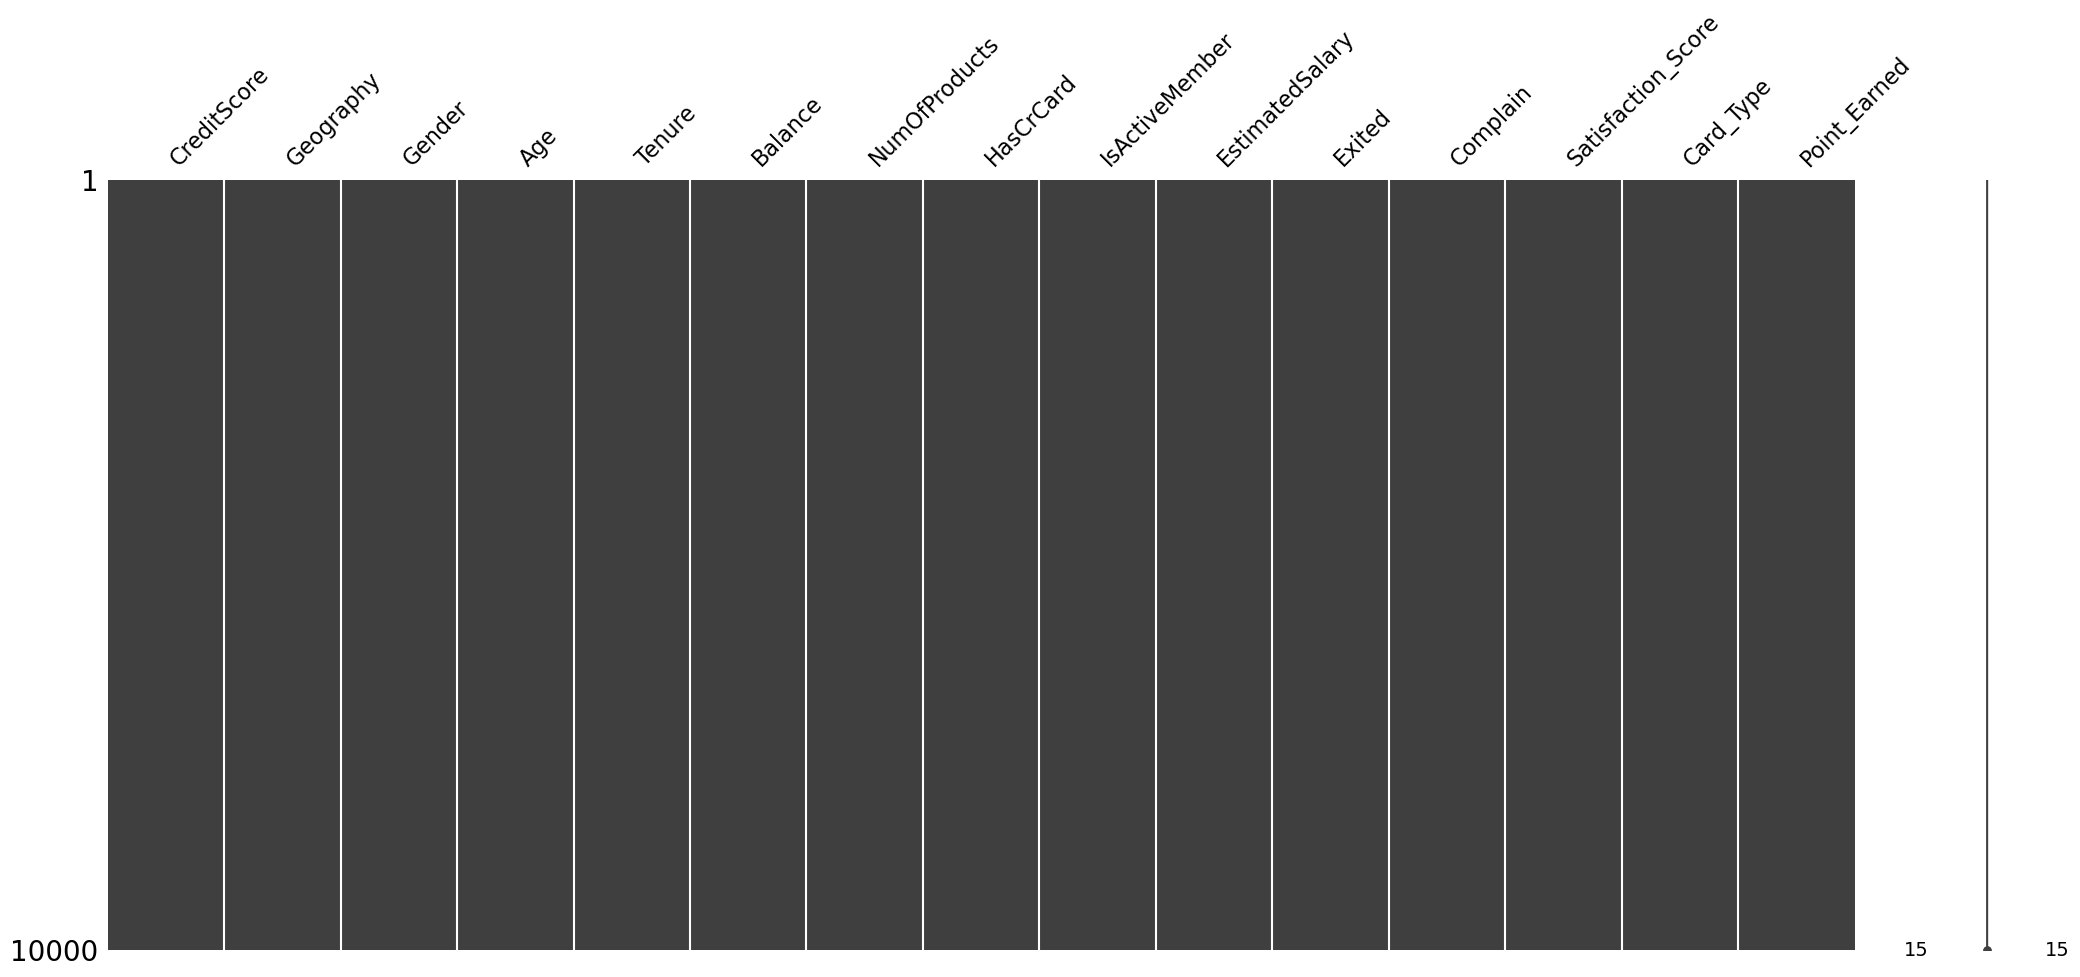

In [10]:
import missingno as msno
# Eksik verilerin görselleştirilmesi
msno.matrix(df)
plt.show()

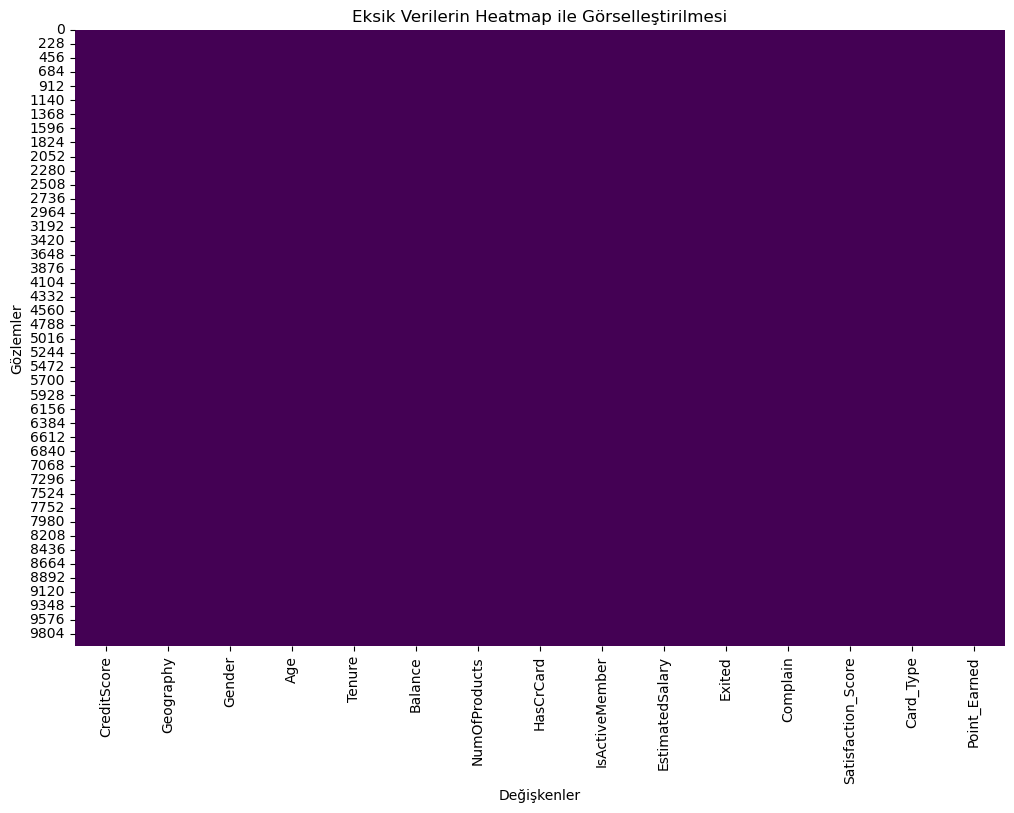

In [11]:
# Eksik verilerin heatmap ile görselleştirilmesi
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Eksik Verilerin Heatmap ile Görselleştirilmesi")
plt.xlabel("Değişkenler")
plt.ylabel("Gözlemler")
plt.show()

## Veri Keşfi

In [12]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


### Sayısal değişkenler

#### Kredi Skoru Dağılımı

C:\Users\mehdi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


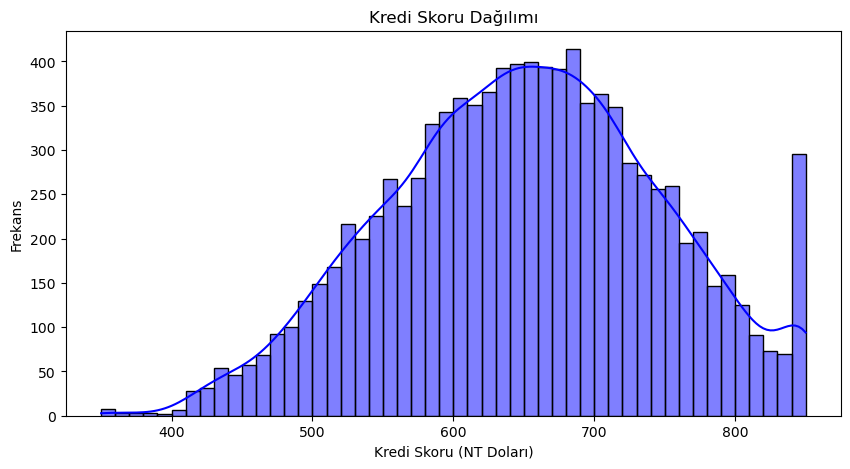

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df["CreditScore"], bins=50, kde=True, color="blue")
plt.title("Kredi Skoru Dağılımı")
plt.xlabel("Kredi Skoru (NT Doları)")
plt.ylabel("Frekans")
plt.show()

#### Yaş (Age) Dağılımı (Histogram)

C:\Users\mehdi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


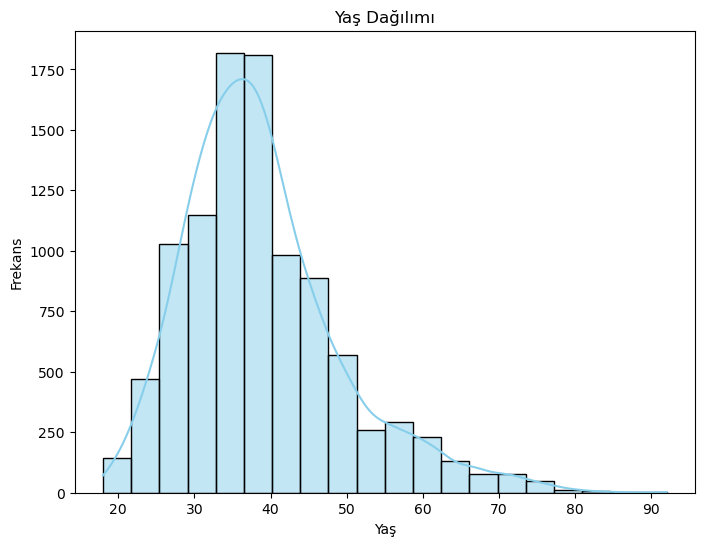

In [14]:
plt.figure(figsize=(8, 6))
sns.histplot(df["Age"], kde=True, color="skyblue", bins=20)
plt.title("Yaş Dağılımı")
plt.xlabel("Yaş")
plt.ylabel("Frekans")
plt.show()


##### Bakiye (Balance) Dağılımı (Histogram)

C:\Users\mehdi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


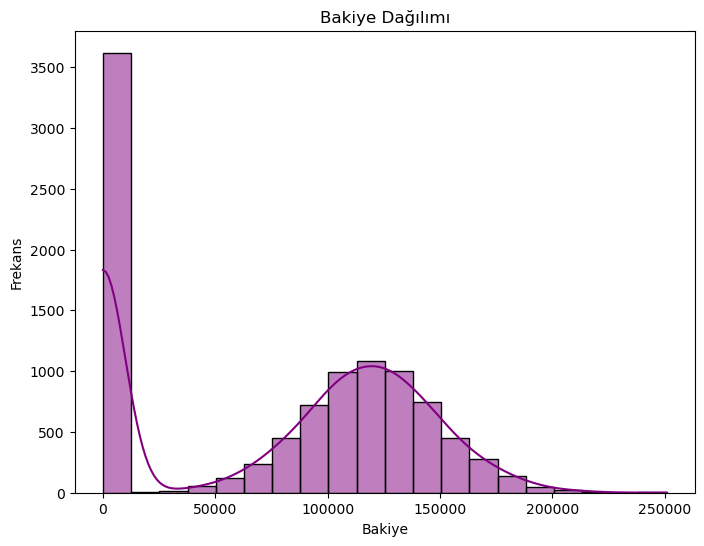

In [15]:
plt.figure(figsize=(8, 6))
sns.histplot(df["Balance"], kde=True, color="purple", bins=20)
plt.title("Bakiye Dağılımı")
plt.xlabel("Bakiye")
plt.ylabel("Frekans")
plt.show()


### Point_Earned (Kazanılan Puan) Dağılımı (Histogram)

C:\Users\mehdi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


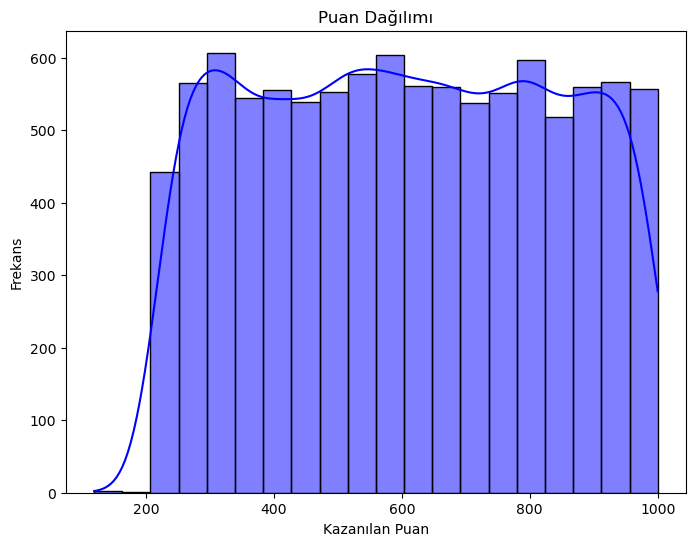

In [16]:
plt.figure(figsize=(8, 6))
sns.histplot(df["Point_Earned"], kde=True, color="Blue", bins=20)
plt.title("Puan Dağılımı")
plt.xlabel("Kazanılan Puan")
plt.ylabel("Frekans")
plt.show()


### Kategorik Değişkenler

#### Ürün Sayısı (NumOfProducts) Dağılımı (Bar Plot)

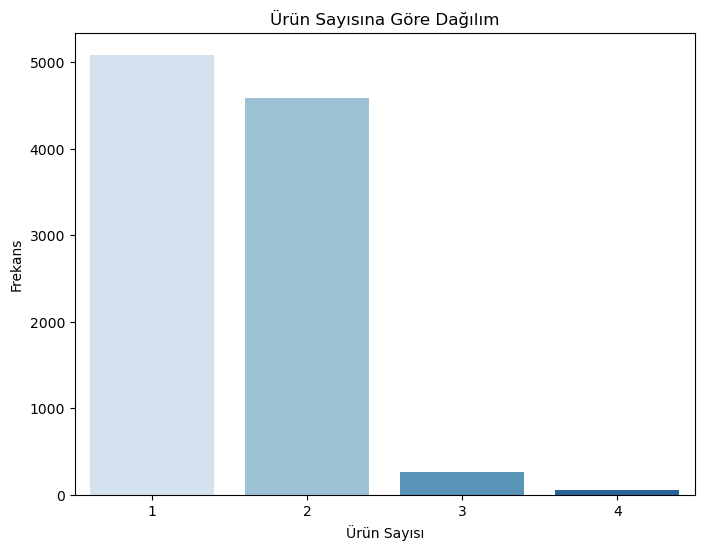

In [17]:
plt.figure(figsize=(8, 6))
sns.countplot(x="NumOfProducts", data=df, palette="Blues")
plt.title("Ürün Sayısına Göre Dağılım")
plt.xlabel("Ürün Sayısı")
plt.ylabel("Frekans")
plt.show()


#### Cinsiyet (Gender) Pasta grafiği

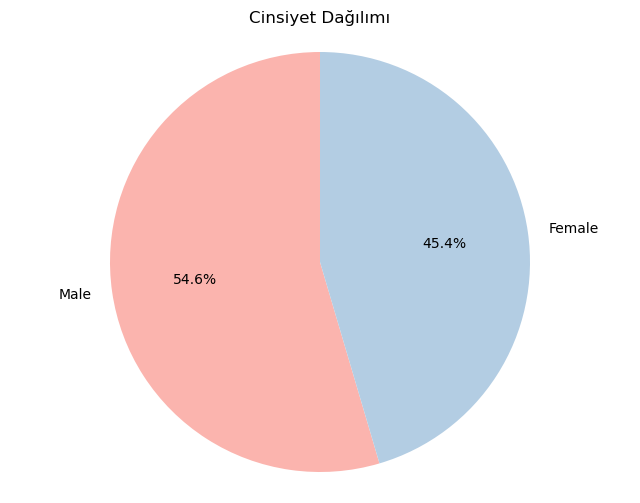

In [18]:
# Cinsiyetlerin frekanslarını al
gender_counts = df["Gender"].value_counts()

# Pasta grafiği çiz
plt.figure(figsize=(8, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", colors=plt.cm.Pastel1.colors, startangle=90)
plt.title("Cinsiyet Dağılımı")
plt.axis("equal")  # Daireyi yuvarlak yapmak için
plt.show()

### Coğrafya (Geography) Pasta grafiği

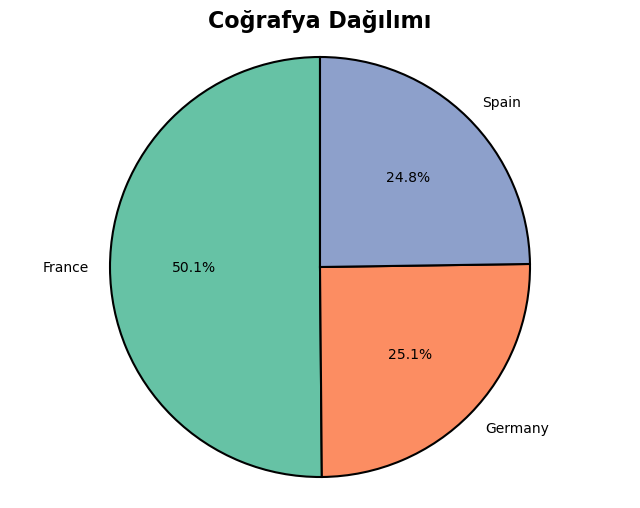

In [19]:
# Coğrafya verisinin frekanslarını al
geography_counts = df["Geography"].value_counts()

# Pasta grafiği çiz
plt.figure(figsize=(8, 6))
plt.pie(geography_counts, labels=geography_counts.index, autopct="%1.1f%%", colors=plt.cm.Set2.colors, startangle=90, 
        wedgeprops={"edgecolor": "black", "linewidth": 1.5, "linestyle": "solid"})
plt.title("Coğrafya Dağılımı", fontsize=16, weight="bold")
plt.axis("equal")  # Daireyi yuvarlak yapmak için
plt.show()

### Kart Türü (Card_Type) Pasta grafiği

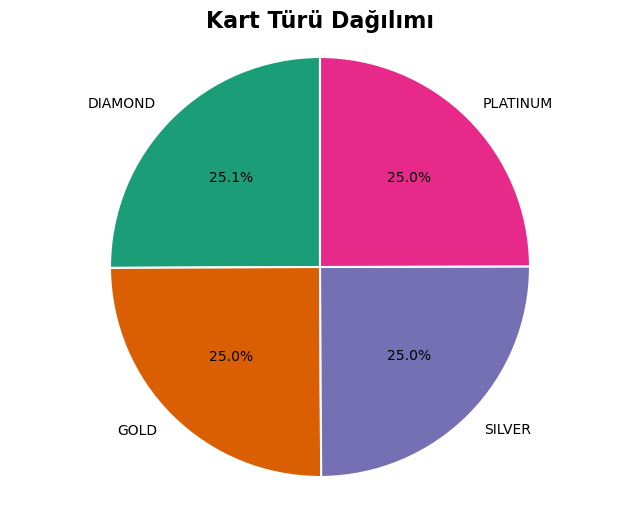

In [20]:
# Card_Type verisinin frekanslarını al
card_type_counts = df["Card_Type"].value_counts()

# Pasta grafiği çiz
plt.figure(figsize=(8, 6))
plt.pie(card_type_counts, labels=card_type_counts.index, autopct="%1.1f%%", colors=plt.cm.Dark2.colors, startangle=90, 
        wedgeprops={"edgecolor": "white", "linewidth": 1.5, "linestyle": "solid"})
plt.title("Kart Türü Dağılımı", fontsize=16, weight="bold")
plt.axis("equal")  # Daireyi yuvarlak yapmak için
plt.show()

### Memnuniyet Skoru (Satisfaction_Score) Pasta grafiği

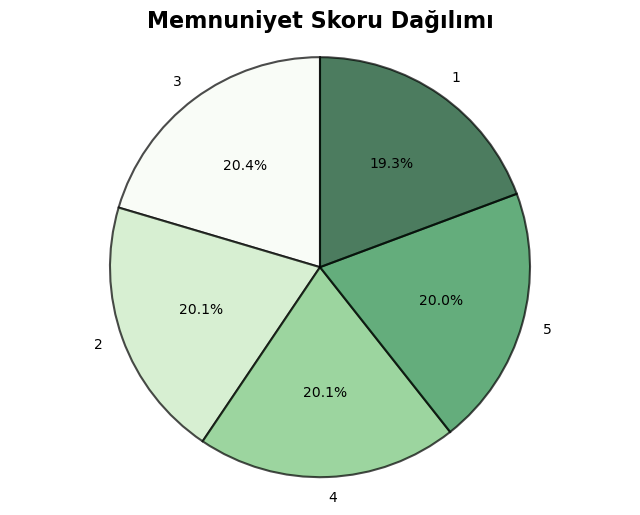

In [21]:
# Satisfaction_Score verisinin frekanslarını al
satisfaction_counts = df["Satisfaction_Score"].value_counts()

# Renk paleti seçimi (ListedColormap kullanarak)
colors = plt.cm.Greens(np.linspace(0, 1, len(satisfaction_counts)))

# Pasta grafiği çiz
plt.figure(figsize=(8, 6))
plt.pie(satisfaction_counts, labels=satisfaction_counts.index, autopct="%1.1f%%", colors=colors, startangle=90, 
        wedgeprops={"edgecolor": "black", "linewidth": 1.5, "linestyle": "solid", "alpha": 0.7})
plt.title("Memnuniyet Skoru Dağılımı", fontsize=16, weight="bold")
plt.axis("equal")  # Daireyi yuvarlak yapmak için
plt.show()

### Tenure Dağılımı

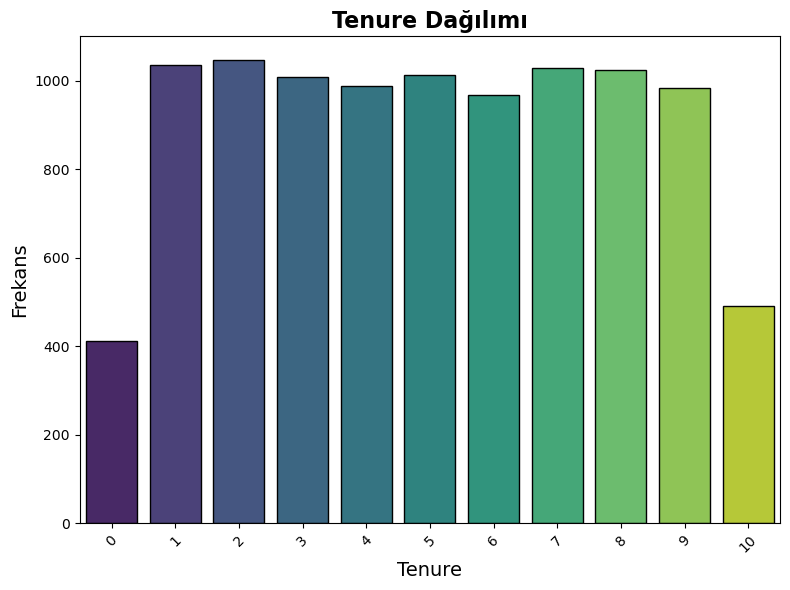

In [22]:
# Tenure değişkeninin frekanslarını al
plt.figure(figsize=(8, 6))
sns.countplot(x="Tenure", data=df, palette="viridis", edgecolor="black")

# Başlık ve etiketleri ekle
plt.title("Tenure Dağılımı", fontsize=16, weight="bold")
plt.xlabel("Tenure", fontsize=14)
plt.ylabel("Frekans", fontsize=14)

# Grafikteki bar'ların kenarlarını netleştir
plt.xticks(rotation=45)  # X eksenindeki etiketleri döndür, daha okunabilir olması için

# Görseli göster
plt.tight_layout()
plt.show()

### NumOfProducts Dağılımı

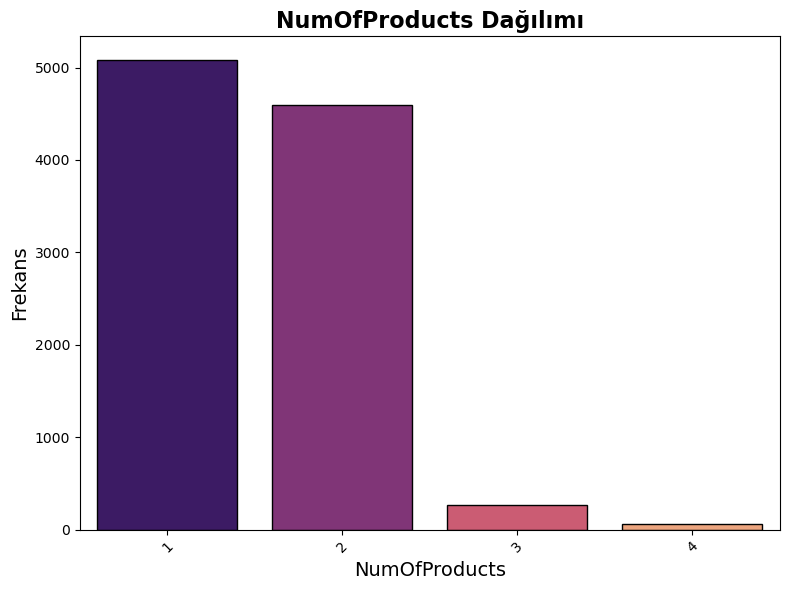

In [23]:
# NumOfProducts değişkeninin frekanslarını al
plt.figure(figsize=(8, 6))
sns.countplot(x="NumOfProducts", data=df, palette="magma", edgecolor="black")

# Başlık ve etiketleri ekle
plt.title("NumOfProducts Dağılımı", fontsize=16, weight="bold")
plt.xlabel("NumOfProducts", fontsize=14)
plt.ylabel("Frekans", fontsize=14)

# Grafikteki bar'ların kenarlarını netleştir
plt.xticks(rotation=45)  # X eksenindeki etiketleri döndür, daha okunabilir olması için

# Görseli göster
plt.tight_layout()
plt.show()

### Veri Hedefle Bağımlılık Analizi

In [24]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


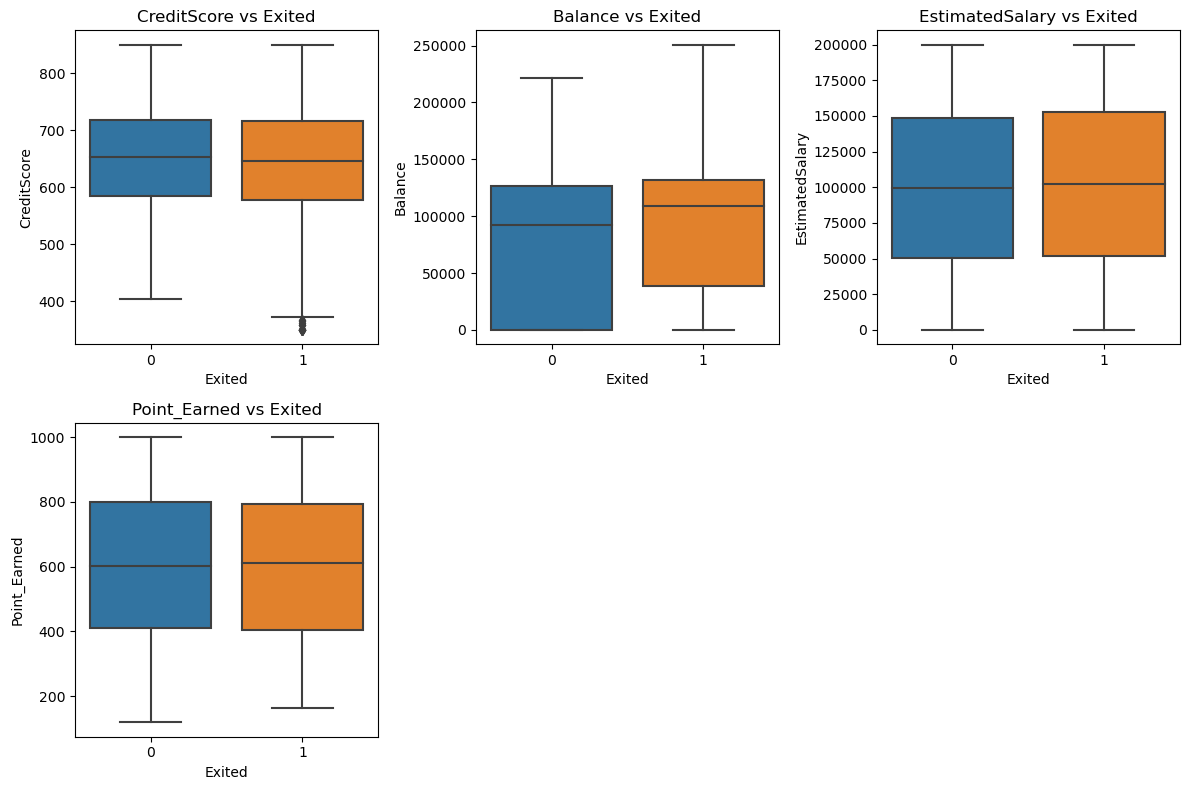

In [25]:
numerical_columns = ['CreditScore','Balance','EstimatedSalary','Point_Earned']
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Exited', y=col, data=df)
    plt.title(f'{col} vs Exited')
plt.tight_layout()
plt.show()


### Müşteri Ayrılma Durumu(Exited) Dağılımı

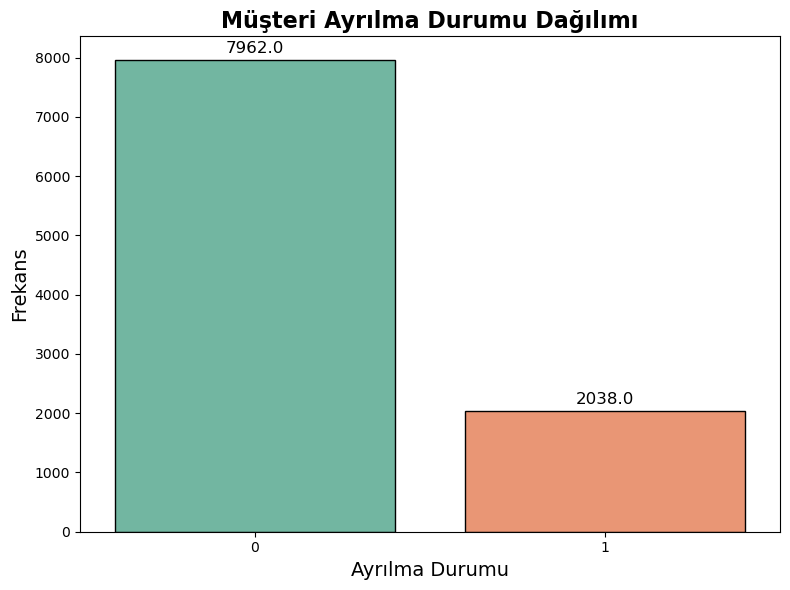

In [26]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x="Exited", data=df, palette="Set2", edgecolor="black")

# Her bir bar'ın içine değeri yaz
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                fontsize = 12, color = 'black', 
                xytext = (0, 8), textcoords = 'offset points')

# Başlık ve etiketleri ekle
plt.title("Müşteri Ayrılma Durumu Dağılımı", fontsize=16, weight="bold")
plt.xlabel("Ayrılma Durumu", fontsize=14)
plt.ylabel("Frekans", fontsize=14)

# Grafiği göster
plt.tight_layout()
plt.show()

### HasCrCard ve IsActiveMember pasta grafiği

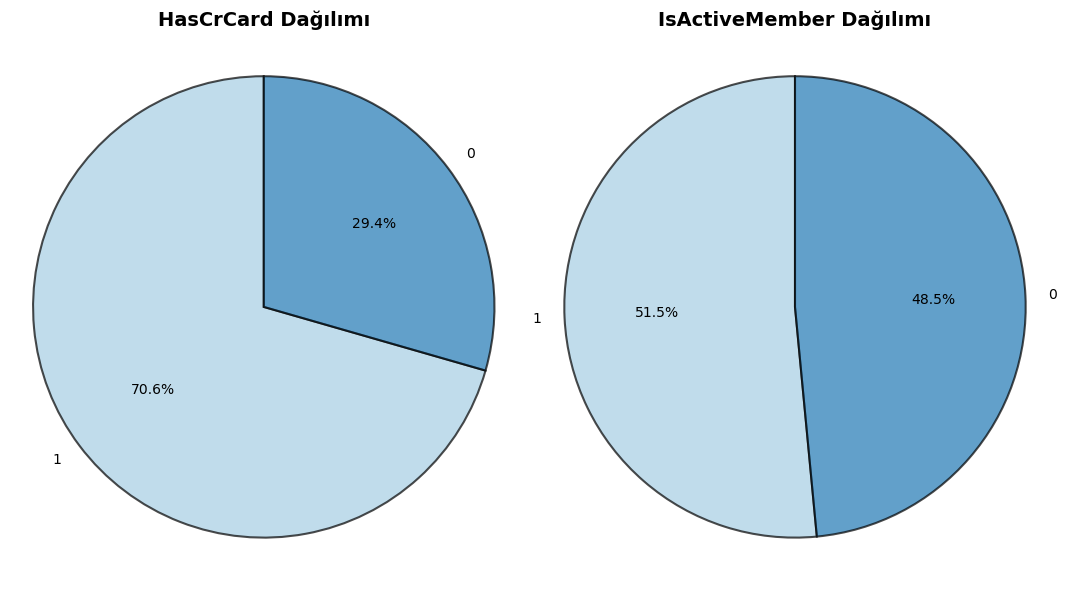

In [27]:
categorical_columns = ["HasCrCard", "IsActiveMember"]

# Görselin boyutunu ayarla
plt.figure(figsize=(16, 6))

# Pasta grafiği çizmek için her kategorik değişkeni döngüyle işlem
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(1, 3, i)  # 1 satır ve 3 sütundan oluşan bir grid oluştur
    counts = df[col].value_counts()  # Her kategorik değişkenin frekansını al
    plt.pie(counts, labels=counts.index, autopct="%1.1f%%", colors=plt.cm.Paired.colors, startangle=90, 
            wedgeprops={"edgecolor": "black", "linewidth": 1.5, "linestyle": "solid", "alpha": 0.7})
    plt.title(f"{col} Dağılımı", fontsize=14, weight="bold")
    plt.axis("equal")  # Daireyi yuvarlak yapmak için

# Görseli göster
plt.tight_layout()
plt.show()

## Etkilişimli grafikler

#### Bankadan Ayrılma Durumuna Göre Kredi Skoru Dağılımı

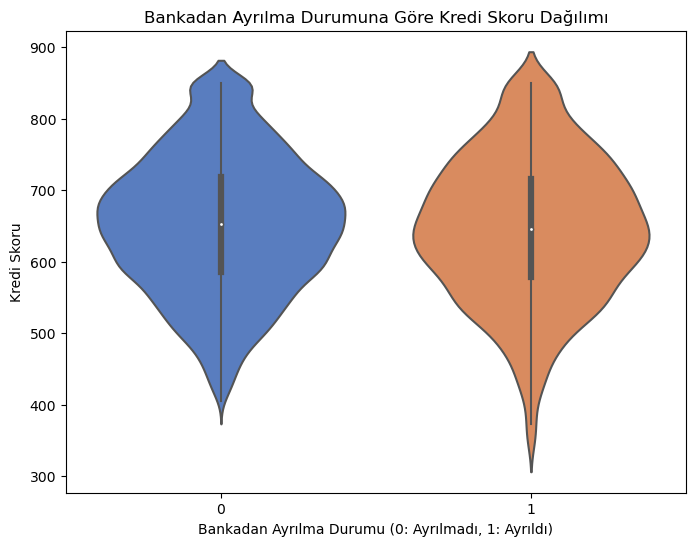

In [28]:
plt.figure(figsize=(8, 6))
sns.violinplot(x="Exited", y="CreditScore", data=df, palette="muted")
plt.title("Bankadan Ayrılma Durumuna Göre Kredi Skoru Dağılımı")
plt.xlabel("Bankadan Ayrılma Durumu (0: Ayrılmadı, 1: Ayrıldı)")
plt.ylabel("Kredi Skoru")
plt.show()

#### Coğrafyaya Göre Kredi Skoru Dağılımı

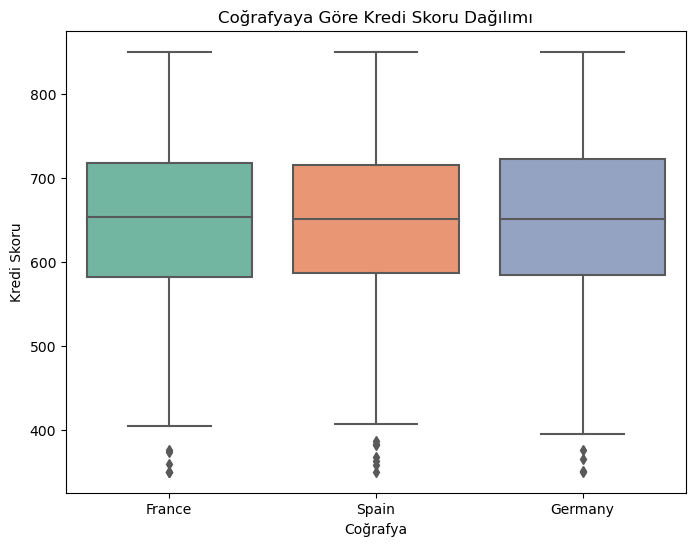

In [29]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Geography", y="CreditScore", data=df, palette="Set2")
plt.title("Coğrafyaya Göre Kredi Skoru Dağılımı")
plt.xlabel("Coğrafya")
plt.ylabel("Kredi Skoru")
plt.show()


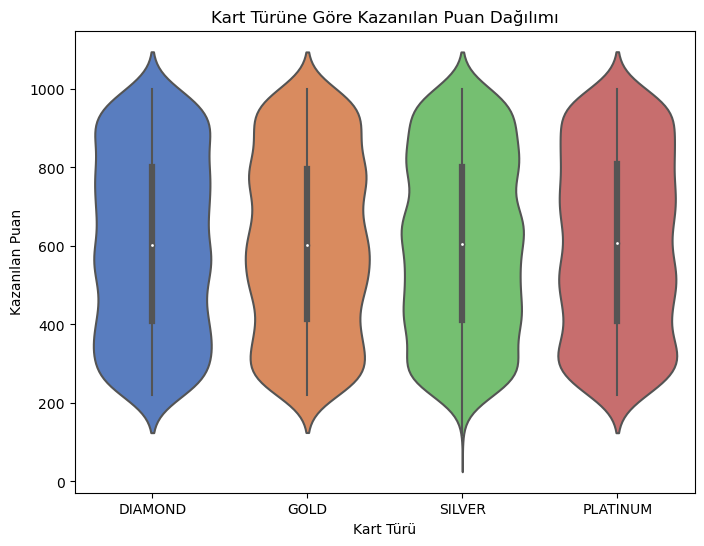

In [30]:
plt.figure(figsize=(8, 6))
sns.violinplot(x="Card_Type", y="Point_Earned", data=df, palette="muted")
plt.title("Kart Türüne Göre Kazanılan Puan Dağılımı")
plt.xlabel("Kart Türü")
plt.ylabel("Kazanılan Puan")
plt.show()


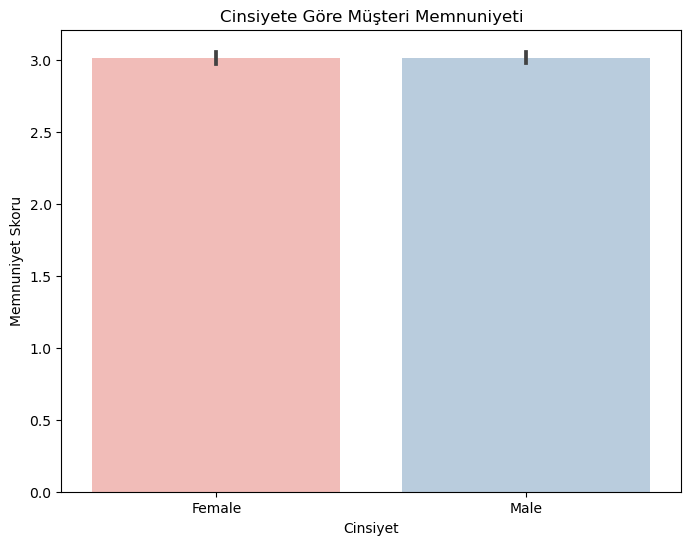

In [31]:
plt.figure(figsize=(8, 6))
sns.barplot(x="Gender", y="Satisfaction_Score", data=df, palette="Pastel1")
plt.title("Cinsiyete Göre Müşteri Memnuniyeti")
plt.xlabel("Cinsiyet")
plt.ylabel("Memnuniyet Skoru")
plt.show()


C:\Users\mehdi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mehdi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\mehdi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


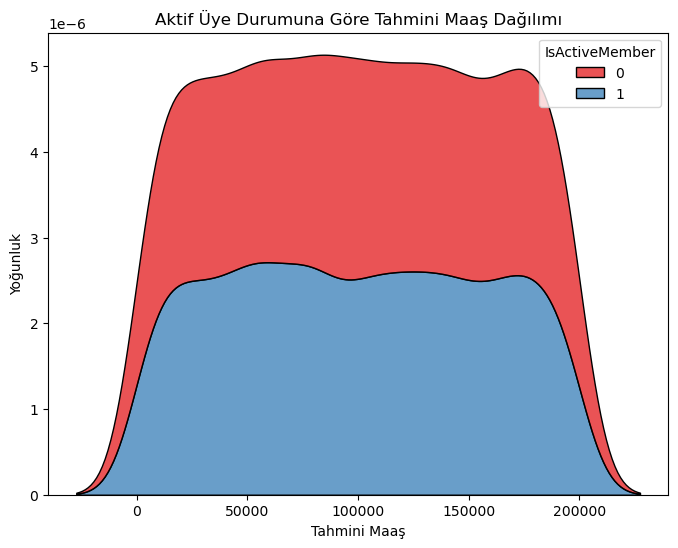

In [32]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x="EstimatedSalary", hue="IsActiveMember", multiple="stack", palette="Set1")
plt.title("Aktif Üye Durumuna Göre Tahmini Maaş Dağılımı")
plt.xlabel("Tahmini Maaş")
plt.ylabel("Yoğunluk")
plt.show()


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick # Yüzde formatlaması için

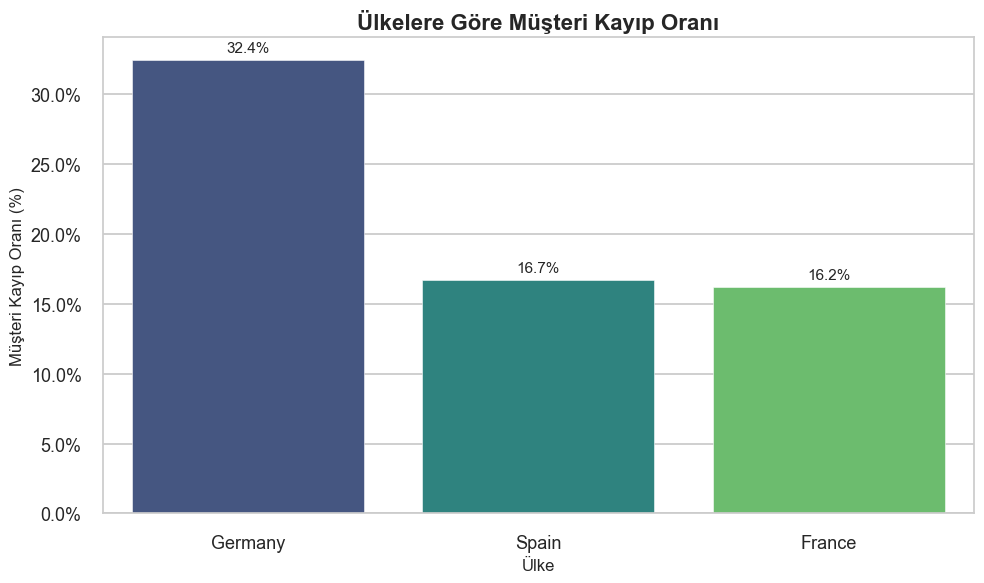


Grafik 1 Yorumu: Bu grafik, farklı ülkelerdeki müşteri kayıp oranlarını karşılaştırır. Örneğin, Almanya'daki müşterilerin ayrılma olasılığının diğer ülkelere göre daha yüksek olduğu görülebilir.
------------------------------------------------------------


In [34]:
sns.set_theme(style="whitegrid") # Daha şık bir tema
plt.style.use('seaborn-v0_8-talk') # Daha büyük ve okunaklı yazı tipleri
custom_palette = ["#6aabd4", "#d46a6a"] # Mavi (Kalan), Kırmızı (Ayrılan) tonları
churn_palette = {0: "#6aabd4", 1: "#d46a6a"} # Özel renk paleti (0: Kalan, 1: Ayrılan)

# --- Grafik 1: Ülkelere Göre Müşteri Kayıp Oranı (İkili Karşılaştırma: Geography vs Exited) ---
plt.figure(figsize=(10, 6))
# Grup bazında kayıp ortalamasını (oranını) hesapla
geo_churn = df.groupby('Geography')['Exited'].mean().reset_index().sort_values(by='Exited', ascending=False)
# Bar plot çiz
ax = sns.barplot(x='Geography', y='Exited', data=geo_churn, palette="viridis")
# Y eksenini yüzde formatına çevir
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.title('Ülkelere Göre Müşteri Kayıp Oranı', fontsize=16, fontweight='bold')
plt.xlabel('Ülke', fontsize=12)
plt.ylabel('Müşteri Kayıp Oranı (%)', fontsize=12)
# Barların üzerine değerleri yazdır
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points', fontsize=11)
plt.tight_layout()
plt.show()
print("\nGrafik 1 Yorumu: Bu grafik, farklı ülkelerdeki müşteri kayıp oranlarını karşılaştırır. Örneğin, Almanya'daki müşterilerin ayrılma olasılığının diğer ülkelere göre daha yüksek olduğu görülebilir.\n" + "-"*60)

C:\Users\mehdi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mehdi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\mehdi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


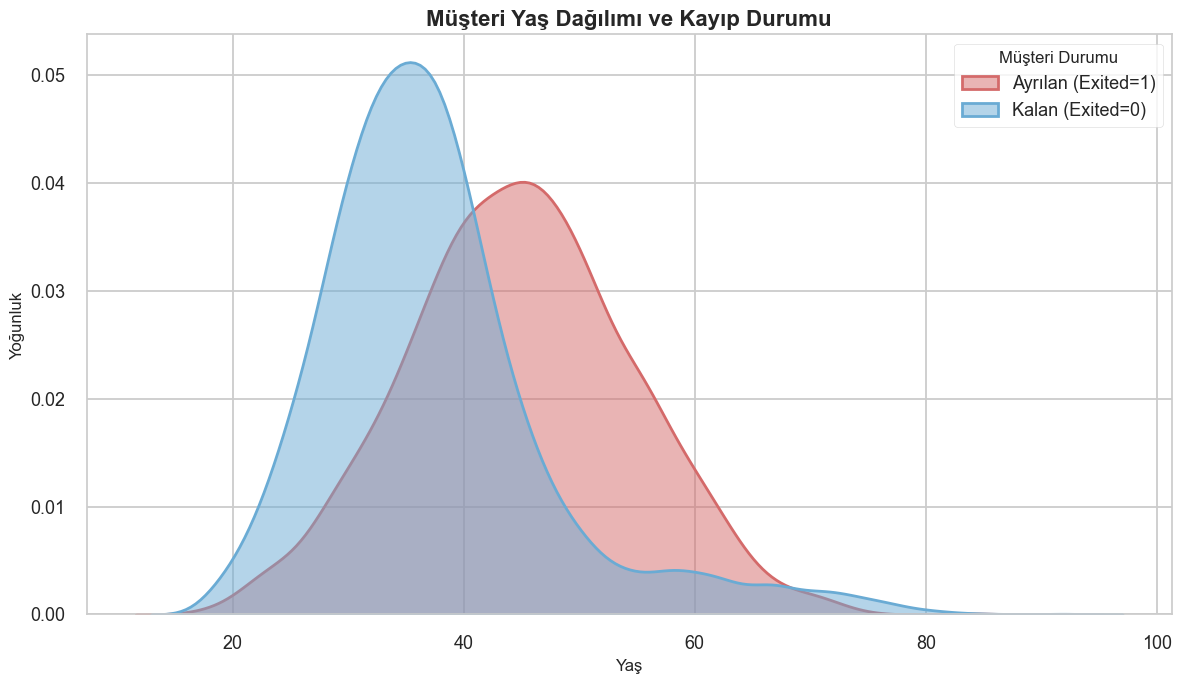


Grafik 2 Yorumu: Bu grafik, bankadan ayrılan (Exited=1) ve kalan (Exited=0) müşterilerin yaş dağılımlarını gösterir. Genellikle orta yaş ve üzeri (örn. 45-65 yaş arası) müşterilerin ayrılma eğiliminin daha yüksek olduğu gözlemlenebilirken, genç müşterilerin kalma eğilimi daha fazladır.
------------------------------------------------------------


In [35]:
# --- Grafik 2: Yaş Dağılımı ve Müşteri Kaybı (İkili Karşılaştırma: Age vs Exited) ---
plt.figure(figsize=(12, 7))
# Ayrılan ve Kalan müşteriler için yaş dağılımını göster (KDE Plot)
sns.kdeplot(data=df, x='Age', hue='Exited', fill=True, common_norm=False, palette=churn_palette, alpha=0.5, linewidth=2)
plt.title('Müşteri Yaş Dağılımı ve Kayıp Durumu', fontsize=16, fontweight='bold')
plt.xlabel('Yaş', fontsize=12)
plt.ylabel('Yoğunluk', fontsize=12)
plt.legend(title='Müşteri Durumu', labels=['Ayrılan (Exited=1)', 'Kalan (Exited=0)'])
plt.tight_layout()
plt.show()
print("\nGrafik 2 Yorumu: Bu grafik, bankadan ayrılan (Exited=1) ve kalan (Exited=0) müşterilerin yaş dağılımlarını gösterir. Genellikle orta yaş ve üzeri (örn. 45-65 yaş arası) müşterilerin ayrılma eğiliminin daha yüksek olduğu gözlemlenebilirken, genç müşterilerin kalma eğilimi daha fazladır.\n" + "-"*60)

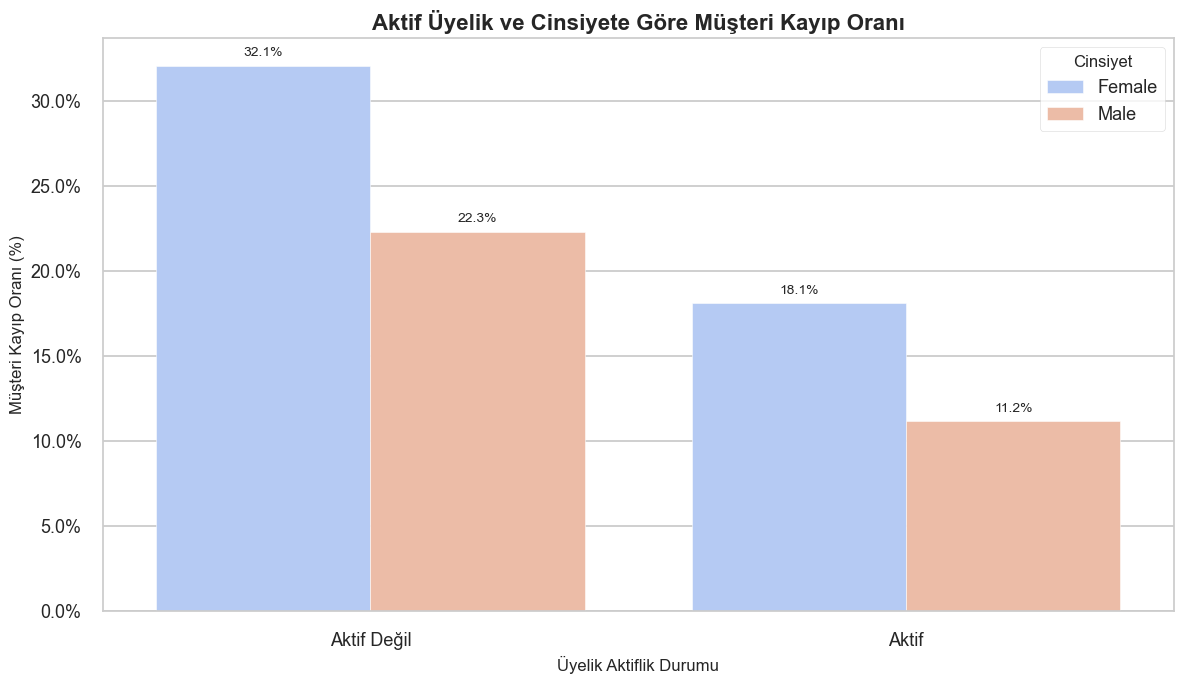


Grafik 3 Yorumu: Bu üçlü karşılaştırma, hem aktif üyelik durumunun hem de cinsiyetin müşteri kaybı üzerindeki etkisini gösterir. Genel olarak aktif olmayan üyelerin kayıp oranının daha yüksek olduğu görülür. Ayrıca, bazı durumlarda cinsiyetler arasında da (örn. aktif olmayan kadınlar vs aktif olmayan erkekler) kayıp oranlarında farklılıklar olabilir.
------------------------------------------------------------


In [36]:
# --- Grafik 3: Aktif Üyelik Durumu ve Cinsiyete Göre Kayıp Oranı (Üçlü Karşılaştırma: IsActiveMember, Gender, Exited) ---
plt.figure(figsize=(12, 7))
# Aktiflik ve Cinsiyete göre gruplayıp kayıp oranını hesapla
active_gender_churn = df.groupby(['IsActiveMember', 'Gender'])['Exited'].mean().reset_index()
active_gender_churn['IsActiveMember'] = active_gender_churn['IsActiveMember'].map({0: 'Aktif Değil', 1: 'Aktif'}) # Daha anlaşılır etiketler
# Çubuk grafik çiz
ax = sns.barplot(data=active_gender_churn, x='IsActiveMember', y='Exited', hue='Gender', palette="coolwarm")
# Y eksenini yüzde formatına çevir
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.title('Aktif Üyelik ve Cinsiyete Göre Müşteri Kayıp Oranı', fontsize=16, fontweight='bold')
plt.xlabel('Üyelik Aktiflik Durumu', fontsize=12)
plt.ylabel('Müşteri Kayıp Oranı (%)', fontsize=12)
plt.legend(title='Cinsiyet', loc='upper right')
# Barların üzerine değerleri yazdır
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points', fontsize=10)
plt.tight_layout()
plt.show()
print("\nGrafik 3 Yorumu: Bu üçlü karşılaştırma, hem aktif üyelik durumunun hem de cinsiyetin müşteri kaybı üzerindeki etkisini gösterir. Genel olarak aktif olmayan üyelerin kayıp oranının daha yüksek olduğu görülür. Ayrıca, bazı durumlarda cinsiyetler arasında da (örn. aktif olmayan kadınlar vs aktif olmayan erkekler) kayıp oranlarında farklılıklar olabilir.\n" + "-"*60)

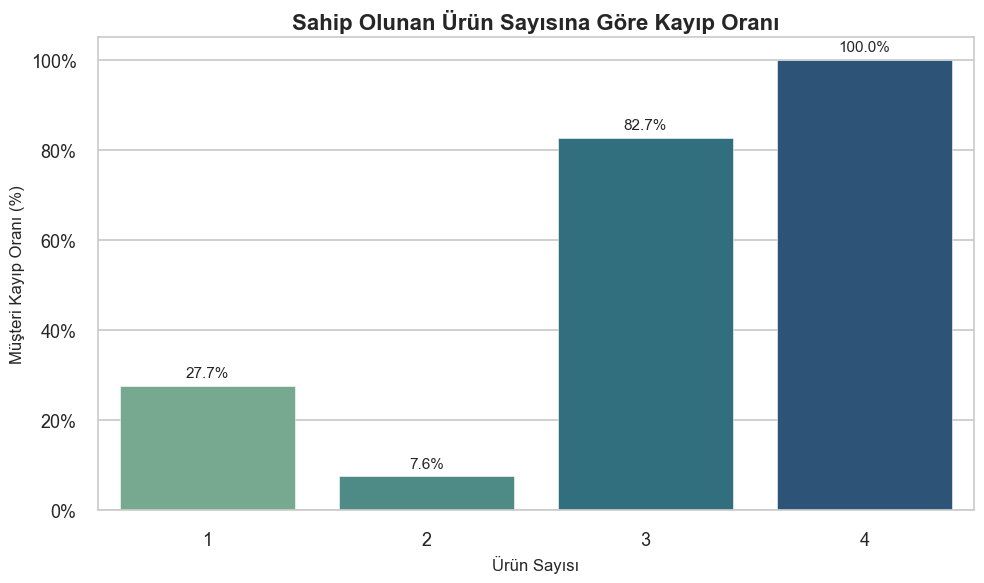


Grafik 4 Yorumu: Müşterinin sahip olduğu ürün sayısı ile ayrılma olasılığı arasındaki ilişkiyi gösterir. Genellikle 1 veya 2 ürüne sahip müşterilerin kalma olasılığı daha yüksektir. 3 veya daha fazla ürüne sahip müşterilerde ise (belki de karmaşıklık veya ihtiyaçların karşılanamaması nedeniyle) ayrılma oranının arttığı görülebilir.
------------------------------------------------------------


In [37]:
# --- Grafik 4: Sahip Olunan Ürün Sayısı ve Müşteri Kaybı (İkili Karşılaştırma: NumOfProducts vs Exited) ---
plt.figure(figsize=(10, 6))
# Ürün sayısına göre kayıp oranını hesapla
prod_churn = df.groupby('NumOfProducts')['Exited'].mean().reset_index()
# Çubuk grafik çiz
ax = sns.barplot(data=prod_churn, x='NumOfProducts', y='Exited', palette="crest")
# Y eksenini yüzde formatına çevir
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.title('Sahip Olunan Ürün Sayısına Göre Kayıp Oranı', fontsize=16, fontweight='bold')
plt.xlabel('Ürün Sayısı', fontsize=12)
plt.ylabel('Müşteri Kayıp Oranı (%)', fontsize=12)
# Barların üzerine değerleri yazdır
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points', fontsize=11)
plt.tight_layout()
plt.show()
print("\nGrafik 4 Yorumu: Müşterinin sahip olduğu ürün sayısı ile ayrılma olasılığı arasındaki ilişkiyi gösterir. Genellikle 1 veya 2 ürüne sahip müşterilerin kalma olasılığı daha yüksektir. 3 veya daha fazla ürüne sahip müşterilerde ise (belki de karmaşıklık veya ihtiyaçların karşılanamaması nedeniyle) ayrılma oranının arttığı görülebilir.\n" + "-"*60)


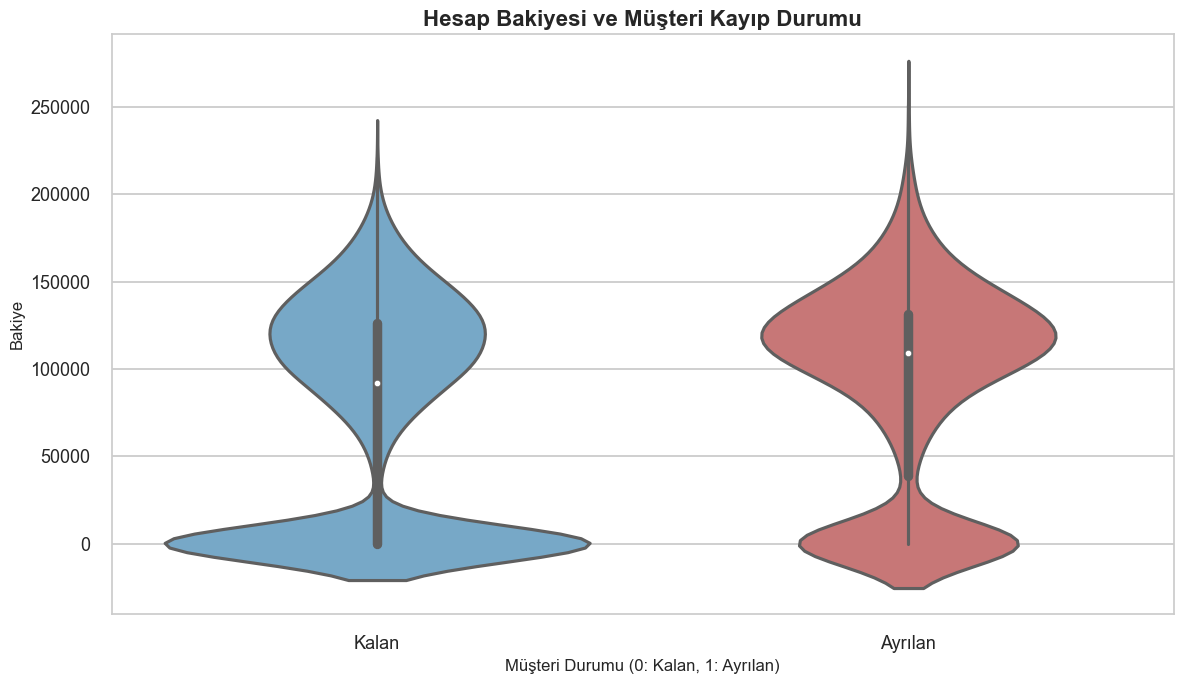


Grafik 5 Yorumu: Bu keman grafiği, ayrılan ve kalan müşterilerin hesap bakiyesi dağılımlarını karşılaştırır. Genellikle bakiyesi sıfır olmayan (yani hesabında para bulunan) müşteriler arasında ayrılma oranının daha yüksek olabileceği gözlemlenir. Bakiyesi sıfır olan müşterilerin ise genellikle kalma eğiliminde olduğu görülür. Ayrılan müşterilerin bakiye dağılımı daha merkezde toplanmış olabilir.
------------------------------------------------------------


In [38]:
# --- Grafik 5: Bakiye ve Müşteri Kaybı (İkili Karşılaştırma: Balance vs Exited) ---
plt.figure(figsize=(12, 7))
# Keman grafiği (Box + KDE) ile bakiye dağılımını kayıp durumuna göre göster
sns.violinplot(data=df, x='Exited', y='Balance', palette=churn_palette)
plt.title('Hesap Bakiyesi ve Müşteri Kayıp Durumu', fontsize=16, fontweight='bold')
plt.xlabel('Müşteri Durumu (0: Kalan, 1: Ayrılan)', fontsize=12)
plt.ylabel('Bakiye', fontsize=12)
plt.xticks([0, 1], ['Kalan', 'Ayrılan']) # X ekseni etiketlerini düzelt
plt.tight_layout()
plt.show()
print("\nGrafik 5 Yorumu: Bu keman grafiği, ayrılan ve kalan müşterilerin hesap bakiyesi dağılımlarını karşılaştırır. Genellikle bakiyesi sıfır olmayan (yani hesabında para bulunan) müşteriler arasında ayrılma oranının daha yüksek olabileceği gözlemlenir. Bakiyesi sıfır olan müşterilerin ise genellikle kalma eğiliminde olduğu görülür. Ayrılan müşterilerin bakiye dağılımı daha merkezde toplanmış olabilir.\n" + "-"*60)

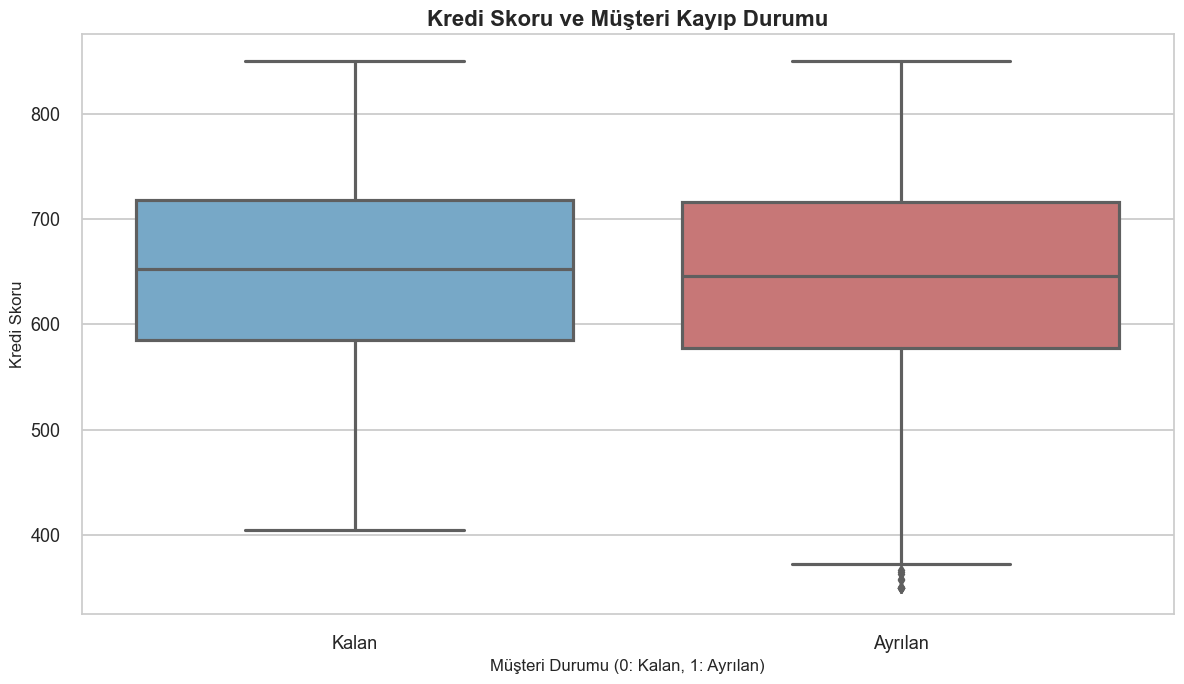


Grafik 6 Yorumu: Kredi skorunun müşteri kaybı ile ilişkisini gösterir. Genellikle çok düşük kredi skoruna sahip müşterilerde hafif bir ayrılma eğilimi artışı görülebilir, ancak genel olarak kredi skorunun tek başına çok güçlü bir ayrım yapmadığı durumlar da olabilir. Ayrılan ve kalan müşterilerin medyan kredi skorları birbirine yakın olabilir.
------------------------------------------------------------


In [39]:
# --- Grafik 6: Kredi Skoru ve Müşteri Kaybı (İkili Karşılaştırma: CreditScore vs Exited) ---
plt.figure(figsize=(12, 7))
# Box plot ile kredi skoru dağılımını kayıp durumuna göre göster
sns.boxplot(data=df, x='Exited', y='CreditScore', palette=churn_palette)
plt.title('Kredi Skoru ve Müşteri Kayıp Durumu', fontsize=16, fontweight='bold')
plt.xlabel('Müşteri Durumu (0: Kalan, 1: Ayrılan)', fontsize=12)
plt.ylabel('Kredi Skoru', fontsize=12)
plt.xticks([0, 1], ['Kalan', 'Ayrılan']) # X ekseni etiketlerini düzelt
plt.tight_layout()
plt.show()
print("\nGrafik 6 Yorumu: Kredi skorunun müşteri kaybı ile ilişkisini gösterir. Genellikle çok düşük kredi skoruna sahip müşterilerde hafif bir ayrılma eğilimi artışı görülebilir, ancak genel olarak kredi skorunun tek başına çok güçlü bir ayrım yapmadığı durumlar da olabilir. Ayrılan ve kalan müşterilerin medyan kredi skorları birbirine yakın olabilir.\n" + "-"*60)

## Korelasyon Analizi

In [40]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

def encode_categorical_columns(df):
    le = LabelEncoder()
    categorical_cols = df.select_dtypes(include=['object']).columns  # Sayısal olmayan sütunları seç
    
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col])  # Label encoding işlemi
    
    return df

In [41]:
df_1 = df.copy()

In [42]:
encode_categorical_columns(df_1)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0,0,1,0,300
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0,0,5,2,771
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1,1,3,3,564
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1,1,2,1,339


In [43]:
# Korelasyon matrisini hesapla
corr_matrix = df_1.corr()

In [44]:
corr_matrix

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned
CreditScore,1.000000,0.007888,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.026771,-0.027048,-0.012599,-0.006936,0.000077
Geography,0.007888,1.000000,0.004719,0.022812,0.003739,0.069408,0.003972,-0.008523,0.006724,-0.001369,0.035712,0.035830,-0.001718,-0.013462,-0.008479
Gender,-0.002857,0.004719,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106267,-0.106287,0.000242,-0.008726,-0.013225
Age,-0.003965,0.022812,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285296,0.283530,-0.000876,-0.006997,0.002222
Tenure,0.000842,0.003739,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.013656,-0.013047,0.008663,-0.001414,-0.010196
Balance,0.006268,0.069408,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118577,0.119124,-0.002588,-0.027059,0.014608
NumOfProducts,0.012238,0.003972,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047611,-0.046357,-0.011394,0.020387,-0.015330
HasCrCard,-0.005458,-0.008523,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.006976,-0.007095,-0.000212,0.005809,-0.011041
IsActiveMember,0.025651,0.006724,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156356,-0.154741,0.010236,0.016247,-0.004983
EstimatedSalary,-0.001384,-0.001369,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012490,0.012494,-0.013747,0.014295,-0.001515


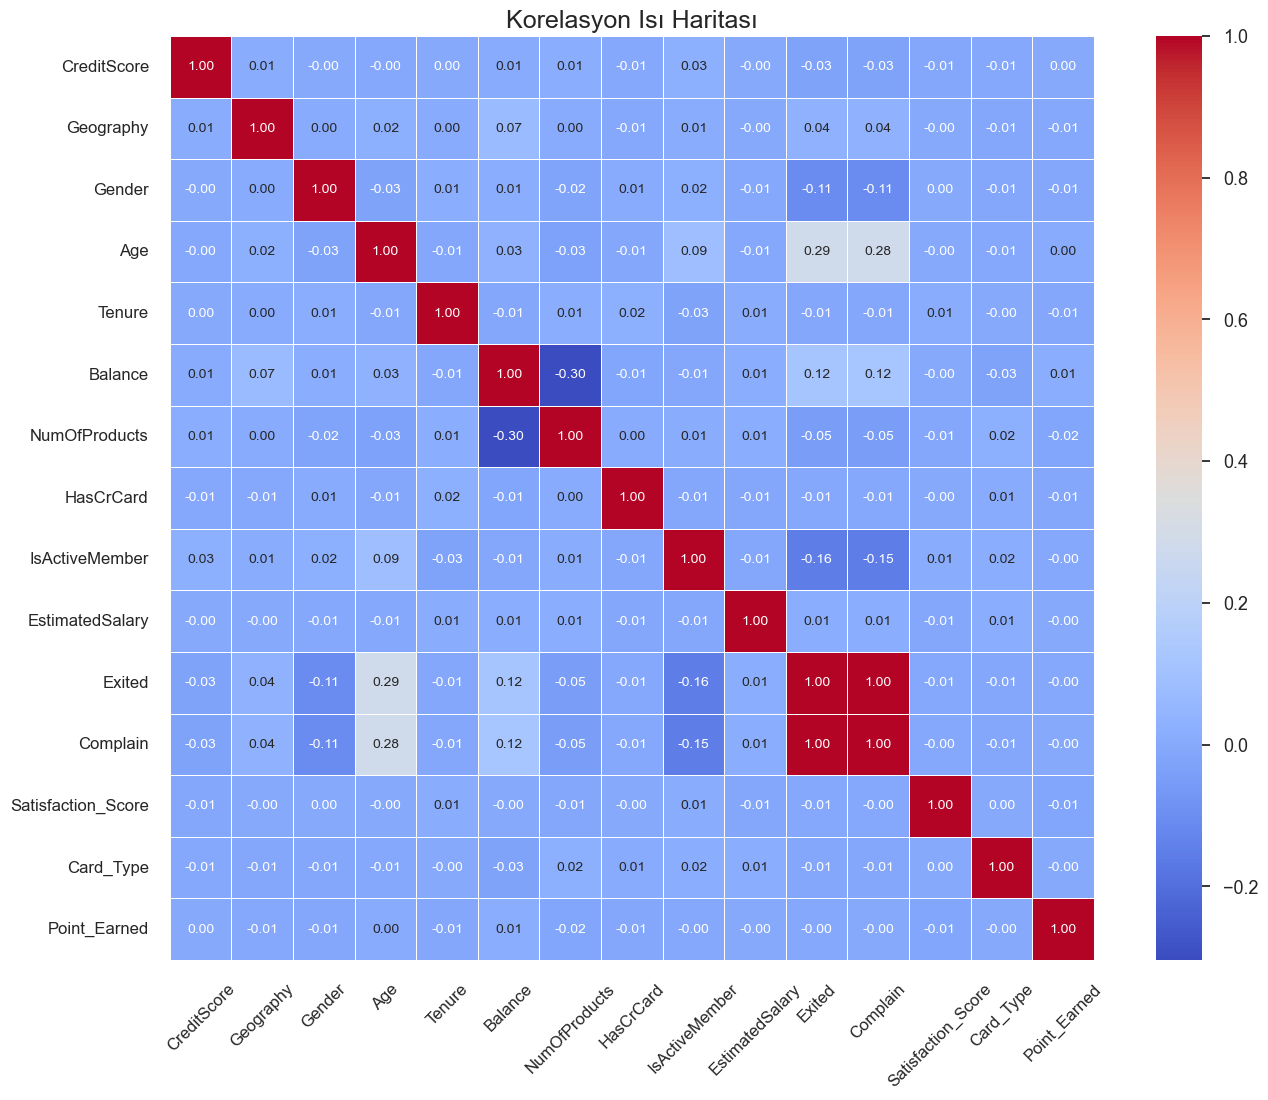

In [45]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5, annot_kws={"size": 10})
plt.title('Korelasyon Isı Haritası', fontsize=18)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.show()

In [46]:
def optimize_correlation(df, target_col, initial_corr_threshold=1.0, step=0.05, min_corr_threshold=0.3):
    results = []
    
    # Hedef değişkeni ve bağımsız değişkenleri ayırma
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # Başlangıç modeli
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    base_accuracy = accuracy_score(y_test, y_pred)
    results.append((initial_corr_threshold, "No Removal", base_accuracy))
    
    # Korelasyon matrisini hesaplama
    corr_matrix = df.corr().abs()
    np.fill_diagonal(corr_matrix.values, 0)
    
    current_threshold = initial_corr_threshold
    while current_threshold > min_corr_threshold:
        # Mevcut eşiğe göre yüksek korelasyona sahip değişken çiftlerini bul
        correlated_pairs = [(a, b) for a, b in zip(*np.where(corr_matrix >= current_threshold)) if a < b]
        
        if not correlated_pairs:
            current_threshold -= step
            continue
        
        for A, B in correlated_pairs:
            col_A, col_B = df.columns[A], df.columns[B]
            
            # Farklı senaryoları test et
            for remove_vars in [[col_A], [col_B], [col_A, col_B]]:
                X_reduced = X.drop(columns=remove_vars, errors='ignore')
                X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                accuracy = accuracy_score(y_test, y_pred)
                results.append((current_threshold, f"Removed {remove_vars}", accuracy))
        
        # Eşiği azalt
        current_threshold -= step
        corr_matrix = df.corr().abs()
        np.fill_diagonal(corr_matrix.values, 0)
    
    # Sonuçları analiz etme
    best_result = max(results, key=lambda x: x[2])
    print("En yüksek doğruluk:", best_result[2])
    print("Korelasyon eşiği:", best_result[0])
    print("Silinen değişkenler:", best_result[1])
    
    return results


In [47]:
df_1 = df_1.drop(columns=['Complain'])

In [48]:
optimize_correlation(df_1,'Exited', initial_corr_threshold=0.40, step=0.01, min_corr_threshold=0.01)

En yüksek doğruluk: 0.863
Korelasyon eşiği: 0.019999999999999803
Silinen değişkenler: Removed ['Tenure', 'HasCrCard']


[(0.4, 'No Removal', 0.853),
 (0.29999999999999993, "Removed ['Balance']", 0.8505),
 (0.29999999999999993, "Removed ['NumOfProducts']", 0.83),
 (0.29999999999999993, "Removed ['Balance', 'NumOfProducts']", 0.8255),
 (0.2899999999999999, "Removed ['Balance']", 0.8505),
 (0.2899999999999999, "Removed ['NumOfProducts']", 0.83),
 (0.2899999999999999, "Removed ['Balance', 'NumOfProducts']", 0.8255),
 (0.2799999999999999, "Removed ['Age']", 0.819),
 (0.2799999999999999, "Removed ['Exited']", 0.853),
 (0.2799999999999999, "Removed ['Age', 'Exited']", 0.819),
 (0.2799999999999999, "Removed ['Balance']", 0.8505),
 (0.2799999999999999, "Removed ['NumOfProducts']", 0.83),
 (0.2799999999999999, "Removed ['Balance', 'NumOfProducts']", 0.8255),
 (0.2699999999999999, "Removed ['Age']", 0.819),
 (0.2699999999999999, "Removed ['Exited']", 0.853),
 (0.2699999999999999, "Removed ['Age', 'Exited']", 0.819),
 (0.2699999999999999, "Removed ['Balance']", 0.8505),
 (0.2699999999999999, "Removed ['NumOfProduct

## aykırı değer analizi

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  object 
 2   Gender              10000 non-null  object 
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-null  int64  
 7   HasCrCard           10000 non-null  int64  
 8   IsActiveMember      10000 non-null  int64  
 9   EstimatedSalary     10000 non-null  float64
 10  Exited              10000 non-null  int64  
 11  Complain            10000 non-null  int64  
 12  Satisfaction_Score  10000 non-null  int64  
 13  Card_Type           10000 non-null  object 
 14  Point_Earned        10000 non-null  int64  
dtypes: float64(2), int64(10), object(3)
memory usage: 1.1+

In [50]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [51]:
df_2 = df.copy()

In [52]:
df_2 = df_2.drop(columns=['Geography','Gender','NumOfProducts','HasCrCard','IsActiveMember','Complain','Satisfaction_Score',
                          'Card_Type','Exited'])

### IQR analizi

In [53]:
import scipy.stats as stats

In [54]:
def aykiri_deger_degiskenleri_bul(df, iqr_multiplier=1.5):
    """
    Veri çerçevesindeki hangi sayısal sütunların aykırı değer içerdiğini bulur.

    Args:
        df (pd.DataFrame): Analiz edilecek veri çerçevesi.
        iqr_multiplier (float): IQR çarpanı. Varsayılan değer 1.5'tir.

    Returns:
        list: Aykırı değer içeren sütunların adlarını içeren bir liste.
             DataFrame'de hiç sayısal sütun yoksa boş bir liste döndürür.

    """
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    
    if not numeric_cols:
        return [] # Hiç sayısal sütun yoksa boş liste döndür
        
    outlier_columns = []

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR

        # Sütunda IQR yöntemine göre aykırı değer varsa, sütun adını listeye ekle
        if any((df[col] < lower_bound) | (df[col] > upper_bound)):
            outlier_columns.append(col)

    return outlier_columns

In [55]:
aykiri_deger_degiskenleri_bul(df_2)

['CreditScore', 'Age']

In [56]:
# 2️⃣ Aykırı Değer Analizi için Değişken Seçimi
numeric_columns = df_2.select_dtypes(include=[np.number]).columns.tolist()

# IQR Yöntemi ile Aykırı Değer Analizi
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

outlier_counts_iqr = {}
for col in numeric_columns:
    outliers = detect_outliers_iqr(df_2, col)  # data yerine df kullanıldı
    outlier_counts_iqr[col] = len(outliers)

# Aykırı değer sayısını yazdırma
print(outlier_counts_iqr)

{'CreditScore': 15, 'Age': 359, 'Tenure': 0, 'Balance': 0, 'EstimatedSalary': 0, 'Point_Earned': 0}


### z-score

In [57]:
def aykiri_deger_degiskenleri_bul_zscore(df, z_threshold=3):
    """
    Veri çerçevesindeki hangi sayısal sütunların Z-skoruna göre aykırı değer içerdiğini bulur.

    Args:
        df (pd.DataFrame): Analiz edilecek veri çerçevesi.
        z_threshold (float): Z-skoru eşiği. Varsayılan değer 3'tür.

    Returns:
        list: Aykırı değer içeren sütunların adlarını içeren bir liste.
             DataFrame'de hiç sayısal sütun yoksa boş bir liste döndürür.
    """

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    if not numeric_cols:
        return []  # Hiç sayısal sütun yoksa boş liste döndür

    outlier_columns = []

    for col in numeric_cols:
        z = np.abs(stats.zscore(df[col]))

        # Sütunda Z-skoru eşik değerini aşan bir değer varsa, sütun adını listeye ekle
        if any(z > z_threshold):
            outlier_columns.append(col)

    return outlier_columns

In [58]:
aykiri_deger_degiskenleri_bul_zscore(df_2)

['CreditScore', 'Age']

### IQR ve Z-Score Yöntemlerinin Aykırı Değer Tespitindeki Karşılaştırması

In [59]:
# Aykırı değer içeren değişkenleri bulan iki farklı yöntem
aykiri_iqr = set(aykiri_deger_degiskenleri_bul(df_2))
aykiri_zscore = set(aykiri_deger_degiskenleri_bul_zscore(df_2))

# Ortak değişkenler
ortak_degiskenler = aykiri_iqr & aykiri_zscore

# Ortak olmayan değişkenler
sadece_iqr = aykiri_iqr - aykiri_zscore
sadece_zscore = aykiri_zscore - aykiri_iqr

# Sonuçları yazdırma
print(f"✅ Ortak Aykırı Değer İçeren Değişkenler: {list(ortak_degiskenler)}")
print(f"📌 Sadece IQR Yöntemi ile Aykırı Olarak Belirlenenler: {list(sadece_iqr)}")
print(f"📌 Sadece Z-Score Yöntemi ile Aykırı Olarak Belirlenenler: {list(sadece_zscore)}")


✅ Ortak Aykırı Değer İçeren Değişkenler: ['Age', 'CreditScore']
📌 Sadece IQR Yöntemi ile Aykırı Olarak Belirlenenler: []
📌 Sadece Z-Score Yöntemi ile Aykırı Olarak Belirlenenler: []


### Aykırı değer görselleştirme

C:\Users\mehdi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


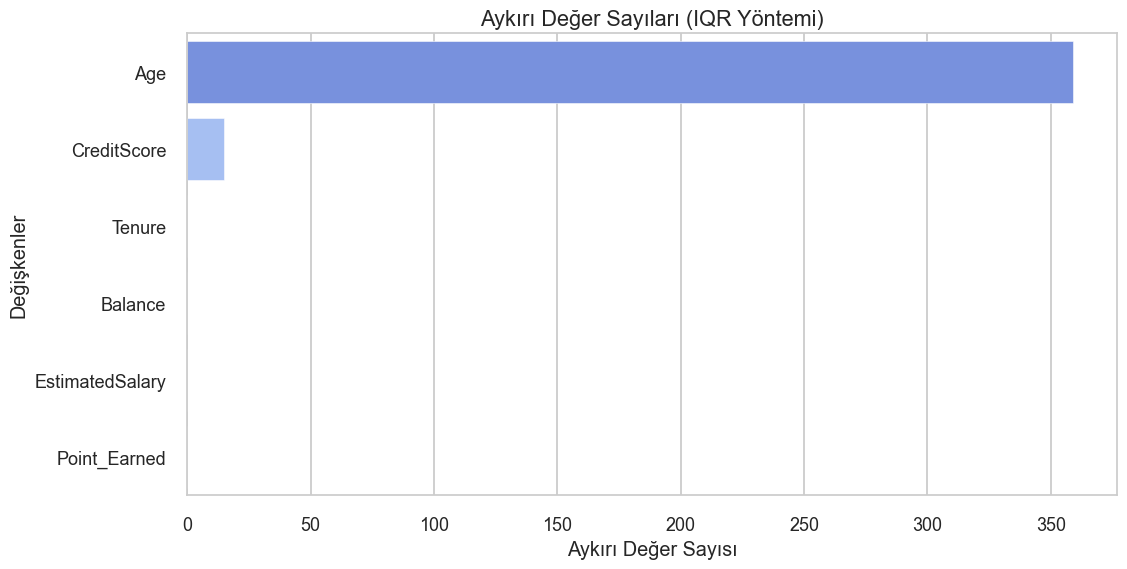

In [60]:
# Aykırı Değer Sayıları
outlier_counts = {}
for col in df_2.select_dtypes(include=[np.number]).columns:
    Q1 = df_2[col].quantile(0.25)
    Q3 = df_2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_counts[col] = ((df[col] < lower_bound) | (df_2[col] > upper_bound)).sum()

outlier_counts = dict(sorted(outlier_counts.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(12, 6))
sns.barplot(x=list(outlier_counts.values()), y=list(outlier_counts.keys()), palette="coolwarm")
plt.title("Aykırı Değer Sayıları (IQR Yöntemi)")
plt.xlabel("Aykırı Değer Sayısı")
plt.ylabel("Değişkenler")
plt.show()

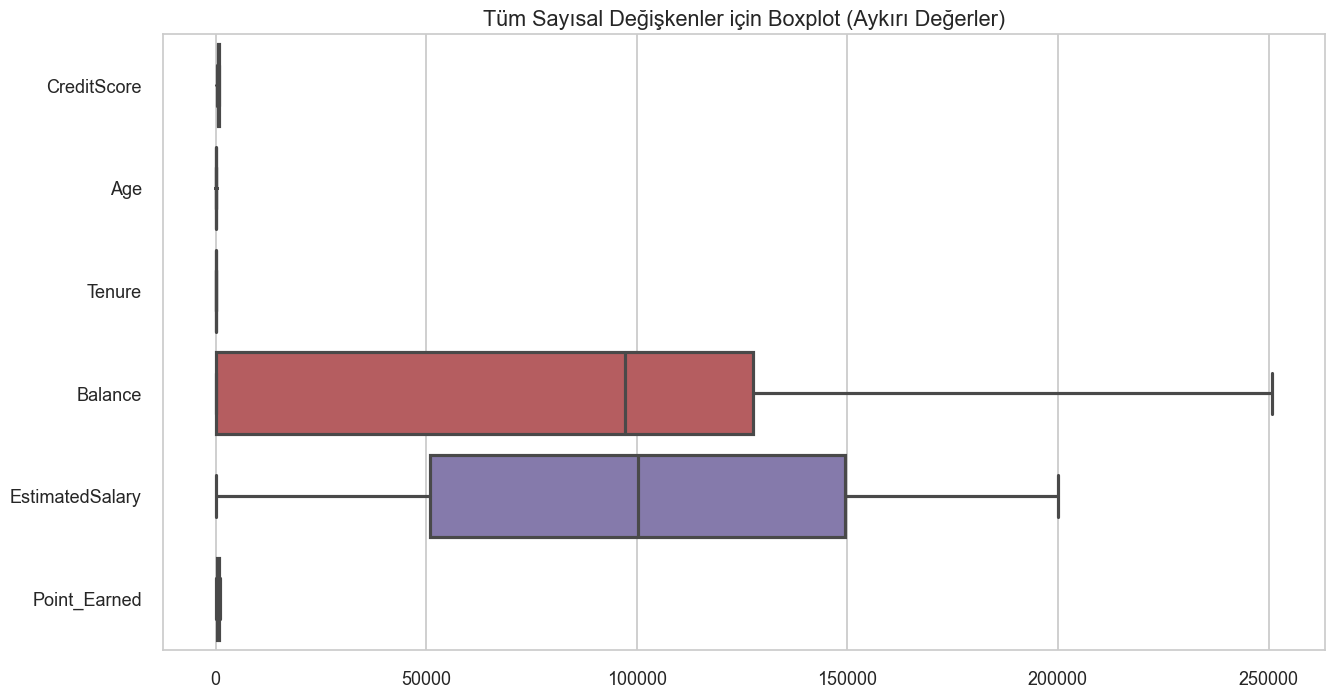

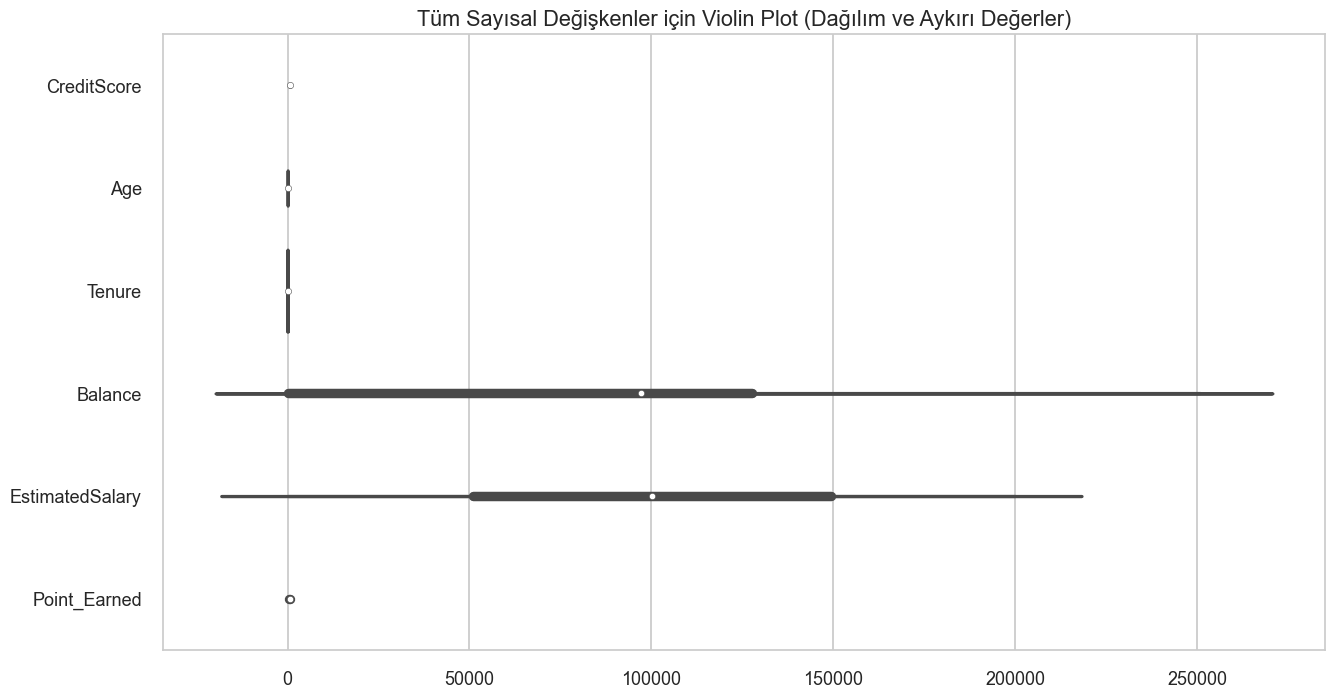

In [61]:
# Aykırı Değer Analizi (Toplu Görselleştirme)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_2.select_dtypes(include=[np.number]), orient="h", fliersize=2) 
plt.title("Tüm Sayısal Değişkenler için Boxplot (Aykırı Değerler)")
plt.show()

plt.figure(figsize=(15, 8))
sns.violinplot(data=df_2.select_dtypes(include=[np.number]), orient="h") 
plt.title("Tüm Sayısal Değişkenler için Violin Plot (Dağılım ve Aykırı Değerler)")
plt.show()

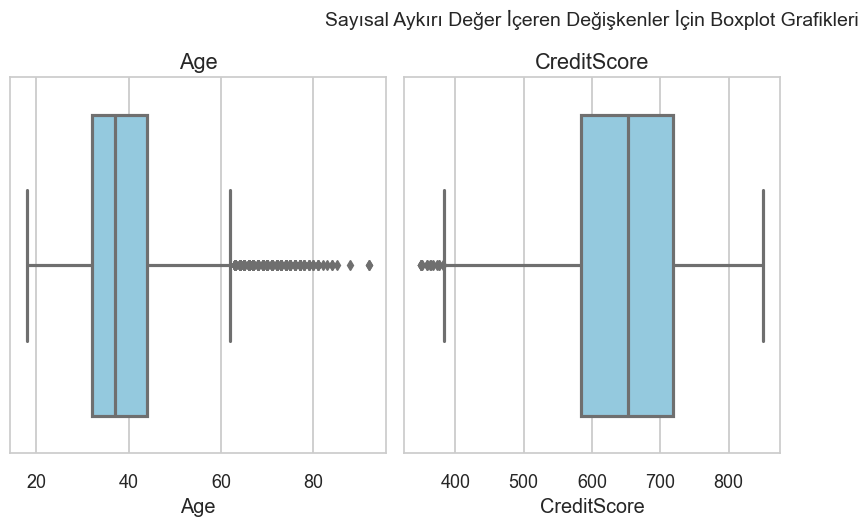

In [62]:
# Sadece sayısal değişkenleri seçme
sayisal_degiskenler = ['Age', 'CreditScore']

# Grafik boyutlarını ayarlama
plt.figure(figsize=(12, 5))

# Her değişken için ayrı boxplot çizme
for i, degisken in enumerate(sayisal_degiskenler, 1):
    plt.subplot(1, 3, i)  # 1 satır, 3 sütun düzeni
    sns.boxplot(x=df_2[degisken], color='skyblue')
    plt.title(degisken)

# Grafik düzenini sıkılaştırma
plt.tight_layout()
plt.suptitle("Sayısal Aykırı Değer İçeren Değişkenler İçin Boxplot Grafikleri", fontsize=14, y=1.05)
plt.show()

C:\Users\mehdi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


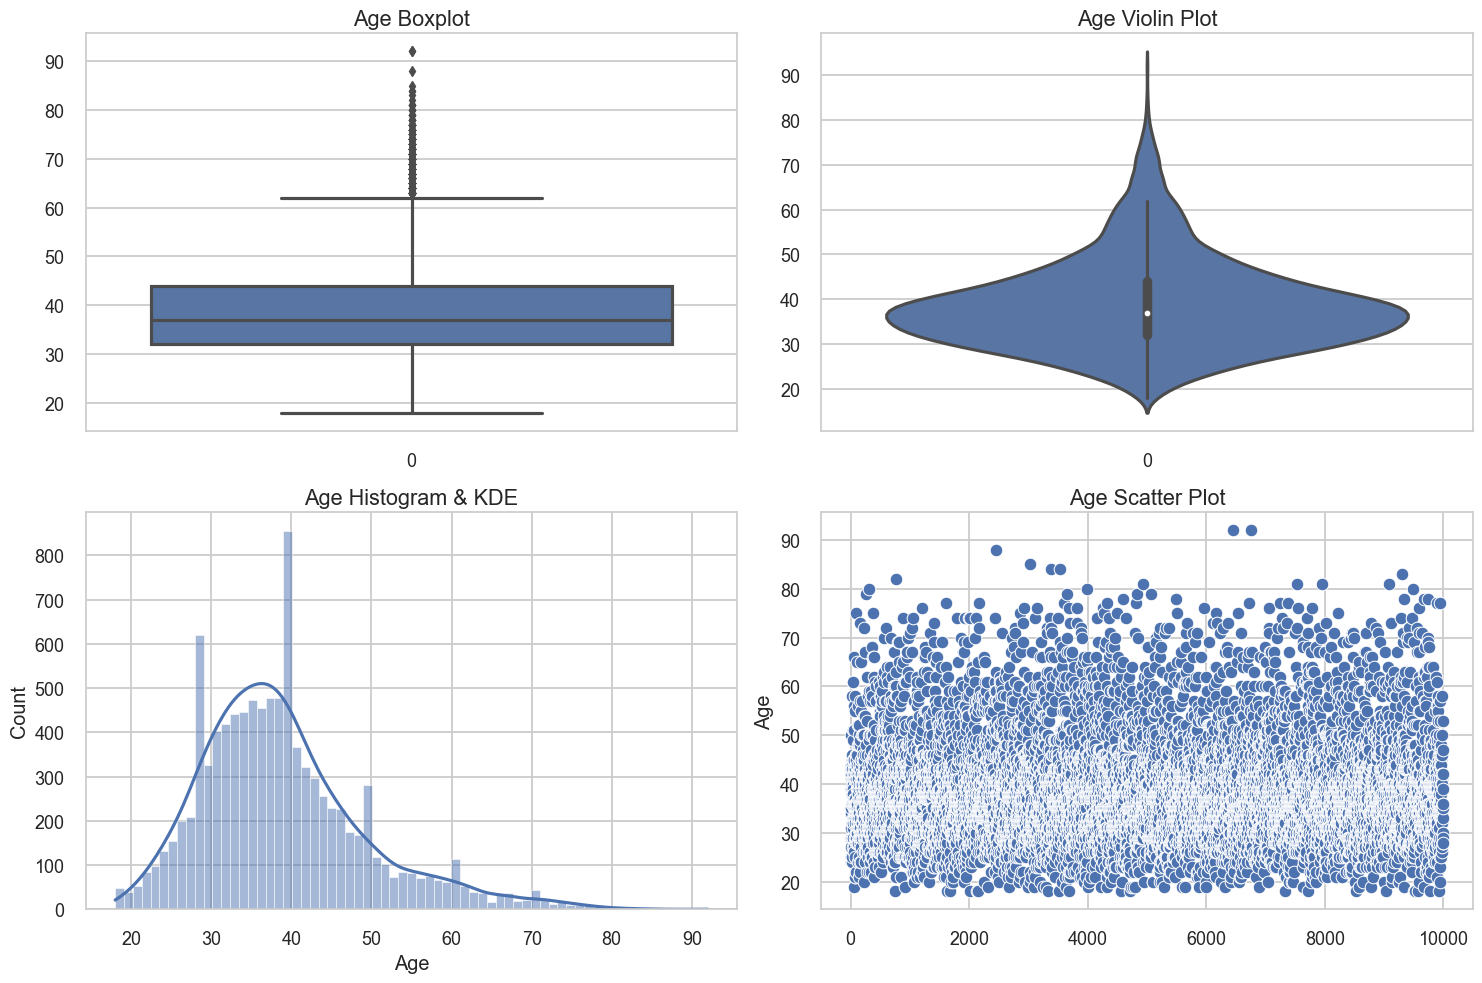

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.boxplot(df_2['Age'], ax=axes[0, 0])
axes[0, 0].set_title("Age Boxplot")
sns.violinplot(df_2['Age'], ax=axes[0, 1])
axes[0, 1].set_title("Age Violin Plot")
sns.histplot(df_2['Age'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Age Histogram & KDE")
sns.scatterplot(x=df_2.index, y=df_2['Age'], ax=axes[1, 1])
axes[1, 1].set_title("Age Scatter Plot")
plt.tight_layout()
plt.show()

C:\Users\mehdi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


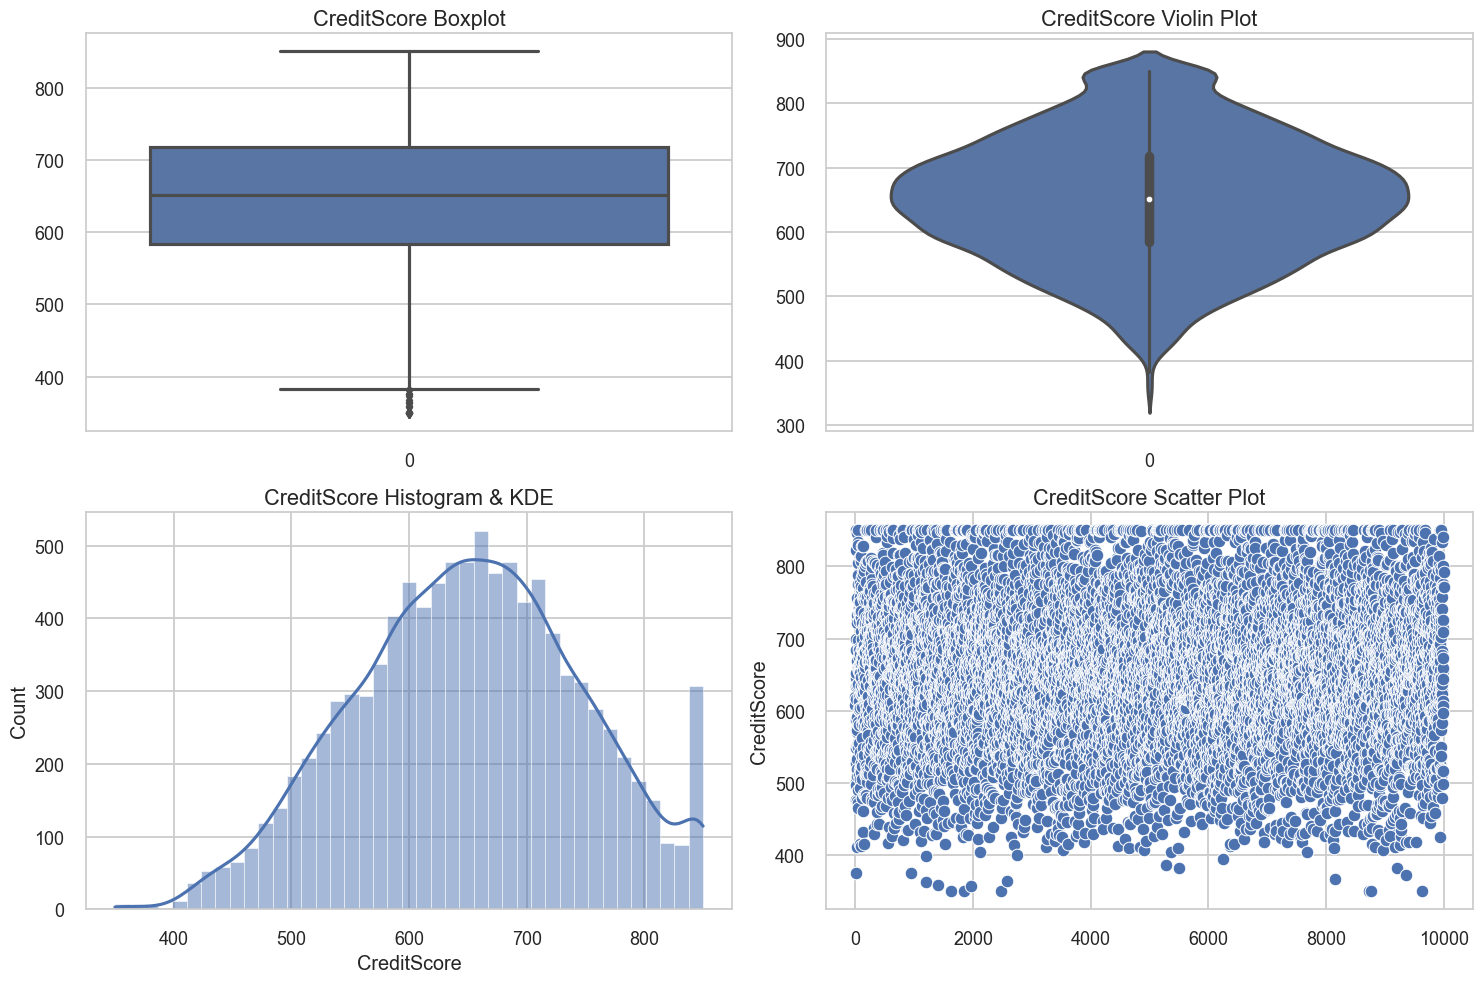

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.boxplot(df_2['CreditScore'], ax=axes[0, 0])
axes[0, 0].set_title("CreditScore Boxplot")
sns.violinplot(df_2['CreditScore'], ax=axes[0, 1])
axes[0, 1].set_title("CreditScore Violin Plot")
sns.histplot(df_2['CreditScore'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("CreditScore Histogram & KDE")
sns.scatterplot(x=df_2.index, y=df_2['CreditScore'], ax=axes[1, 1])
axes[1, 1].set_title("CreditScore Scatter Plot")
plt.tight_layout()
plt.show()

#### Age ve CreditScore Değişkenlerinin Model Üzerindeki Etkisinin Karşılaştırılması

In [65]:
df_22 = df.copy() 

In [66]:
df_22 = df_22.drop(columns=['Tenure','HasCrCard','Complain'])

In [67]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb

def evaluate_feature_removal(df, target_col, features_to_remove):
    """
    Belirtilen değişkenleri sırasıyla veri setinden çıkararak modeli eğiten ve doğruluk oranlarını karşılaştıran fonksiyon.
    
    Parametreler:
    df: Veri çerçevesi (DataFrame)
    target_col: Hedef değişkenin ismi (str)
    features_to_remove: Test edilecek değişkenlerin listesi (list)
    
    Dönüş:
    En iyi doğruluk ve değişken kombinasyonu
    """
    
    # Kategorik değişkenleri sayısal verilere dönüştür
    df_encoded = pd.get_dummies(df, drop_first=True)  # One-Hot Encoding uygula
    
    X = df_encoded.drop(columns=[target_col])
    y = df_encoded[target_col]
    
    results = []
    
    def train_and_evaluate(X, y, removed_features):
        """Belirtilen değişkenleri çıkararak modeli eğitir ve doğruluğu döndürür."""
        X_reduced = X.drop(columns=removed_features, errors='ignore')
        X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
        model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        return accuracy_score(y_test, y_pred)

    # Tüm değişkenlerle doğruluk
    accuracy_base = train_and_evaluate(X, y, [])
    results.append(("Tüm değişkenler", accuracy_base))

    # Hiçbir değişken çıkarılmadığı durumda doğruluk
    accuracy_no_removal = train_and_evaluate(X, y, [])
    results.append(("Hiçbir değişken çıkarılmadı", accuracy_no_removal))

    # Tek tek değişkenleri çıkararak doğruluğu hesapla
    for feature in features_to_remove:
        accuracy = train_and_evaluate(X, y, [feature])
        results.append((f"Sadece '{feature}' çıkarıldı", accuracy))

    # Tüm değişkenleri aynı anda çıkararak doğruluğu hesapla
    accuracy_both = train_and_evaluate(X, y, features_to_remove)
    results.append((f"{features_to_remove} çıkarıldı", accuracy_both))

    # En yüksek doğruluğu belirle
    best_case = max(results, key=lambda x: x[1])

    print("\nSonuçlar:")
    for scenario, acc in results:
        print(f"{scenario}: {acc:.4f}")
    
    print("\nEn yüksek doğruluk oranı:", best_case[1])
    print("En iyi değişken kombinasyonu:", best_case[0])

    return results


In [68]:
evaluate_feature_removal(df_22,target_col="Exited", features_to_remove=["Age", "CreditScore"])


Sonuçlar:
Tüm değişkenler: 0.8650
Hiçbir değişken çıkarılmadı: 0.8650
Sadece 'Age' çıkarıldı: 0.8245
Sadece 'CreditScore' çıkarıldı: 0.8530
['Age', 'CreditScore'] çıkarıldı: 0.8160

En yüksek doğruluk oranı: 0.865
En iyi değişken kombinasyonu: Tüm değişkenler


[('Tüm değişkenler', 0.865),
 ('Hiçbir değişken çıkarılmadı', 0.865),
 ("Sadece 'Age' çıkarıldı", 0.8245),
 ("Sadece 'CreditScore' çıkarıldı", 0.853),
 ("['Age', 'CreditScore'] çıkarıldı", 0.816)]

#### age ve creditScore değişkenlerine dönüşüm

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
import xgboost as xgb

def evaluate_transformation(df, target_col, feature_col):
    # Modeli eğitmek ve doğruluğu hesaplamak için yardımcı fonksiyon
    def train_and_evaluate(X, y):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        return accuracy_score(y_test, y_pred)

    # Kategorik değişkenler için işlem yapılacak sütunları belirle
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    # Kategorik sütunları one-hot encode yapacak bir transformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(), categorical_cols)
        ],
        remainder='passthrough'  # Kategorik olmayan sütunları olduğu gibi bırak
    )
    
    # Hedef değişkeni ve bağımsız değişkeni ayırma
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # 1. Dönüşüm uygulanmadan önce doğruluğu hesapla
    X_no_transform = preprocessor.fit_transform(X)
    accuracy_no_transform = train_and_evaluate(X_no_transform, y)
    
    # 2. Z-skor dönüşümü
    X_zscore = X.copy()
    scaler = StandardScaler()
    X_zscore[feature_col] = scaler.fit_transform(X_zscore[[feature_col]])
    
    # 3. Log dönüşümü
    X_log = X.copy()
    X_log[feature_col] = np.log(X_log[feature_col] + 1)  # +1 ekleniyor çünkü negatif ya da sıfır değerler olabilir

    # Kolon dönüşümü (kategorik verileri encode et)
    X_zscore = preprocessor.fit_transform(X_zscore)
    X_log = preprocessor.transform(X_log)

    # Doğruluk oranlarını hesapla
    accuracy_zscore = train_and_evaluate(X_zscore, y)
    accuracy_log = train_and_evaluate(X_log, y)

    # Sonuçları yazdır
    print(f"Uygulama yapılmadan önce doğruluk: {accuracy_no_transform:.4f}")
    print(f"Z-skor dönüşümü doğruluğu: {accuracy_zscore:.4f}")
    print(f"Log dönüşümü doğruluğu: {accuracy_log:.4f}")

    if accuracy_no_transform == accuracy_zscore == accuracy_log:
        print("Hiçbir dönüşüm doğruluk oranında değişiklik yaratmadı. Hepsi eşit!")
    elif accuracy_zscore > accuracy_log and accuracy_zscore > accuracy_no_transform:
        print(f"Z-skor dönüşümü en yüksek doğruluğu sağladı: {accuracy_zscore:.4f}")
    elif accuracy_log > accuracy_zscore and accuracy_log > accuracy_no_transform:
        print(f"Log dönüşümü en yüksek doğruluğu sağladı: {accuracy_log:.4f}")
    elif accuracy_no_transform > accuracy_zscore and accuracy_no_transform > accuracy_log:
        print(f"Uygulama yapılmadan önceki doğruluk en yüksek: {accuracy_no_transform:.4f}")
    else:
        print("İki dönüşüm arasında eşitlik mevcut.")
        
    return accuracy_no_transform, accuracy_zscore, accuracy_log

In [70]:
evaluate_transformation(df_22, target_col='Exited', feature_col='Age')


Uygulama yapılmadan önce doğruluk: 0.8675
Z-skor dönüşümü doğruluğu: 0.8675
Log dönüşümü doğruluğu: 0.8675
Hiçbir dönüşüm doğruluk oranında değişiklik yaratmadı. Hepsi eşit!


(0.8675, 0.8675, 0.8675)

In [71]:
evaluate_transformation(df_22, target_col='Exited', feature_col='CreditScore')


Uygulama yapılmadan önce doğruluk: 0.8675
Z-skor dönüşümü doğruluğu: 0.8675
Log dönüşümü doğruluğu: 0.8675
Hiçbir dönüşüm doğruluk oranında değişiklik yaratmadı. Hepsi eşit!


(0.8675, 0.8675, 0.8675)

# 🔧 Yardımcı Fonksiyonlar (Helper Functions)

In [72]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, r2_score, f1_score
import xgboost as xgb

def train_and_evaluate_models(df, target_column):
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    models = {
        "Random Forest": RandomForestClassifier() if y.nunique() < 10 else RandomForestRegressor(),
        "Logistic Regression": LogisticRegression() if y.nunique() < 10 else None,
        "Artificial Neural Network": MLPClassifier() if y.nunique() < 10 else MLPRegressor(),
        "SVM": SVC() if y.nunique() < 10 else SVR(),
        "Gradient Boosting": GradientBoostingClassifier() if y.nunique() < 10 else GradientBoostingRegressor(),
        "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss') if y.nunique() < 10 else xgb.XGBRegressor(),
        "Decision Tree": DecisionTreeClassifier() if y.nunique() < 10 else DecisionTreeRegressor(),
        "KNN": KNeighborsClassifier() if y.nunique() < 10 else KNeighborsRegressor()
    }
    
    results = []
    
    for name, model in models.items():
        if model is None:
            continue
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)
        
        if y.nunique() < 10:
            train_score = accuracy_score(y_train, y_train_pred)
            test_score = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted')
        else:
            train_score = r2_score(y_train, y_train_pred)
            test_score = r2_score(y_test, y_pred)
            f1 = None  # F1 skoru sadece sınıflandırma için geçerlidir
        
        results.append({
            "Model": name,
            "Train Score": train_score,
            "Test Score": test_score,
            "F1 Score": f1
        })
    
    results_df = pd.DataFrame(results)
    print(results_df)
    
    return results_df


In [73]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

def encode_categorical_columns(df):
    le = LabelEncoder()
    categorical_cols = df.select_dtypes(include=['object']).columns  # Sayısal olmayan sütunları seç
    
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col])  # Label encoding işlemi
    
    return df

# Feature Engineering

### Age değişkeninin kategorik hale getirilmesi

In [74]:
data = df.copy()

In [75]:
data = data.drop(columns=['Tenure','HasCrCard','Complain'])

In [76]:
data.Age.value_counts()

Age
37    478
38    477
35    474
36    456
34    447
     ... 
92      2
82      1
88      1
85      1
83      1
Name: count, Length: 70, dtype: int64

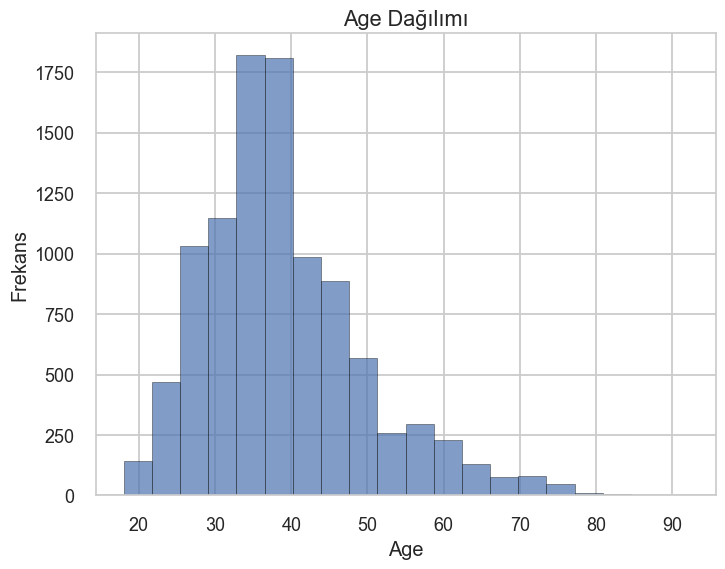

In [77]:
import matplotlib.pyplot as plt

# Age değişkeninin dağılımını görmek için histogram
def plot_age_distribution(df, age_col='Age'):
    plt.figure(figsize=(8, 6))
    plt.hist(df[age_col], bins=20, edgecolor='black', alpha=0.7)
    plt.title(f'{age_col} Dağılımı')
    plt.xlabel(age_col)
    plt.ylabel('Frekans')
    plt.grid(True)
    plt.show()

# Örnek kullanım
plot_age_distribution(data, 'Age')


In [78]:
data_1 = data.copy()

In [79]:
# Yaş grupları için sınırlar ve etiketler tanımlayalım
bins = [17, 29, 49, 64, float('inf')] # Sınırlar (17 dahil değil, 29 dahil)
labels = [0, 1, 2, 3] # Atanacak sayısal etiketler

# 'Age' sütununu kullanarak yeni bir 'Age_Group_Label' sütunu oluşturalım
data['Age_Group_Label'] = pd.cut(data['Age'], bins=bins, labels=labels, right=True)

In [80]:
data = data.drop(columns=['Age'])

In [81]:
data.head()

,CreditScore,Geography,Gender,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited,Satisfaction_Score,Card_Type,Point_Earned,Age_Group_Label
0,619,France,Female,0.00,1,1,101348.88,1,2,DIAMOND,464,1
1,608,Spain,Female,83807.86,1,1,112542.58,0,3,DIAMOND,456,1
2,502,France,Female,159660.80,3,0,113931.57,1,3,DIAMOND,377,1
3,699,France,Female,0.00,2,0,93826.63,0,5,GOLD,350,1
4,850,Spain,Female,125510.82,1,1,79084.10,0,5,GOLD,425,1


In [82]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

def encode_categorical_columns(df):
    le = LabelEncoder()
    categorical_cols = df.select_dtypes(include=['object']).columns  # Sayısal olmayan sütunları seç
    
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col])  # Label encoding işlemi
    
    return df

In [83]:
encode_categorical_columns(data)

,CreditScore,Geography,Gender,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited,Satisfaction_Score,Card_Type,Point_Earned,Age_Group_Label
0,619,0,0,0.00,1,1,101348.88,1,2,0,464,1
1,608,2,0,83807.86,1,1,112542.58,0,3,0,456,1
2,502,0,0,159660.80,3,0,113931.57,1,3,0,377,1
3,699,0,0,0.00,2,0,93826.63,0,5,1,350,1
4,850,2,0,125510.82,1,1,79084.10,0,5,1,425,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,0.00,2,0,96270.64,0,1,0,300,1
9996,516,0,1,57369.61,1,1,101699.77,0,5,2,771,1
9997,709,0,0,0.00,1,1,42085.58,1,3,3,564,1
9998,772,1,1,75075.31,2,0,92888.52,1,2,1,339,1


In [84]:
# Eğer 'Age_Group_Label' kategorikse, sayısal değerlere dönüştür
data['Age_Group_Label'] = data['Age_Group_Label'].cat.codes


In [85]:
encode_categorical_columns(data_1)

,CreditScore,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited,Satisfaction_Score,Card_Type,Point_Earned
0,619,0,0,42,0.00,1,1,101348.88,1,2,0,464
1,608,2,0,41,83807.86,1,1,112542.58,0,3,0,456
2,502,0,0,42,159660.80,3,0,113931.57,1,3,0,377
3,699,0,0,39,0.00,2,0,93826.63,0,5,1,350
4,850,2,0,43,125510.82,1,1,79084.10,0,5,1,425
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,0.00,2,0,96270.64,0,1,0,300
9996,516,0,1,35,57369.61,1,1,101699.77,0,5,2,771
9997,709,0,0,36,0.00,1,1,42085.58,1,3,3,564
9998,772,1,1,42,75075.31,2,0,92888.52,1,2,1,339


In [86]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb

def evaluate_model_accuracy(df, target_col='Exited'):
    # Veriyi ayır
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # Modeli eğit ve doğruluğu hesapla
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Doğruluk oranını döndür
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model doğruluğu: {accuracy:.4f}")

In [87]:
evaluate_model_accuracy(data_1, target_col='Exited')

Model doğruluğu: 0.8630


In [88]:
evaluate_model_accuracy(data, target_col='Exited')

Model doğruluğu: 0.8360


### LoyaltySegment

In [89]:
features_ = ['Tenure', 'NumOfProducts', 'IsActiveMember', 'Complain', 'Satisfaction_Score']

for col in features_:
    print(f"\n=== {col} için 'Exited' = 0 ===")
    print(df[df['Exited'] == 0][col].describe())
    
    print(f"\n=== {col} için 'Exited' = 1 ===")
    print(df[df['Exited'] == 1][col].describe())
    print("-" * 50)



=== Tenure için 'Exited' = 0 ===
count    7962.000000
mean        5.032781
std         2.880496
min         0.000000
25%         3.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: Tenure, dtype: float64

=== Tenure için 'Exited' = 1 ===
count    2038.000000
mean        4.934740
std         2.936768
min         0.000000
25%         2.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: Tenure, dtype: float64
--------------------------------------------------

=== NumOfProducts için 'Exited' = 0 ===
count    7962.000000
mean        1.544210
std         0.509542
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: NumOfProducts, dtype: float64

=== NumOfProducts için 'Exited' = 1 ===
count    2038.000000
mean        1.475466
std         0.801408
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: NumOfProducts, dtype: float

In [90]:
df21= df.copy()

In [91]:
def assign_loyalty_segment(row):
    score = 0

    # Tenure (Şirketteki süre)
    if row['Tenure'] >= 6:  # Daha uzun süreli müşteriler daha sadık olabilir.
        score += 2
    elif row['Tenure'] >= 3:
        score += 1

    # NumOfProducts (Ürün sayısı)
    if row['NumOfProducts'] >= 2:
        score += 2
    elif row['NumOfProducts'] == 1:
        score += 1

    # IsActiveMember (Aktif Üye Durumu)
    if row['IsActiveMember'] == 1:
        score += 2

    # Memnuniyet Skoru (Satisfaction_Score)
    if row['Satisfaction_Score'] >= 4:  # Yüksek memnuniyet daha fazla sadakat sağlar
        score += 2
    elif row['Satisfaction_Score'] == 3:
        score += 1

    # Şikayet Durumu (Complain)
    if row['Complain'] == 1:
        score -= 2  # Şikayet edenleri daha düşük sadakatle sınıflandır

    # Segment Atama
    if score >= 6:
        return 'High Loyalty'
    elif score >= 3:
        return 'Medium Loyalty'
    else:
        return 'Low Loyalty'


In [92]:
df21['LoyaltySegment'] = df21.apply(assign_loyalty_segment, axis=1)


In [93]:
encode_categorical_columns(df21)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned,LoyaltySegment
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456,1
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377,2
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350,2
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0,0,1,0,300,2
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0,0,5,2,771,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1,1,3,3,564,2
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1,1,2,1,339,1


In [94]:
df21[['LoyaltySegment', 'Complain']].corr()


,LoyaltySegment,Complain
LoyaltySegment,1.000000,0.082978
Complain,0.082978,1.000000


In [95]:
df21 = df21.drop(columns=['Complain'])

In [96]:
evaluate_model_accuracy(df21, target_col='Exited')

Model doğruluğu: 0.9365


In [97]:
train_and_evaluate_models(df21,'Exited')

C:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


                       Model  Train Score  Test Score  F1 Score
0              Random Forest     1.000000      0.9240  0.920322
1        Logistic Regression     0.804375      0.8085  0.764518
2  Artificial Neural Network     0.953375      0.9220  0.921462
3                        SVM     0.930875      0.9170  0.912088
4          Gradient Boosting     0.932250      0.9300  0.926973
5                    XGBoost     0.997875      0.9365  0.935010
6              Decision Tree     1.000000      0.9040  0.904000
7                        KNN     0.906875      0.8690  0.856254


,Model,Train Score,Test Score,F1 Score
0,Random Forest,1.000000,0.9240,0.920322
1,Logistic Regression,0.804375,0.8085,0.764518
2,Artificial Neural Network,0.953375,0.9220,0.921462
3,SVM,0.930875,0.9170,0.912088
4,Gradient Boosting,0.932250,0.9300,0.926973
5,XGBoost,0.997875,0.9365,0.935010
6,Decision Tree,1.000000,0.9040,0.904000
7,KNN,0.906875,0.8690,0.856254


Oluşturulan yeni değişken, model doğruluğunu anlamlı şekilde artırmıştır

### RiskSegment

In [98]:
df2 = df.copy()
df2['LoyaltySegment'] = df2.apply(assign_loyalty_segment, axis=1)
encode_categorical_columns(df2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned,LoyaltySegment
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456,1
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377,2
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350,2
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0,0,1,0,300,2
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0,0,5,2,771,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1,1,3,3,564,2
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1,1,2,1,339,1


In [99]:
features = ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'HasCrCard', 'Complain', 'Satisfaction_Score']

for col in features:
    print(f"\n=== {col} için 'Exited' = 0 ===")
    print(df2[df2['Exited'] == 0][col].describe())
    
    print(f"\n=== {col} için 'Exited' = 1 ===")
    print(df2[df2['Exited'] == 1][col].describe())
    print("-" * 50)



=== CreditScore için 'Exited' = 0 ===
count    7962.000000
mean      651.837855
std        95.650047
min       405.000000
25%       585.000000
50%       653.000000
75%       718.000000
max       850.000000
Name: CreditScore, dtype: float64

=== CreditScore için 'Exited' = 1 ===
count    2038.000000
mean      645.414622
std       100.337351
min       350.000000
25%       578.000000
50%       646.000000
75%       716.000000
max       850.000000
Name: CreditScore, dtype: float64
--------------------------------------------------

=== Age için 'Exited' = 0 ===
count    7962.000000
mean       37.408063
std        10.125957
min        18.000000
25%        31.000000
50%        36.000000
75%        41.000000
max        92.000000
Name: Age, dtype: float64

=== Age için 'Exited' = 1 ===
count    2038.000000
mean       44.835623
std         9.759754
min        18.000000
25%        38.000000
50%        45.000000
75%        51.000000
max        84.000000
Name: Age, dtype: float64
-----------------

In [100]:
df12 = df2.copy()

In [101]:
def assign_risk_segment(row):
    score = 0

    # CreditScore
    if row['CreditScore'] < 600:
        score += 2
    elif row['CreditScore'] < 650:
        score += 1

    # Age
    if row['Age'] > 50:
        score += 2
    elif row['Age'] > 40:
        score += 1

    # Balance
    if row['Balance'] < 30000:
        score += 2
    elif row['Balance'] < 100000:
        score += 1

    # Ürün sayısı
    if row['NumOfProducts'] == 1:
        score += 1
    elif row['NumOfProducts'] == 0:
        score += 2

    # Kredi kartı
    if row['HasCrCard'] == 0:
        score += 1

    # Şikayet ve memnuniyet
    if row['Complain'] == 1:
        score += 2
    elif row['Satisfaction_Score'] <= 2:
        score += 2
    elif row['Satisfaction_Score'] == 3:
        score += 1

    # Segment atama
    if score >= 7:
        return 'High Risk'
    elif score >= 4:
        return 'Medium Risk'
    else:
        return 'Low Risk'


In [102]:
df12['RiskSegment'] = df12.apply(assign_risk_segment, axis=1)

In [103]:
encode_categorical_columns(df12)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned,LoyaltySegment,RiskSegment
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464,1,0
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456,1,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377,2,2
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350,2,1
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0,0,1,0,300,2,2
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0,0,5,2,771,0,2
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1,1,3,3,564,2,2
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1,1,2,1,339,1,2


In [104]:
df12[['RiskSegment', 'Complain','Age', 'CreditScore','Balance', 'NumOfProducts','HasCrCard','Satisfaction_Score','LoyaltySegment','Exited']].corr()

,RiskSegment,Complain,Age,CreditScore,Balance,NumOfProducts,HasCrCard,Satisfaction_Score,LoyaltySegment,Exited
RiskSegment,1.000000,-0.061808,-0.058768,-0.017550,-0.021045,0.033091,0.007380,-0.116174,0.049631,-0.061271
Complain,-0.061808,1.000000,0.283530,-0.027048,0.119124,-0.046357,-0.007095,-0.004799,0.082978,0.995693
Age,-0.058768,0.283530,1.000000,-0.003965,0.028308,-0.030680,-0.011721,-0.000876,-0.036060,0.285296
CreditScore,-0.017550,-0.027048,-0.003965,1.000000,0.006268,0.012238,-0.005458,-0.012599,0.000872,-0.026771
Balance,-0.021045,0.119124,0.028308,0.006268,1.000000,-0.304180,-0.014858,-0.002588,0.109290,0.118577
NumOfProducts,0.033091,-0.046357,-0.030680,0.012238,-0.304180,1.000000,0.003183,-0.011394,-0.162014,-0.047611
HasCrCard,0.007380,-0.007095,-0.011721,-0.005458,-0.014858,0.003183,1.000000,-0.000212,-0.013461,-0.006976
Satisfaction_Score,-0.116174,-0.004799,-0.000876,-0.012599,-0.002588,-0.011394,-0.000212,1.000000,-0.259119,-0.005849
LoyaltySegment,0.049631,0.082978,-0.036060,0.000872,0.109290,-0.162014,-0.013461,-0.259119,1.000000,0.082920
Exited,-0.061271,0.995693,0.285296,-0.026771,0.118577,-0.047611,-0.006976,-0.005849,0.082920,1.000000


In [105]:
df12 = df12.drop(columns=['Complain'])

In [106]:
evaluate_model_accuracy(df12, target_col='Exited')

Model doğruluğu: 0.9520


In [107]:
train_and_evaluate_models(df12,'Exited')

C:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


                       Model  Train Score  Test Score  F1 Score
0              Random Forest     1.000000      0.9340  0.931558
1        Logistic Regression     0.806125      0.8105  0.766455
2  Artificial Neural Network     0.961375      0.9310  0.930593
3                        SVM     0.940375      0.9290  0.925748
4          Gradient Boosting     0.940875      0.9415  0.939927
5                    XGBoost     0.999625      0.9520  0.951472
6              Decision Tree     1.000000      0.9140  0.913579
7                        KNN     0.915375      0.8865  0.878568


,Model,Train Score,Test Score,F1 Score
0,Random Forest,1.000000,0.9340,0.931558
1,Logistic Regression,0.806125,0.8105,0.766455
2,Artificial Neural Network,0.961375,0.9310,0.930593
3,SVM,0.940375,0.9290,0.925748
4,Gradient Boosting,0.940875,0.9415,0.939927
5,XGBoost,0.999625,0.9520,0.951472
6,Decision Tree,1.000000,0.9140,0.913579
7,KNN,0.915375,0.8865,0.878568


### assign_engagement_level

In [108]:
features_2 = ['Balance', 'NumOfProducts', 'HasCrCard', 'Complain', 'IsActiveMember']

for col in features_2:
    print(f"\n=== {col} için 'Exited' = 0 ===")
    print(df2[df2['Exited'] == 0][col].describe())
    
    print(f"\n=== {col} için 'Exited' = 1 ===")
    print(df2[df2['Exited'] == 1][col].describe())
    print("-" * 50)



=== Balance için 'Exited' = 0 ===
count      7962.000000
mean      72742.750663
std       62851.577108
min           0.000000
25%           0.000000
50%       92063.060000
75%      126419.330000
max      221532.800000
Name: Balance, dtype: float64

=== Balance için 'Exited' = 1 ===
count      2038.000000
mean      91109.476006
std       58346.483197
min           0.000000
25%       38591.222500
50%      109344.230000
75%      131423.637500
max      250898.090000
Name: Balance, dtype: float64
--------------------------------------------------

=== NumOfProducts için 'Exited' = 0 ===
count    7962.000000
mean        1.544210
std         0.509542
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: NumOfProducts, dtype: float64

=== NumOfProducts için 'Exited' = 1 ===
count    2038.000000
mean        1.475466
std         0.801408
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.0000

In [109]:
df14 = df2.copy()

In [110]:
def assign_engagement_level(row):
    score = 0

    # Aktif Üye Kontrolü
    if row['IsActiveMember'] == 1:
        score += 2

    # Ürün Sayısı
    if row['NumOfProducts'] >= 2:
        score += 2
    elif row['NumOfProducts'] == 1:
        score += 1
    elif row['NumOfProducts'] == 0:
        score += 0  # 0 ürün, düşük etkileşim

    # Kredi Kartı Var mı?
    if row['HasCrCard'] == 1:
        score += 1

    # Bakiye
    if row['Balance'] > 100000:
        score += 2
    elif row['Balance'] > 50000:
        score += 1
    elif row['Balance'] > 10000:
        score += 0  # Düşük bakiye, düşük etkileşim

    # Şikayet
    if row['Complain'] == 1:
        score -= 1  # Şikayet, etkileşimi düşürür

    # Etkileşim seviyesini belirle
    if score >= 6:
        return 'High Engagement'
    elif score >= 3:
        return 'Medium Engagement'
    else:
        return 'Low Engagement'


In [111]:
df14['EngagementLevel'] = df14.apply(assign_engagement_level, axis=1)

In [112]:
df14['RiskSegment'] = df14.apply(assign_risk_segment, axis=1)

In [113]:
encode_categorical_columns(df14)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned,LoyaltySegment,EngagementLevel,RiskSegment
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464,1,2,0
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456,1,2,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377,2,2,2
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350,2,1,1
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0,0,1,0,300,2,2,2
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0,0,5,2,771,0,2,2
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1,1,3,3,564,2,1,2
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1,1,2,1,339,1,2,2


In [114]:
df14[['EngagementLevel','RiskSegment', 'Complain','IsActiveMember', 'Balance','HasCrCard', 'NumOfProducts','LoyaltySegment','Exited']].corr()

,EngagementLevel,RiskSegment,Complain,IsActiveMember,Balance,HasCrCard,NumOfProducts,LoyaltySegment,Exited
EngagementLevel,1.000000,0.124949,0.047901,-0.287025,-0.259500,-0.069497,0.026286,0.122470,0.047935
RiskSegment,0.124949,1.000000,-0.061808,0.001931,-0.021045,0.007380,0.033091,0.049631,-0.061271
Complain,0.047901,-0.061808,1.000000,-0.154741,0.119124,-0.007095,-0.046357,0.082978,0.995693
IsActiveMember,-0.287025,0.001931,-0.154741,1.000000,-0.010084,-0.011866,0.009612,-0.310712,-0.156356
Balance,-0.259500,-0.021045,0.119124,-0.010084,1.000000,-0.014858,-0.304180,0.109290,0.118577
HasCrCard,-0.069497,0.007380,-0.007095,-0.011866,-0.014858,1.000000,0.003183,-0.013461,-0.006976
NumOfProducts,0.026286,0.033091,-0.046357,0.009612,-0.304180,0.003183,1.000000,-0.162014,-0.047611
LoyaltySegment,0.122470,0.049631,0.082978,-0.310712,0.109290,-0.013461,-0.162014,1.000000,0.082920
Exited,0.047935,-0.061271,0.995693,-0.156356,0.118577,-0.006976,-0.047611,0.082920,1.000000


In [115]:
df14 = df14.drop(columns=['Complain'])

In [116]:
evaluate_model_accuracy(df14, target_col='Exited')

Model doğruluğu: 0.9640


In [117]:
train_and_evaluate_models(df14,'Exited')

C:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


                       Model  Train Score  Test Score  F1 Score
0              Random Forest     1.000000      0.9500  0.948855
1        Logistic Regression     0.805000      0.8105  0.766455
2  Artificial Neural Network     0.973500      0.9480  0.947641
3                        SVM     0.950625      0.9445  0.942548
4          Gradient Boosting     0.946500      0.9495  0.948372
5                    XGBoost     0.999750      0.9640  0.963566
6              Decision Tree     1.000000      0.9225  0.922537
7                        KNN     0.925375      0.8990  0.893439


,Model,Train Score,Test Score,F1 Score
0,Random Forest,1.000000,0.9500,0.948855
1,Logistic Regression,0.805000,0.8105,0.766455
2,Artificial Neural Network,0.973500,0.9480,0.947641
3,SVM,0.950625,0.9445,0.942548
4,Gradient Boosting,0.946500,0.9495,0.948372
5,XGBoost,0.999750,0.9640,0.963566
6,Decision Tree,1.000000,0.9225,0.922537
7,KNN,0.925375,0.8990,0.893439


### oluşturulan değişkenlerin görselleştirilmesi

#### LoyaltySegment Dağılımı

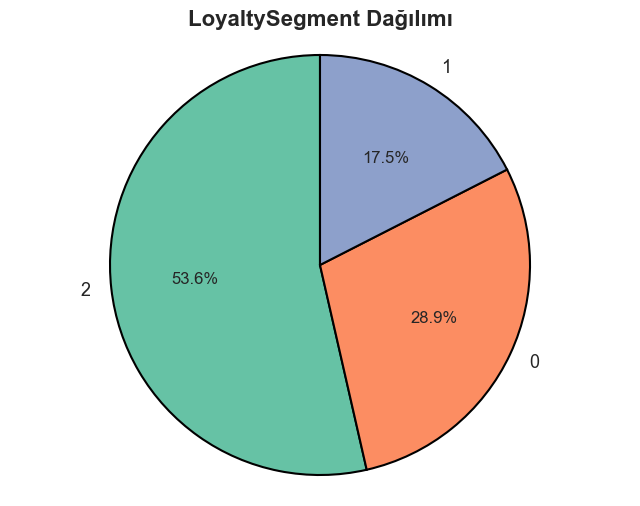

In [118]:
# Coğrafya verisinin frekanslarını al
LoyaltySegment = df14["LoyaltySegment"].value_counts()

# Pasta grafiği çiz
plt.figure(figsize=(8, 6))
plt.pie(LoyaltySegment, labels=LoyaltySegment.index, autopct="%1.1f%%", colors=plt.cm.Set2.colors, startangle=90, 
        wedgeprops={"edgecolor": "Black", "linewidth": 1.5, "linestyle": "solid"})
plt.title("LoyaltySegment Dağılımı", fontsize=16, weight="bold")
plt.axis("equal")  
plt.show()

In [119]:
df14["LoyaltySegment"].value_counts()

LoyaltySegment
2    5357
0    2894
1    1749
Name: count, dtype: int64

#### RiskSegment Dağılımı

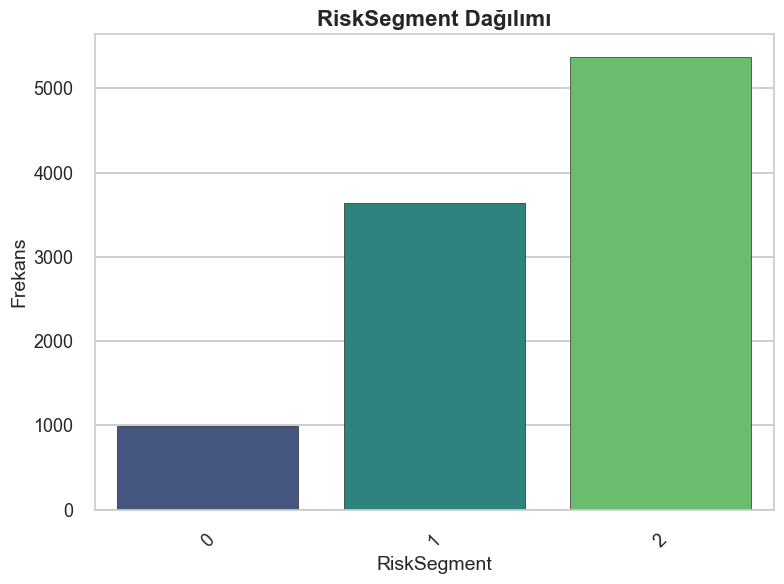

In [120]:
# Tenure değişkeninin frekanslarını al
plt.figure(figsize=(8, 6))
sns.countplot(x="RiskSegment", data=df14, palette="viridis", edgecolor="black")

# Başlık ve etiketleri ekle
plt.title("RiskSegment Dağılımı", fontsize=16, weight="bold")
plt.xlabel("RiskSegment", fontsize=14)
plt.ylabel("Frekans", fontsize=14)

plt.xticks(rotation=45)

# Görseli göster
plt.tight_layout()
plt.show()

In [121]:
df14["RiskSegment"].value_counts()

RiskSegment
2    5369
1    3637
0     994
Name: count, dtype: int64

#### assign_engagement_level Dağılımı

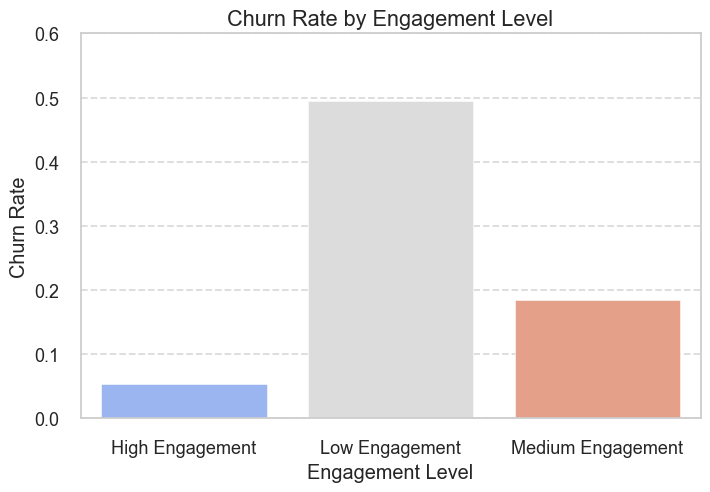

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

engagement_churn = df14.groupby('EngagementLevel')['Exited'].mean().reset_index()
engagement_churn['EngagementLabel'] = engagement_churn['EngagementLevel'].map({
    0: 'High Engagement',
    1: 'Low Engagement',
    2: 'Medium Engagement'
})

plt.figure(figsize=(8, 5))
sns.barplot(data=engagement_churn, x='EngagementLabel', y='Exited', palette='coolwarm')
plt.title('Churn Rate by Engagement Level')
plt.ylabel('Churn Rate')
plt.xlabel('Engagement Level')
plt.ylim(0, 0.6)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [123]:
df14.groupby('EngagementLevel')['Exited'].mean()


EngagementLevel
0    0.053879
1    0.495314
2    0.185141
Name: Exited, dtype: float64

# Statistical analysis

### Hedef değişkenin Sınıf dengesi

In [124]:
df14.describe()  # Sayısal değişkenler için
df14['Exited'].value_counts(normalize=True)  # Sınıf dengesine bak


Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

### Sayısal Değişkenler ile Exited Arasındaki İlişki

In [125]:
from scipy.stats import ttest_ind

# Sayısal değişkenler listesi
numerical_columns = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Point_Earned']

# Sonuçları saklayacağımız bir liste
results = []

# Her bir sayısal değişken için t-testi uygulama
for col in numerical_columns:
    group0 = df14[df14['Exited'] == 0][col]
    group1 = df14[df14['Exited'] == 1][col]
    
    # t-testi
    stat, p = ttest_ind(group0, group1, equal_var=False)
    
    # Sonuçları ekle
    if p < 0.05:
        result = f"{col}: Anlamlı ilişki var (p={p:.4f})"
    else:
        result = f"{col}: Anlamlı ilişki yok (p={p:.4f})"
    
    results.append(result)

# Sonuçları yazdır
for result in results:
    print(result)

CreditScore: Anlamlı ilişki var (p=0.0093)
Age: Anlamlı ilişki var (p=0.0000)
Balance: Anlamlı ilişki var (p=0.0000)
EstimatedSalary: Anlamlı ilişki yok (p=0.2143)
Point_Earned: Anlamlı ilişki yok (p=0.6429)


### Kategorik Değişkenler ile Hedef (Exited) Arasındaki İlişki

In [126]:
from scipy.stats import chi2_contingency

# Kategorik değişkenler listesi
categorical_columns = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Card_Type', 'LoyaltySegment', 'RiskSegment', 'EngagementLevel']

# Sonuçları saklayacağımız bir liste
categorical_results = []

# Her bir kategorik değişken için Ki-kare testi uygulama
for col in categorical_columns:
    contingency = pd.crosstab(df14[col], df14['Exited'])  # Çapraz tablo oluştur
    chi2, p, dof, expected = chi2_contingency(contingency)  # Ki-kare testi
    if p < 0.05:
        result = f"{col}: Anlamlı ilişki var (p={p:.4f})"
    else:
        result = f"{col}: Anlamlı ilişki yok (p={p:.4f})"
    
    categorical_results.append(result)

# Sonuçları yazdır
for result in categorical_results:
    print(result)

Geography: Anlamlı ilişki var (p=0.0000)
Gender: Anlamlı ilişki var (p=0.0000)
HasCrCard: Anlamlı ilişki yok (p=0.5026)
IsActiveMember: Anlamlı ilişki var (p=0.0000)
Card_Type: Anlamlı ilişki yok (p=0.1679)
LoyaltySegment: Anlamlı ilişki var (p=0.0000)
RiskSegment: Anlamlı ilişki var (p=0.0000)
EngagementLevel: Anlamlı ilişki var (p=0.0000)


### Multikolinearite Kontrolü (VIF - Variance Inflation Factor)

In [127]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Sayısal değişkenlerin VIF hesaplaması
X = df14[numerical_columns]
X = add_constant(X)  # Sabit terim ekle

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

          Variable        VIF
0            const  71.642103
1      CreditScore   1.000059
2              Age   1.000880
3          Balance   1.001225
4  EstimatedSalary   1.000226
5     Point_Earned   1.000220


### Hosmer-Lemeshow Testi

In [128]:
import statsmodels.api as sm
from scipy.stats import chi2
import numpy as np

# Modeli kur
X = df14[numerical_columns + categorical_columns]  # Özellikler
y = df14['Exited']  # Hedef değişken
X = sm.add_constant(X)  # Sabit terim ekle

# Lojistik regresyon modeli
model = sm.Logit(y, X)
result = model.fit()

# Predicted probabilities (tahmin edilen olasılıklar)
pred_probs = result.predict(X)

# Hosmer-Lemeshow Testi
def hosmer_lemeshow_test(y_true, y_pred, num_groups=10):
    # Veriyi num_groups sayıda gruba ayır
    groups = np.array([np.percentile(y_pred, i * 100 / num_groups) for i in range(num_groups + 1)])
    
    observed = []
    expected = []
    for i in range(num_groups):
        # Her grup için gözlemler ve tahmin edilen değerler
        group_indices = np.where((y_pred >= groups[i]) & (y_pred < groups[i + 1]))[0]
        observed.append(np.sum(y_true[group_indices]))
        expected.append(np.sum(y_pred[group_indices]))
    
    # Hosmer-Lemeshow testi
    observed = np.array(observed)
    expected = np.array(expected)
    chi2_stat = np.sum((observed - expected)**2 / expected)
    p_value = chi2.sf(chi2_stat, num_groups - 2)  # Dereceyi num_groups - 2 olarak alıyoruz
    return chi2_stat, p_value

# Testi uygula
chi2_stat, p_value = hosmer_lemeshow_test(y, pred_probs)
print(f"Chi2 Statistic: {chi2_stat}")
print(f"p-value: {p_value}")

Optimization terminated successfully.
         Current function value: 0.433041
         Iterations 6
Chi2 Statistic: 13.887747919399793
p-value: 0.08473855197355479


# Model

## Genel Bakış

In [129]:
data = df14.copy()

In [130]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, r2_score, f1_score
import xgboost as xgb

def train_and_evaluate_models(df, target_column):
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    models = {
        "Random Forest": RandomForestClassifier() if y.nunique() < 10 else RandomForestRegressor(),
        "Logistic Regression": LogisticRegression() if y.nunique() < 10 else None,
        "Artificial Neural Network": MLPClassifier() if y.nunique() < 10 else MLPRegressor(),
        "SVM": SVC() if y.nunique() < 10 else SVR(),
        "Gradient Boosting": GradientBoostingClassifier() if y.nunique() < 10 else GradientBoostingRegressor(),
        "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss') if y.nunique() < 10 else xgb.XGBRegressor(),
        "Decision Tree": DecisionTreeClassifier() if y.nunique() < 10 else DecisionTreeRegressor(),
        "KNN": KNeighborsClassifier() if y.nunique() < 10 else KNeighborsRegressor()
    }
    
    results = []
    
    for name, model in models.items():
        if model is None:
            continue
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)
        
        if y.nunique() < 10:
            train_score = accuracy_score(y_train, y_train_pred)
            test_score = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted')
        else:
            train_score = r2_score(y_train, y_train_pred)
            test_score = r2_score(y_test, y_pred)
            f1 = None  # F1 skoru sadece sınıflandırma için geçerlidir
        
        results.append({
            "Model": name,
            "Train Score": train_score,
            "Test Score": test_score,
            "F1 Score": f1
        })
    
    results_df = pd.DataFrame(results)
    print(results_df)
    
    return results_df


In [131]:
train_and_evaluate_models(data,'Exited')

C:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


                       Model  Train Score  Test Score  F1 Score
0              Random Forest     1.000000      0.9505  0.949450
1        Logistic Regression     0.805000      0.8105  0.766455
2  Artificial Neural Network     0.971125      0.9495  0.949126
3                        SVM     0.950625      0.9445  0.942548
4          Gradient Boosting     0.946500      0.9495  0.948372
5                    XGBoost     0.999750      0.9640  0.963566
6              Decision Tree     1.000000      0.9230  0.922776
7                        KNN     0.925375      0.8990  0.893439


,Model,Train Score,Test Score,F1 Score
0,Random Forest,1.000000,0.9505,0.949450
1,Logistic Regression,0.805000,0.8105,0.766455
2,Artificial Neural Network,0.971125,0.9495,0.949126
3,SVM,0.950625,0.9445,0.942548
4,Gradient Boosting,0.946500,0.9495,0.948372
5,XGBoost,0.999750,0.9640,0.963566
6,Decision Tree,1.000000,0.9230,0.922776
7,KNN,0.925375,0.8990,0.893439


In [132]:
data1 = data.copy()

In [133]:
data1 = data1.drop(columns=["Card_Type", "Point_Earned", "EstimatedSalary"])

In [134]:
data1 = data1.drop(columns=["Gender"])

In [135]:
train_and_evaluate_models(data1,'Exited')

C:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


                       Model  Train Score  Test Score  F1 Score
0              Random Forest     1.000000      0.9570  0.956253
1        Logistic Regression     0.805000      0.8055  0.759206
2  Artificial Neural Network     0.966250      0.9560  0.955562
3                        SVM     0.952500      0.9510  0.949823
4          Gradient Boosting     0.946875      0.9480  0.946692
5                    XGBoost     0.997500      0.9665  0.966149
6              Decision Tree     1.000000      0.9220  0.922075
7                        KNN     0.947500      0.9275  0.925297


,Model,Train Score,Test Score,F1 Score
0,Random Forest,1.000000,0.9570,0.956253
1,Logistic Regression,0.805000,0.8055,0.759206
2,Artificial Neural Network,0.966250,0.9560,0.955562
3,SVM,0.952500,0.9510,0.949823
4,Gradient Boosting,0.946875,0.9480,0.946692
5,XGBoost,0.997500,0.9665,0.966149
6,Decision Tree,1.000000,0.9220,0.922075
7,KNN,0.947500,0.9275,0.925297


In [136]:
# data1 = data1.drop([ 'CreditScore', 'HasCrCard', 'Geography', 'Tenure'], axis=1)

## Gradient Boosting

In [137]:
data_1 = data1.copy()

In [138]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Özellikler ve hedef değişkeni ayır
X = data_1.drop("Exited", axis=1)
y = data_1["Exited"]

# Veriyi eğitim ve test olarak böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Gradient Boosting modelini oluştur
gbm_1 = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Modeli eğit
gbm_1.fit(X_train, y_train)

# Tahmin yap
y_pred = gbm_1.predict(X_test)

# Modelin doğruluğunu hesapla
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluğu: {accuracy:.4f}")


Model Doğruluğu: 0.9480


In [139]:
# Modelin doğruluğunu hesapla
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluğu: {accuracy:.4f}")

# F1 skoru
f1 = f1_score(y_test, y_pred)
print(f"F1 Skoru: {f1:.4f}")

# Test seti boyutu
test_size = len(y_test)
print(f"Test Seti Boyutu: {test_size}")

Model Doğruluğu: 0.9480
F1 Skoru: 0.8591
Test Seti Boyutu: 2000


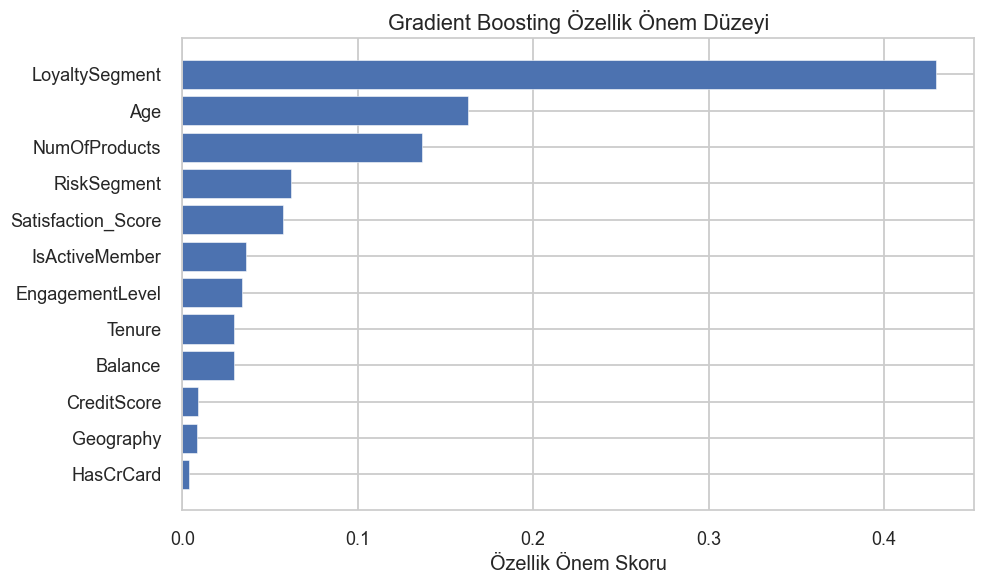

In [140]:
# Feature Importance (Özelliklerin Önemi)
feature_importance = gbm_1.feature_importances_
sorted_idx = np.argsort(feature_importance)

# Özelliklerin önem sırasını görselleştir
plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], feature_importance[sorted_idx])
plt.xlabel("Özellik Önem Skoru")
plt.title("Gradient Boosting Özellik Önem Düzeyi")
plt.tight_layout()
plt.show()

In [141]:
# Classification Report
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))



Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1607
           1       0.92      0.81      0.86       393

    accuracy                           0.95      2000
   macro avg       0.94      0.89      0.91      2000
weighted avg       0.95      0.95      0.95      2000



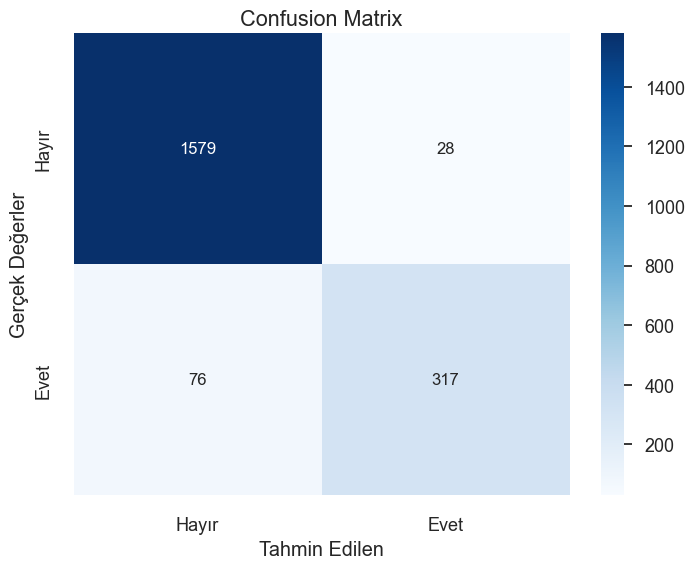

In [142]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hayır', 'Evet'], yticklabels=['Hayır', 'Evet'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değerler')
plt.show()


### simülasyon

#### Resampling

In [143]:
data_real = data_1.copy()

In [144]:
data_real.Exited.value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

In [145]:
from sklearn.utils import resample

# Azınlık ve çoğunluk sınıflarını ayıralım
minority_class_real = data_real[data_real['Exited'] == 1]
majority_class_real = data_real[data_real['Exited'] == 0]

# Azınlık sınıfını çoğaltma işlemi
minority_upsampled_real = resample(minority_class_real, 
                                   replace=True,     # Veriler tekrarlanabilir
                                   n_samples=7962,   # Eşit sayıya ulaşana kadar çoğalt
                                   random_state=42)

# Yeni dengeyi oluşturma
balanced_data_real = pd.concat([majority_class_real, minority_upsampled_real])

# Yeni sınıf dağılımı ve örnek verinin ilk birkaç satırı
balanced_data_real['Exited'].value_counts(), balanced_data_real.head()

(Exited
 0    7962
 1    7962
 Name: count, dtype: int64,
    CreditScore  Geography  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
 1          608          2   41       1   83807.86              1          0   
 3          699          0   39       1       0.00              2          0   
 4          850          2   43       2  125510.82              1          1   
 6          822          0   50       7       0.00              2          1   
 8          501          0   44       4  142051.07              2          0   
 
    IsActiveMember  Exited  Satisfaction_Score  LoyaltySegment  \
 1               1       0                   3               1   
 3               0       0                   5               2   
 4               1       0                   5               2   
 6               1       0                   2               0   
 8               1       0                   3               0   
 
    EngagementLevel  RiskSegment  
 1                2        

In [146]:
balanced_data_real.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15924 entries, 1 to 3935
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         15924 non-null  int64  
 1   Geography           15924 non-null  int32  
 2   Age                 15924 non-null  int64  
 3   Tenure              15924 non-null  int64  
 4   Balance             15924 non-null  float64
 5   NumOfProducts       15924 non-null  int64  
 6   HasCrCard           15924 non-null  int64  
 7   IsActiveMember      15924 non-null  int64  
 8   Exited              15924 non-null  int64  
 9   Satisfaction_Score  15924 non-null  int64  
 10  LoyaltySegment      15924 non-null  int32  
 11  EngagementLevel     15924 non-null  int32  
 12  RiskSegment         15924 non-null  int32  
dtypes: float64(1), int32(4), int64(8)
memory usage: 1.5 MB


In [147]:
balanced_data_real.Exited.value_counts()

Exited
0    7962
1    7962
Name: count, dtype: int64

In [148]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Özellikler ve hedef değişkeni ayır
X = balanced_data_real.drop("Exited", axis=1)
y = balanced_data_real["Exited"]

# Veriyi eğitim ve test olarak böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Gradient Boosting modelini oluştur
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Modeli eğit
gbm.fit(X_train, y_train)

# Tahmin yap
y_pred = gbm.predict(X_test)

# Modelin doğruluğunu hesapla
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluğu: {accuracy:.4f}")


Model Doğruluğu: 0.9334


In [149]:
# Modelin doğruluğunu hesapla
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluğu: {accuracy:.4f}")

# F1 skoru
f1 = f1_score(y_test, y_pred)
print(f"F1 Skoru: {f1:.4f}")

# Test seti boyutu
test_size = len(y_test)
print(f"Test Seti Boyutu: {test_size}")

Model Doğruluğu: 0.9334
F1 Skoru: 0.9326
Test Seti Boyutu: 3185


In [150]:
# Classification Report
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))



Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      1620
           1       0.93      0.94      0.93      1565

    accuracy                           0.93      3185
   macro avg       0.93      0.93      0.93      3185
weighted avg       0.93      0.93      0.93      3185



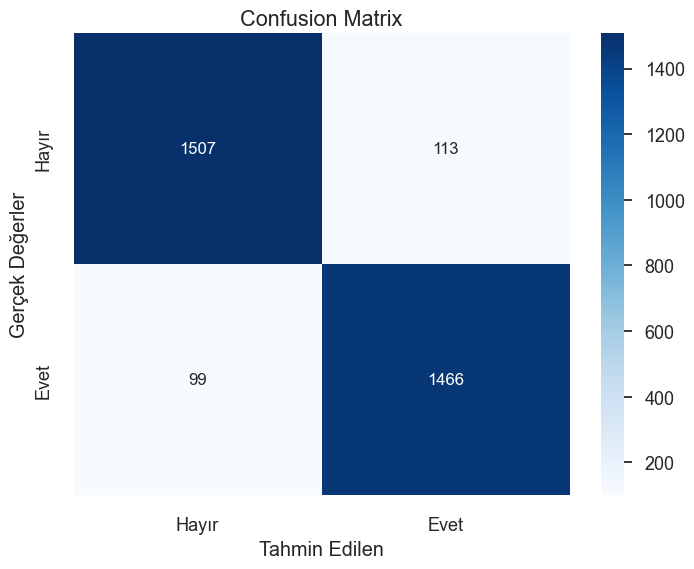

In [151]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hayır', 'Evet'], yticklabels=['Hayır', 'Evet'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değerler')
plt.show()


AUC: 0.9856


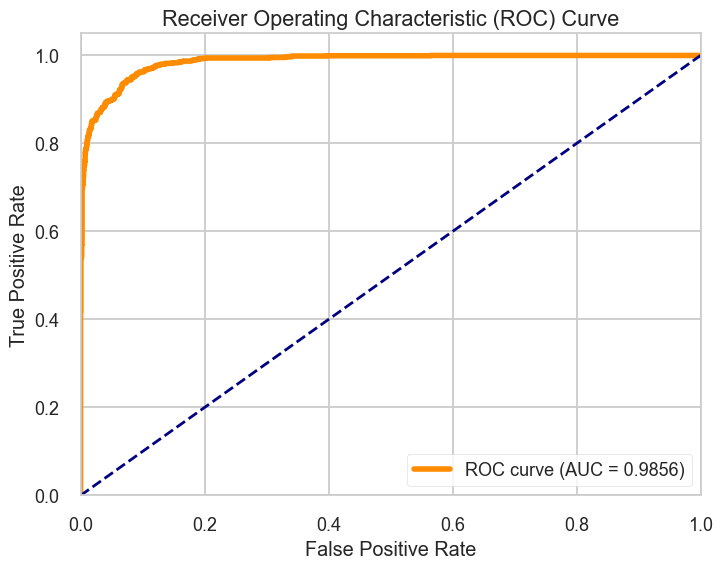

In [152]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Modelin tahmin ettiği sınıf olasılıkları (pozitif sınıf için)
y_prob = gbm.predict_proba(X_test)[:, 1]  # Pozitif sınıfın (Exited=1) olasılıkları

# ROC eğrisini hesapla
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC değerini hesapla
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=4, label=f'ROC curve (AUC = {roc_auc:.4f})')  # linewidth=4 ile kalınlaştırdık
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


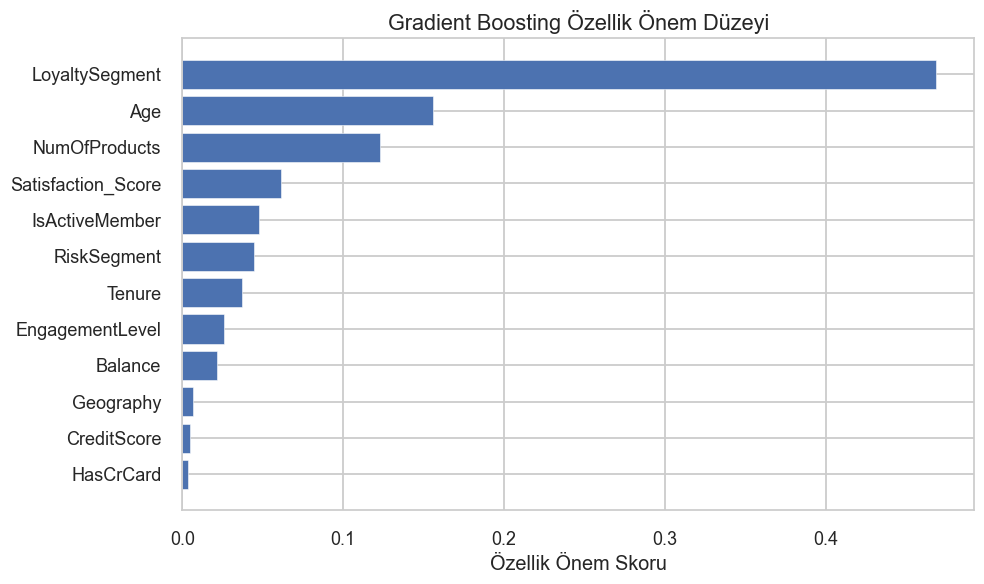

In [153]:
# Feature Importance (Özelliklerin Önemi)
feature_importance = gbm.feature_importances_
sorted_idx = np.argsort(feature_importance)

# Özelliklerin önem sırasını görselleştir
plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], feature_importance[sorted_idx])
plt.xlabel("Özellik Önem Skoru")
plt.title("Gradient Boosting Özellik Önem Düzeyi")
plt.tight_layout()
plt.show()

#### Undersampling

In [154]:
data_real_1 = data_1.copy()

In [155]:
data_real_1.Exited.value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

In [156]:
from sklearn.utils import resample
import pandas as pd

# Çoğunluk ve azınlık sınıfı ayır
majority = data_real_1[data_real_1["Exited"] == 0]
minority = data_real_1[data_real_1["Exited"] == 1]

# Çoğunluk sınıfı azınlık sınıfı kadar örnekle (rastgele)
majority_downsampled = resample(majority,
                                replace=False,       # tekrar seçmeden
                                n_samples=len(minority),  # azınlık kadar örnek
                                random_state=42)     # tekrarlanabilirlik için

# Yeni dengelenmiş veri setini oluştur
data_balanced = pd.concat([majority_downsampled, minority])

# Satırları karıştır (isteğe bağlı ama tavsiye edilir)
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [157]:
print(data_balanced["Exited"].value_counts())


Exited
0    2038
1    2038
Name: count, dtype: int64


In [158]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Özellikler ve hedef değişkeni ayır
X = data_balanced.drop("Exited", axis=1)
y = data_balanced["Exited"]

# Veriyi eğitim ve test olarak böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Gradient Boosting modelini oluştur
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Modeli eğit
gbm.fit(X_train, y_train)

# Tahmin yap
y_pred = gbm.predict(X_test)

In [159]:
# Modelin doğruluğunu hesapla
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluğu: {accuracy:.4f}")

# F1 skoru
f1 = f1_score(y_test, y_pred)
print(f"F1 Skoru: {f1:.4f}")

# Test seti boyutu
test_size = len(y_test)
print(f"Test Seti Boyutu: {test_size}")

Model Doğruluğu: 0.9130
F1 Skoru: 0.9125
Test Seti Boyutu: 816


In [160]:
# Classification Report
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))



Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       416
           1       0.90      0.93      0.91       400

    accuracy                           0.91       816
   macro avg       0.91      0.91      0.91       816
weighted avg       0.91      0.91      0.91       816



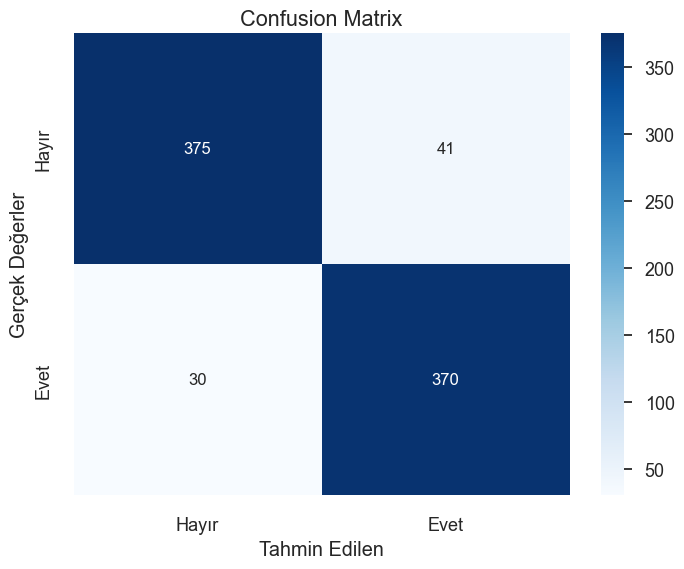

In [161]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hayır', 'Evet'], yticklabels=['Hayır', 'Evet'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değerler')
plt.show()


AUC: 0.9736


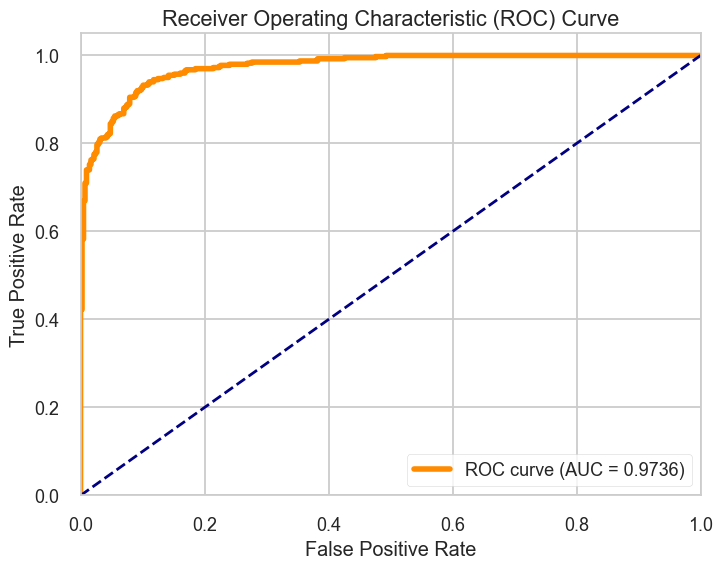

In [162]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Modelin tahmin ettiği sınıf olasılıkları (pozitif sınıf için)
y_prob = gbm.predict_proba(X_test)[:, 1]  # Pozitif sınıfın (Exited=1) olasılıkları

# ROC eğrisini hesapla
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC değerini hesapla
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=4, label=f'ROC curve (AUC = {roc_auc:.4f})')  # linewidth=4 ile kalınlaştırdık
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


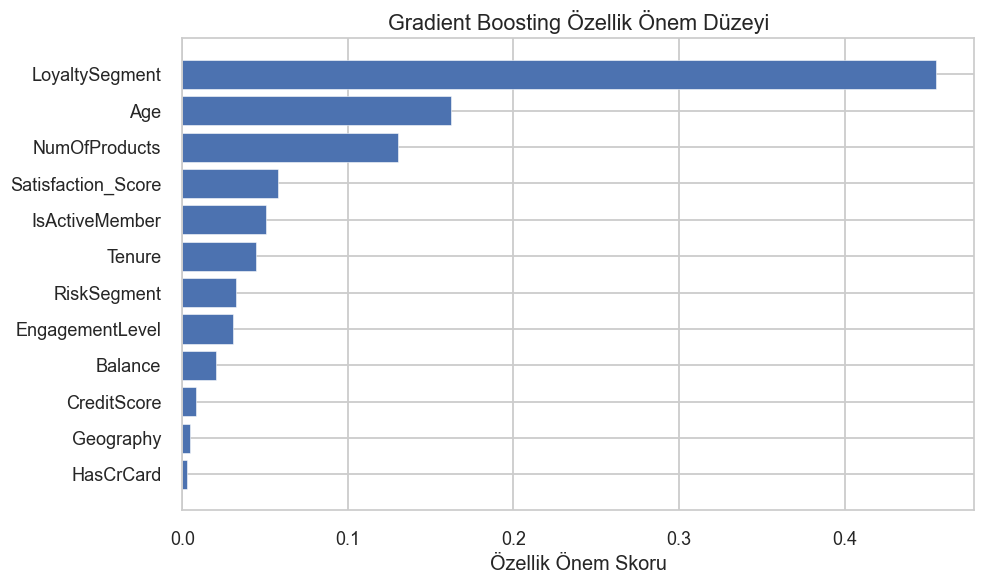

In [163]:
# Feature Importance (Özelliklerin Önemi)
feature_importance = gbm.feature_importances_
sorted_idx = np.argsort(feature_importance)

# Özelliklerin önem sırasını görselleştir
plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], feature_importance[sorted_idx])
plt.xlabel("Özellik Önem Skoru")
plt.title("Gradient Boosting Özellik Önem Düzeyi")
plt.tight_layout()
plt.show()

## Artificial Neural Network

In [164]:
data_2 = data1.copy()

In [165]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Özellikler ve hedef değişkeni ayır
X = data_2.drop("Exited", axis=1)
y = data_2["Exited"]

# Veriyi eğitim ve test olarak böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Veriyi ölçeklendir
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modeli oluştur
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary classification için sigmoid

# Modeli derle
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# Modeli eğit
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Modeli test et
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")


C:\Users\mehdi\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7551 - loss: 0.5427 - val_accuracy: 0.8006 - val_loss: 0.3953
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8163 - loss: 0.3744 - val_accuracy: 0.8625 - val_loss: 0.3020
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8764 - loss: 0.2839 - val_accuracy: 0.9144 - val_loss: 0.2302
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9210 - loss: 0.2219 - val_accuracy: 0.9256 - val_loss: 0.1917
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9331 - loss: 0.1898 - val_accuracy: 0.9337 - val_loss: 0.1762
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9333 - loss: 0.1744 - val_accuracy: 0.9356 - val_loss: 0.1674
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9359 - loss: 0.1632 - val_accuracy: 0.9369 - val_loss: 0.1637
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9411 - loss: 0.1593 - val_accuracy: 0.

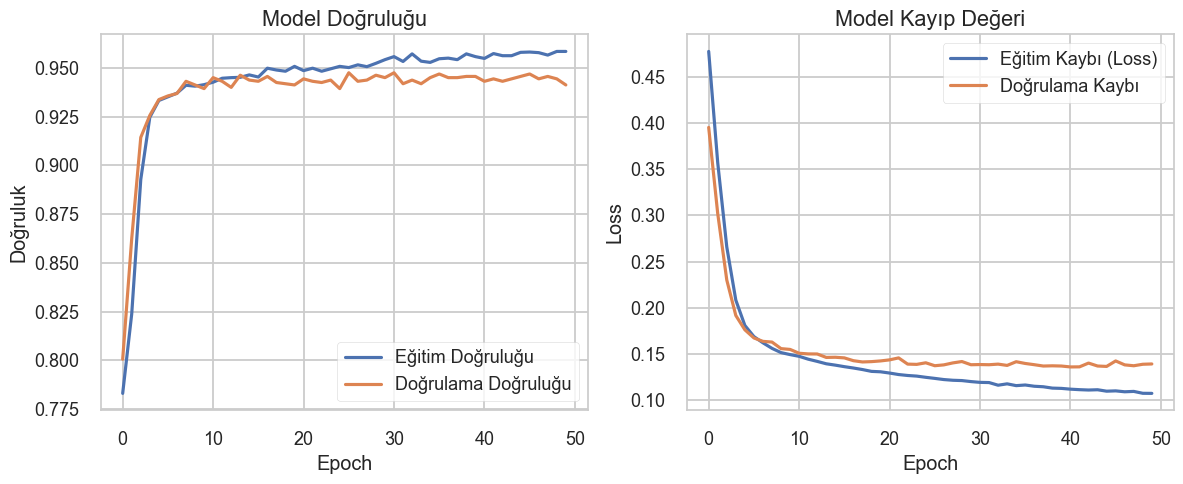

In [166]:
import matplotlib.pyplot as plt

# Accuracy grafiği
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Model Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()

# Loss grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı (Loss)')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Model Kayıp Değeri')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


## Logistic Regression

In [167]:
df_log = data1.copy()

In [168]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Özellikler ve hedef değişkeni ayır
X = df_log.drop("Exited", axis=1)
y = df_log["Exited"]

# Eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli oluştur
log_model_2 = LogisticRegression(max_iter=1000, random_state=42)

# Modeli eğit
log_model_2.fit(X_train, y_train)

# Tahmin yap
y_pred = log_model_2.predict(X_test)

In [169]:
# Skorları hesapla
train_score = log_model_2.score(X_train, y_train)
test_score = log_model_2.score(X_test, y_test)
f1 = f1_score(y_test, y_pred)

# Sonuçları tablo halinde göster
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Train Score": [train_score],
    "Test Score": [test_score],
    "F1 Score": [f1]
})

print(results)

                 Model  Train Score  Test Score  F1 Score
0  Logistic Regression     0.787875       0.798  0.117904


In [170]:
# Classification Report
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))



Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.81      0.98      0.89      1607
           1       0.42      0.07      0.12       393

    accuracy                           0.80      2000
   macro avg       0.61      0.52      0.50      2000
weighted avg       0.73      0.80      0.74      2000



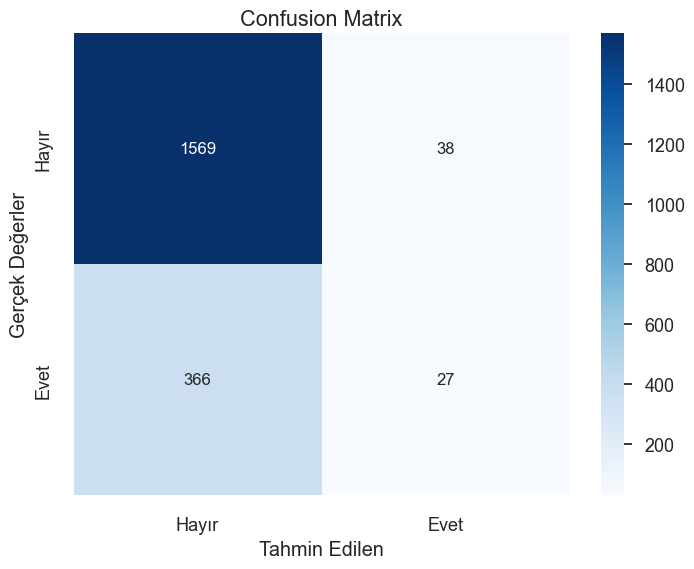

In [171]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hayır', 'Evet'], yticklabels=['Hayır', 'Evet'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değerler')
plt.show()


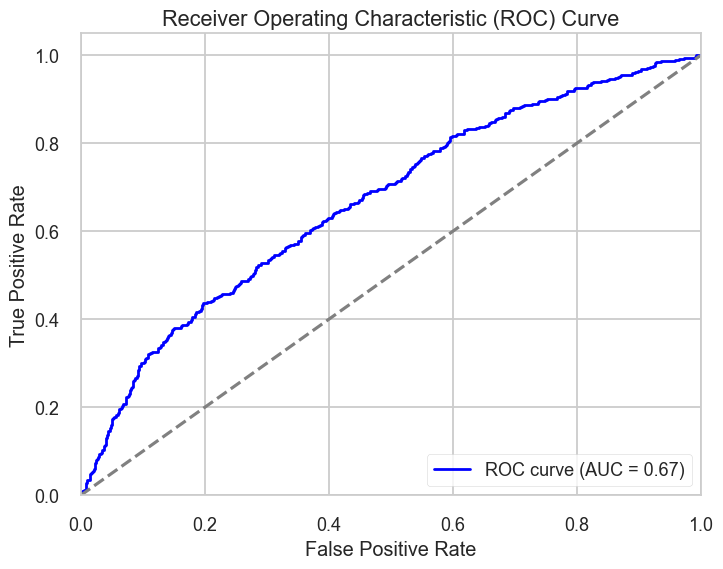

In [172]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# True Positive Rate (TPR) ve False Positive Rate (FPR) hesapla
fpr, tpr, thresholds = roc_curve(y_test, log_model_2.predict_proba(X_test)[:, 1])

# AUC (Area Under the Curve) hesapla
roc_auc = auc(fpr, tpr)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

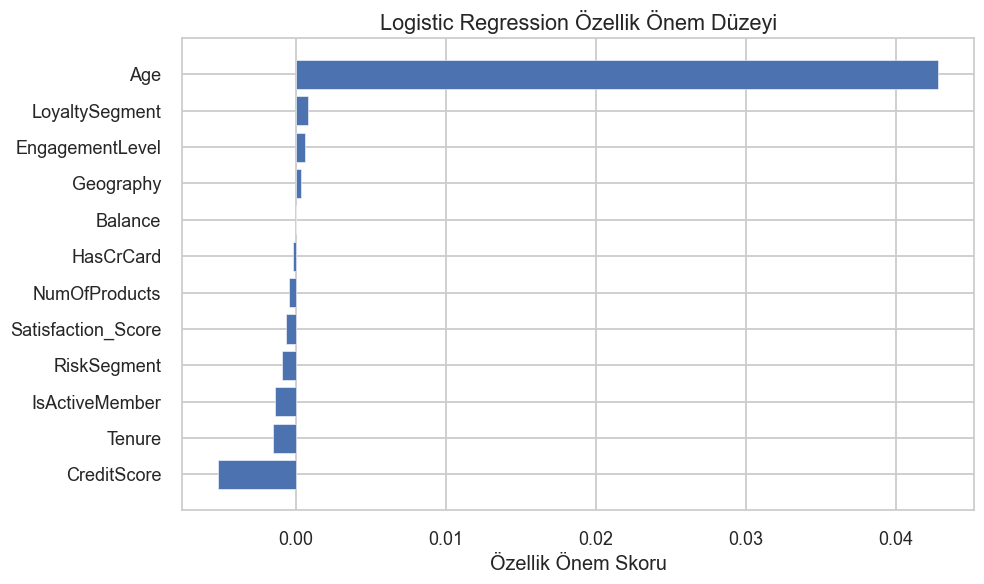

In [173]:
# Logistic Regression modelinden katsayıları al
coefficients = log_model_2.coef_[0]

# Özellik isimlerini al
sorted_idx = np.argsort(coefficients)

# Özelliklerin önem sırasını görselleştir
plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], coefficients[sorted_idx])
plt.xlabel("Özellik Önem Skoru")
plt.title("Logistic Regression Özellik Önem Düzeyi")
plt.tight_layout()
plt.show()


### simülasyon

#### Resampling

In [174]:
data_real_2 = data1.copy()

In [175]:
from sklearn.utils import resample

# Azınlık ve çoğunluk sınıflarını ayıralım
minority_class_real = data_real_2[data_real_2['Exited'] == 1]
majority_class_real = data_real_2[data_real_2['Exited'] == 0]

# Azınlık sınıfını çoğaltma işlemi
minority_upsampled_real = resample(minority_class_real, 
                                   replace=True,     # Veriler tekrarlanabilir
                                   n_samples=7962,   # Eşit sayıya ulaşana kadar çoğalt
                                   random_state=42)

# Yeni dengeyi oluşturma
balanced_data_real = pd.concat([majority_class_real, minority_upsampled_real])

# Yeni sınıf dağılımı ve örnek verinin ilk birkaç satırı
balanced_data_real['Exited'].value_counts(), balanced_data_real.head()

(Exited
 0    7962
 1    7962
 Name: count, dtype: int64,
    CreditScore  Geography  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
 1          608          2   41       1   83807.86              1          0   
 3          699          0   39       1       0.00              2          0   
 4          850          2   43       2  125510.82              1          1   
 6          822          0   50       7       0.00              2          1   
 8          501          0   44       4  142051.07              2          0   
 
    IsActiveMember  Exited  Satisfaction_Score  LoyaltySegment  \
 1               1       0                   3               1   
 3               0       0                   5               2   
 4               1       0                   5               2   
 6               1       0                   2               0   
 8               1       0                   3               0   
 
    EngagementLevel  RiskSegment  
 1                2        

In [176]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Özellikler ve hedef değişkeni ayır
X = balanced_data_real.drop("Exited", axis=1)
y = balanced_data_real["Exited"]

# Eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli oluştur
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Modeli eğit
log_model.fit(X_train, y_train)

# Tahmin yap
y_pred = log_model.predict(X_test)

In [177]:
# Skorları hesapla
train_score = log_model.score(X_train, y_train)
test_score = log_model.score(X_test, y_test)
f1 = f1_score(y_test, y_pred)

# Sonuçları tablo halinde göster
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Train Score": [train_score],
    "Test Score": [test_score],
    "F1 Score": [f1]
})

print(results)

                 Model  Train Score  Test Score  F1 Score
0  Logistic Regression     0.657744    0.671272  0.669403


In [178]:
# Classification Report
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))



Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.68      0.67      0.67      1620
           1       0.66      0.68      0.67      1565

    accuracy                           0.67      3185
   macro avg       0.67      0.67      0.67      3185
weighted avg       0.67      0.67      0.67      3185



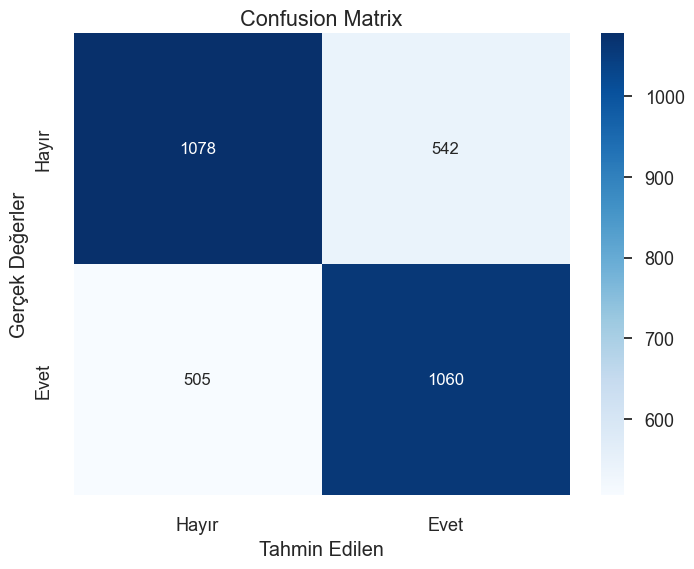

In [179]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hayır', 'Evet'], yticklabels=['Hayır', 'Evet'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değerler')
plt.show()


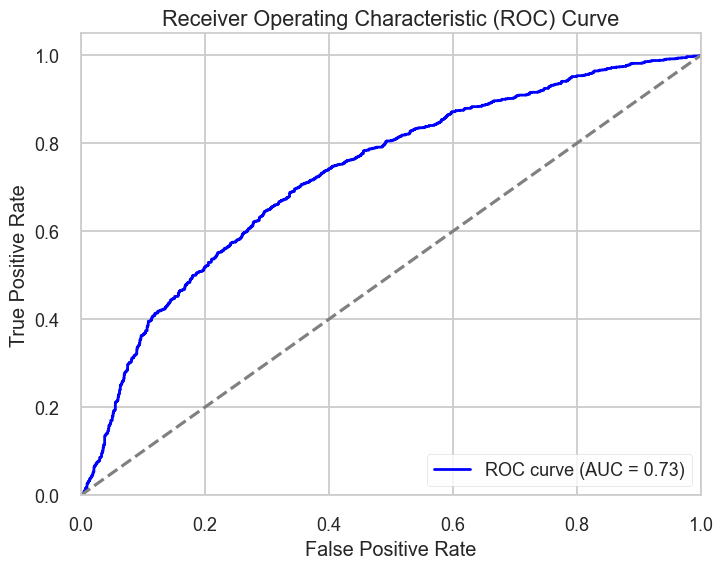

In [180]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# True Positive Rate (TPR) ve False Positive Rate (FPR) hesapla
fpr, tpr, thresholds = roc_curve(y_test, log_model.predict_proba(X_test)[:, 1])

# AUC (Area Under the Curve) hesapla
roc_auc = auc(fpr, tpr)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

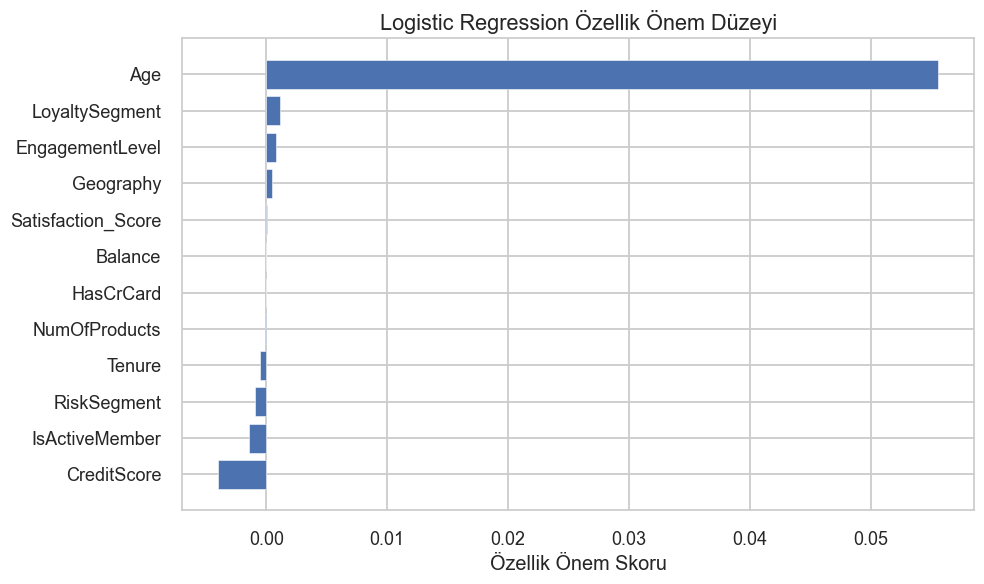

In [181]:
# Logistic Regression modelinden katsayıları al
coefficients = log_model.coef_[0]

# Özellik isimlerini al
sorted_idx = np.argsort(coefficients)

# Özelliklerin önem sırasını görselleştir
plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], coefficients[sorted_idx])
plt.xlabel("Özellik Önem Skoru")
plt.title("Logistic Regression Özellik Önem Düzeyi")
plt.tight_layout()
plt.show()


##### Parametre Optimizasyonu (GridSearchCV ile)

In [182]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

# Özellikler ve hedef değişkeni ayır
X = balanced_data_real.drop("Exited", axis=1)
y = balanced_data_real["Exited"]

# Eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression modelini oluştur
log_model = LogisticRegression(max_iter=1000, random_state=42)

In [183]:
# Parametreler için bir grid tanımla
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularizasyon gücü
    'penalty': ['l1', 'l2'],  # Regularizasyon türü
    'solver': ['liblinear', 'saga'],  # Çözümleyici türü
}

In [184]:
# GridSearchCV ile parametre optimizasyonu yap
grid_search = GridSearchCV(estimator=log_model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='f1', verbose=1)

In [185]:
# En iyi parametreleri al
best_params = grid_search.best_params_
print(f"En iyi parametreler: {best_params}")

En iyi parametreler: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


In [186]:
# En iyi modeli al
best_log_model = grid_search.best_estimator_

In [187]:
# Test setinde tahmin yap
y_pred = best_log_model.predict(X_test)

# Modelin başarı oranlarını yazdır
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [188]:
print(f"En İyi Model Test Doğruluğu: {accuracy:.4f}")
print(f"En İyi Model F1 Skoru: {f1:.4f}")

En İyi Model Test Doğruluğu: 0.7061
En İyi Model F1 Skoru: 0.7019


#### Undersampling

In [189]:
data_real_ = data1.copy()

In [190]:
from sklearn.utils import resample
import pandas as pd

# Çoğunluk ve azınlık sınıfı ayır
majority = data_real_[data_real_["Exited"] == 0]
minority = data_real_[data_real_["Exited"] == 1]

# Çoğunluk sınıfı azınlık sınıfı kadar örnekle (rastgele)
majority_downsampled = resample(majority,
                                replace=False,       # tekrar seçmeden
                                n_samples=len(minority),  # azınlık kadar örnek
                                random_state=42)     # tekrarlanabilirlik için

# Yeni dengelenmiş veri setini oluştur
data_balanced = pd.concat([majority_downsampled, minority])

# Satırları karıştır (isteğe bağlı ama tavsiye edilir)
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [191]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Özellikler ve hedef değişkeni ayır
X = data_balanced.drop("Exited", axis=1)
y = data_balanced["Exited"]

# Eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli oluştur
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Modeli eğit
log_model.fit(X_train, y_train)

# Tahmin yap
y_pred = log_model.predict(X_test)

In [192]:
# Skorları hesapla
train_score = log_model.score(X_train, y_train)
test_score = log_model.score(X_test, y_test)
f1 = f1_score(y_test, y_pred)

# Sonuçları tablo halinde göster
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Train Score": [train_score],
    "Test Score": [test_score],
    "F1 Score": [f1]
})

print(results)

                 Model  Train Score  Test Score  F1 Score
0  Logistic Regression     0.658589    0.667892  0.669109


In [193]:
# Classification Report
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))



Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.68      0.65      0.67       416
           1       0.65      0.69      0.67       400

    accuracy                           0.67       816
   macro avg       0.67      0.67      0.67       816
weighted avg       0.67      0.67      0.67       816



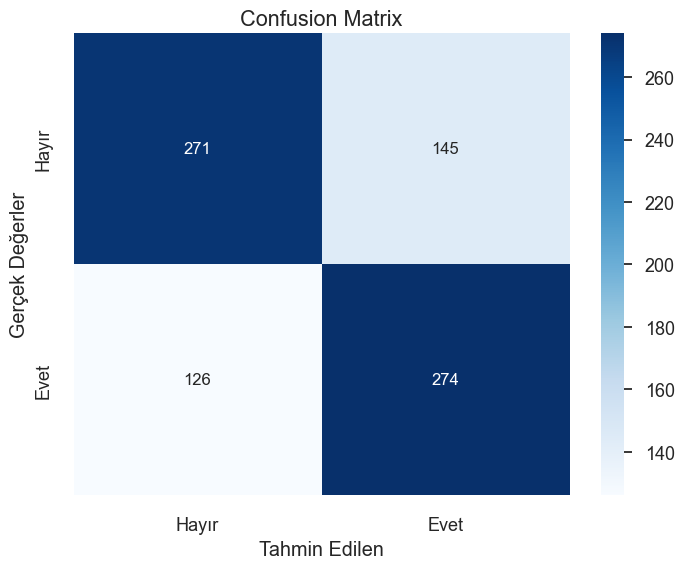

In [194]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hayır', 'Evet'], yticklabels=['Hayır', 'Evet'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değerler')
plt.show()


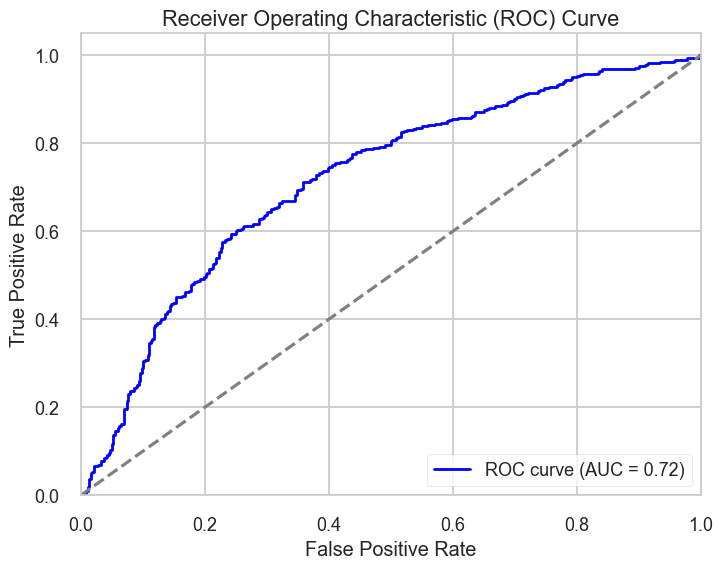

In [195]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# True Positive Rate (TPR) ve False Positive Rate (FPR) hesapla
fpr, tpr, thresholds = roc_curve(y_test, log_model.predict_proba(X_test)[:, 1])

# AUC (Area Under the Curve) hesapla
roc_auc = auc(fpr, tpr)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

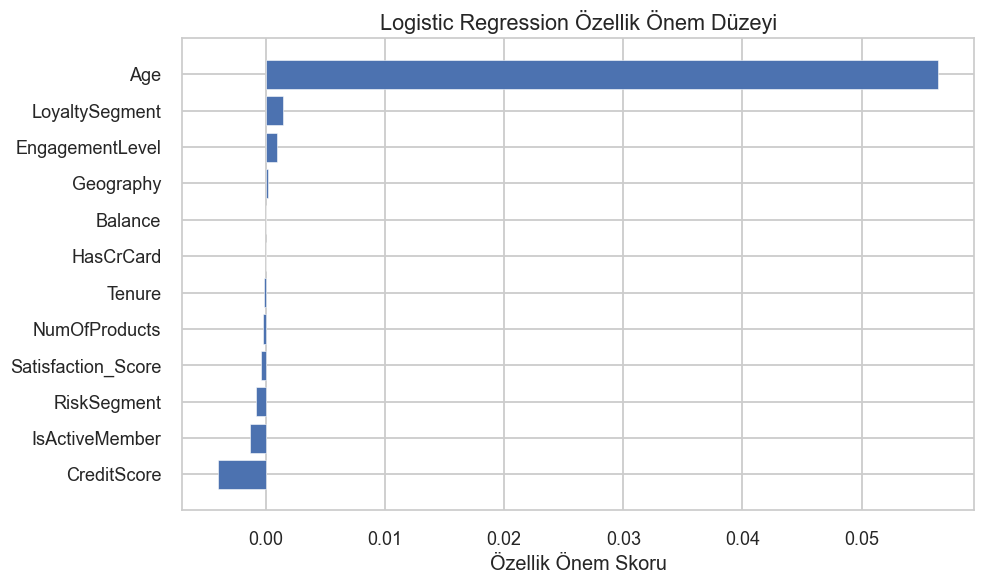

In [196]:
# Logistic Regression modelinden katsayıları al
coefficients = log_model.coef_[0]

# Özellik isimlerini al
sorted_idx = np.argsort(coefficients)

# Özelliklerin önem sırasını görselleştir
plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], coefficients[sorted_idx])
plt.xlabel("Özellik Önem Skoru")
plt.title("Logistic Regression Özellik Önem Düzeyi")
plt.tight_layout()
plt.show()


## SVM

In [197]:
df_svm = data1.copy()

In [198]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

In [199]:
X = df_svm.drop('Exited', axis=1)
y = df_svm['Exited']

In [200]:
# Verinin ölçeklenmesi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [202]:
svm_model_3 = SVC(kernel='rbf', random_state=42)
svm_model_3.fit(X_train, y_train)

SVC(random_state=42)

In [203]:
# Tahmin ve başarı ölçümleri
y_pred = svm_model_3.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9510
F1 Score: 0.8676


### Optimizasyon

In [204]:
svm_params= {"C":np.arange(1,5),
            "kernel":["linear","rbf"]}

In [205]:
svm= SVC()

In [206]:
svm_cv_model= GridSearchCV(svm,svm_params,cv=5,n_jobs=-1,verbose=2).fit(X_train,y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [207]:
svm_cv_model.best_score_

0.9456249999999999

In [208]:
#Hiperparametre
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}


In [209]:
#GridSearchCV
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)


Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']},
             scoring='f1', verbose=1)

In [210]:
# best model
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test)


In [211]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("En iyi parametreler:", grid.best_params_)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

En iyi parametreler: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Accuracy: 0.9505
F1 Score: 0.8692


In [212]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Sınıflandırma raporu
print("Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred))


Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1607
           1       0.90      0.84      0.87       393

    accuracy                           0.95      2000
   macro avg       0.93      0.91      0.92      2000
weighted avg       0.95      0.95      0.95      2000



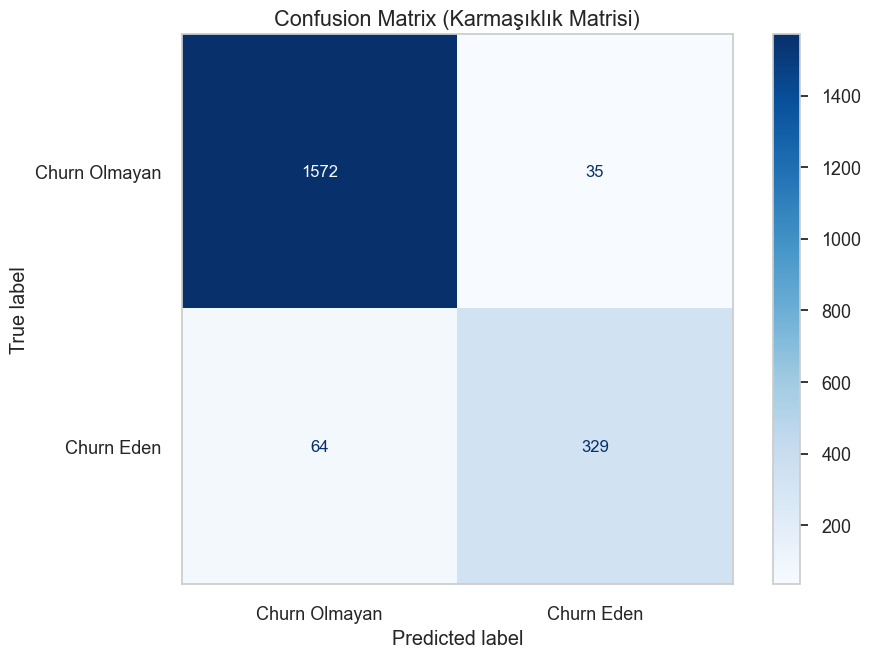

In [213]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Churn Olmayan", "Churn Eden"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Karmaşıklık Matrisi)")
plt.grid(False)
plt.show()

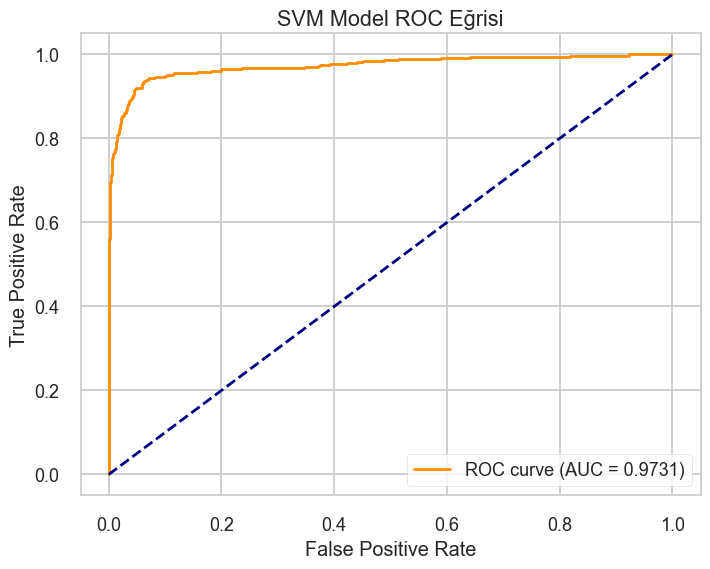

In [214]:
best_svm = SVC(kernel='rbf', C=grid.best_params_['C'], gamma=grid.best_params_['gamma'], probability=True)
best_svm.fit(X_train, y_train)

# Test seti için olasılık tahminleri
y_proba = best_svm.predict_proba(X_test)[:, 1]

# ROC eğrisi için false positive rate, true positive rate
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM Model ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### similasyon

In [215]:
df_svm_res = df_svm.copy()

In [216]:
from sklearn.utils import resample

# Azınlık ve çoğunluk sınıflarını ayıralım
minority_class_real = df_svm_res[df_svm_res['Exited'] == 1]
majority_class_real = df_svm_res[df_svm_res['Exited'] == 0]

# Azınlık sınıfını çoğaltma işlemi
minority_upsampled_real = resample(minority_class_real, 
                                   replace=True,     # Veriler tekrarlanabilir
                                   n_samples=7962,   # Eşit sayıya ulaşana kadar çoğalt
                                   random_state=42)

# Yeni dengeyi oluşturma
balanced_data_real = pd.concat([majority_class_real, minority_upsampled_real])

# Yeni sınıf dağılımı ve örnek verinin ilk birkaç satırı
balanced_data_real['Exited'].value_counts(), balanced_data_real.head()

(Exited
 0    7962
 1    7962
 Name: count, dtype: int64,
    CreditScore  Geography  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
 1          608          2   41       1   83807.86              1          0   
 3          699          0   39       1       0.00              2          0   
 4          850          2   43       2  125510.82              1          1   
 6          822          0   50       7       0.00              2          1   
 8          501          0   44       4  142051.07              2          0   
 
    IsActiveMember  Exited  Satisfaction_Score  LoyaltySegment  \
 1               1       0                   3               1   
 3               0       0                   5               2   
 4               1       0                   5               2   
 6               1       0                   2               0   
 8               1       0                   3               0   
 
    EngagementLevel  RiskSegment  
 1                2        

In [217]:
X = balanced_data_real.drop('Exited', axis=1)
y = balanced_data_real['Exited']

# Verinin ölçeklenmesi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Eğitim ve test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)


y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9422
F1 Score: 0.9418


In [218]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Sınıflandırma raporu
print("Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred))


Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1620
           1       0.93      0.95      0.94      1565

    accuracy                           0.94      3185
   macro avg       0.94      0.94      0.94      3185
weighted avg       0.94      0.94      0.94      3185



In [219]:
#Hiperparametre
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}


In [220]:
#GridSearchCV
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)


Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']},
             scoring='f1', verbose=1)

In [221]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("En iyi parametreler:", grid.best_params_)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

En iyi parametreler: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Accuracy: 0.9422
F1 Score: 0.9418


In [222]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Sınıflandırma raporu
print("Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred))


Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1620
           1       0.93      0.95      0.94      1565

    accuracy                           0.94      3185
   macro avg       0.94      0.94      0.94      3185
weighted avg       0.94      0.94      0.94      3185



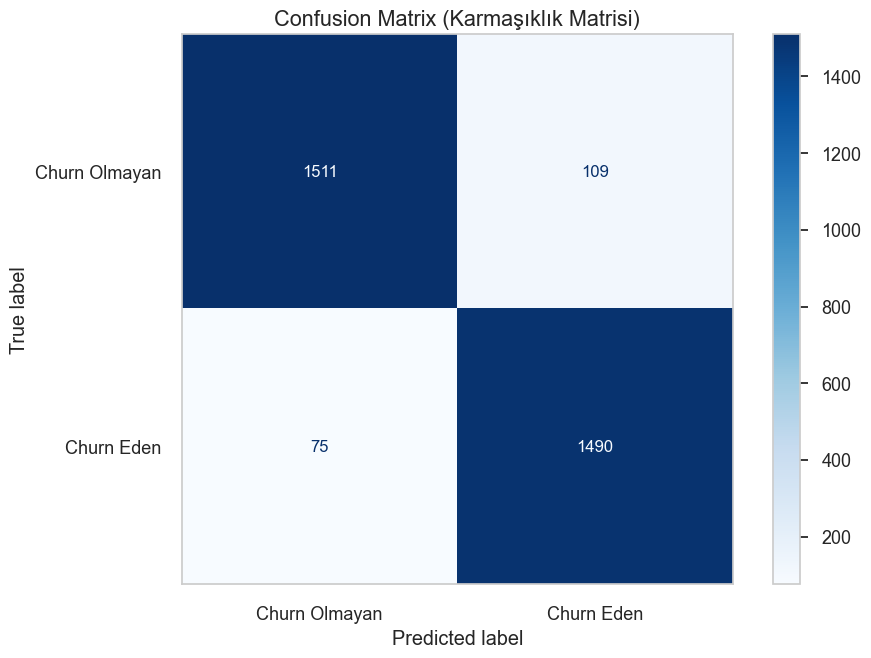

In [223]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Churn Olmayan", "Churn Eden"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Karmaşıklık Matrisi)")
plt.grid(False)
plt.show()

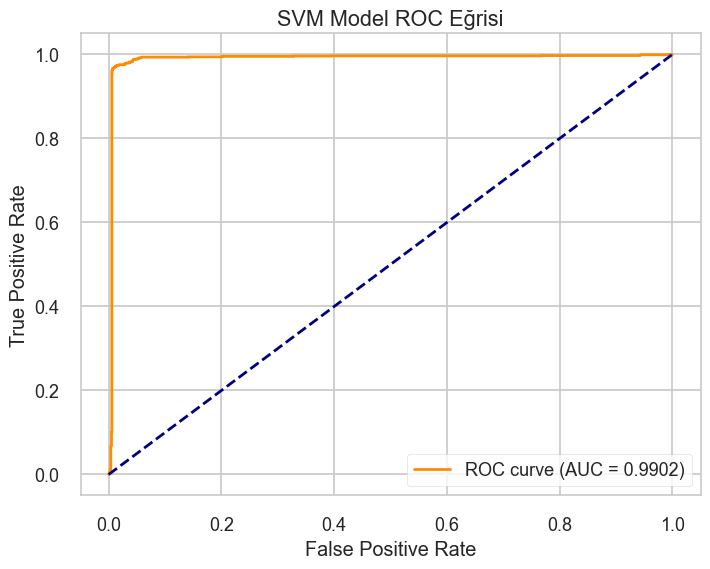

In [224]:
best_svm = SVC(kernel='rbf', C=grid.best_params_['C'], gamma=grid.best_params_['gamma'], probability=True)
best_svm.fit(X_train, y_train)

# Test seti için olasılık tahminleri
y_proba = best_svm.predict_proba(X_test)[:, 1]

# ROC eğrisi için false positive rate, true positive rate
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM Model ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## KNN

In [225]:
df_knn = data1.copy()

In [226]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

In [227]:
X = df_knn.drop('Exited', axis=1)
y = df_knn['Exited']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [228]:
knn_model_4 = KNeighborsClassifier(n_neighbors=5)  # n_neighbors parametresi varsayılan olarak 5
knn_model_4.fit(X_train, y_train)

# Tahmin ve başarı ölçümleri
y_pred = knn_model_4.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9275
F1 Score: 0.8011


#### Optimizasyon 

In [229]:
param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}


In [230]:
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# En iyi parametreleri ve modeli al
best_knn_model = grid_search.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits


In [231]:
y_pred_best = best_knn_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print(f"Best KNN Accuracy: {accuracy_best:.4f}")
print(f"Best KNN F1 Score: {f1_best:.4f}")
print(f"Best K: {grid_search.best_params_['n_neighbors']}")

Best KNN Accuracy: 0.9300
Best KNN F1 Score: 0.8118
Best K: 3


In [232]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Sınıflandırma raporu
print("Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred))


Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.94      0.97      0.96      1607
           1       0.87      0.74      0.80       393

    accuracy                           0.93      2000
   macro avg       0.90      0.86      0.88      2000
weighted avg       0.93      0.93      0.93      2000



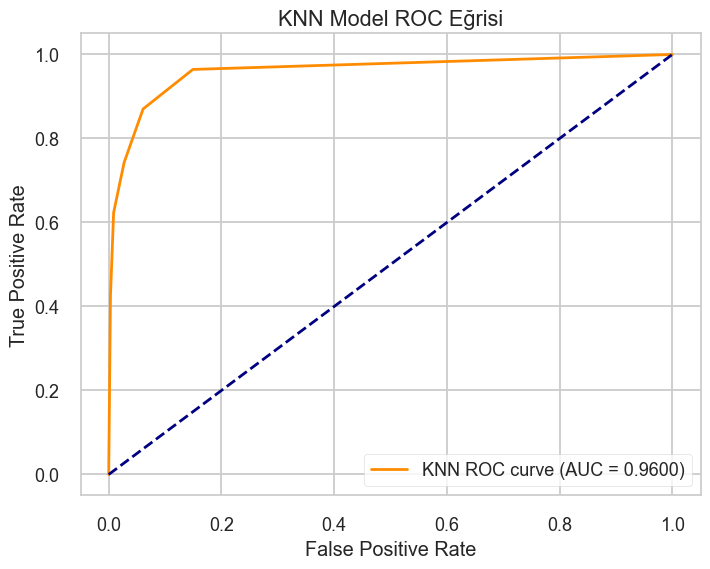

In [233]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# KNN modelini kullanarak olasılık tahminleri (class 1 için)
y_proba_knn = knn_model_4.predict_proba(X_test)[:, 1]

# ROC eğrisini hesapla
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='darkorange', lw=2, label=f'KNN ROC curve (AUC = {roc_auc_knn:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN Model ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## CatBoost

In [234]:
df_cat = data1.copy()

In [235]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# 1. Özellikler ve hedef değişken
X = df_cat.drop("Exited", axis=1)
y = df_cat["Exited"]

# 2. Eğitim ve test bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Kategorik sütun indekslerini al (CatBoost bunu ister)
cat_features = [i for i, col in enumerate(X.columns) if X[col].dtype == "object"]

# 4. Modeli tanımla ve eğit
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))

# 5. Tahmin ve değerlendirme
y_pred = cat_model.predict(X_test)
y_proba = cat_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9680


In [236]:
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.9734    0.9868    0.9800      1592
           1     0.9456    0.8946    0.9194       408

    accuracy                         0.9680      2000
   macro avg     0.9595    0.9407    0.9497      2000
weighted avg     0.9677    0.9680    0.9677      2000



In [237]:
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC AUC: {auc_score:.4f}")

ROC AUC: 0.9928


### simülasyon

In [238]:
from sklearn.utils import resample

# Azınlık ve çoğunluk sınıflarını ayıralım
minority_class_real_cat = df_cat[df_cat['Exited'] == 1]
minority_class_real_cat = df_cat[df_cat['Exited'] == 0]

# Azınlık sınıfını çoğaltma işlemi
minority_upsampled_real = resample(minority_class_real, 
                                   replace=True,     # Veriler tekrarlanabilir
                                   n_samples=7962,   # Eşit sayıya ulaşana kadar çoğalt
                                   random_state=42)

# Yeni dengeyi oluşturma
minority_class_real_cat = pd.concat([majority_class_real, minority_upsampled_real])

# Yeni sınıf dağılımı ve örnek verinin ilk birkaç satırı
minority_class_real_cat['Exited'].value_counts(), minority_class_real_cat.head()

(Exited
 0    7962
 1    7962
 Name: count, dtype: int64,
    CreditScore  Geography  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
 1          608          2   41       1   83807.86              1          0   
 3          699          0   39       1       0.00              2          0   
 4          850          2   43       2  125510.82              1          1   
 6          822          0   50       7       0.00              2          1   
 8          501          0   44       4  142051.07              2          0   
 
    IsActiveMember  Exited  Satisfaction_Score  LoyaltySegment  \
 1               1       0                   3               1   
 3               0       0                   5               2   
 4               1       0                   5               2   
 6               1       0                   2               0   
 8               1       0                   3               0   
 
    EngagementLevel  RiskSegment  
 1                2        

In [239]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# 1. Özellikler ve hedef değişken
X = minority_class_real_cat.drop("Exited", axis=1)
y = minority_class_real_cat["Exited"]

# 2. Eğitim ve test bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Kategorik sütun indekslerini al (CatBoost bunu ister)
cat_features = [i for i, col in enumerate(X.columns) if X[col].dtype == "object"]

# 4. Modeli tanımla ve eğit
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))

# 5. Tahmin ve değerlendirme
y_pred = cat_model.predict(X_test)
y_proba = cat_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9765


In [240]:
from sklearn.metrics import f1_score, accuracy_score

# Train verisinde tahmin yap
y_train_pred = cat_model.predict(X_train)

# Train ve Test için F1 skorlarını hesapla
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_pred)

# Train ve Test için doğruluk skorlarını da hesaplayalım (Accuracy zaten vardı ama derli toplu olsun)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Train F1 Score: {train_f1:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")


Train Accuracy: 0.9895
Test Accuracy: 0.9765
Train F1 Score: 0.9895
Test F1 Score: 0.9765


In [241]:
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.9798    0.9730    0.9764      1593
           1     0.9732    0.9799    0.9765      1592

    accuracy                         0.9765      3185
   macro avg     0.9765    0.9765    0.9765      3185
weighted avg     0.9765    0.9765    0.9765      3185



<Figure size 600x500 with 0 Axes>

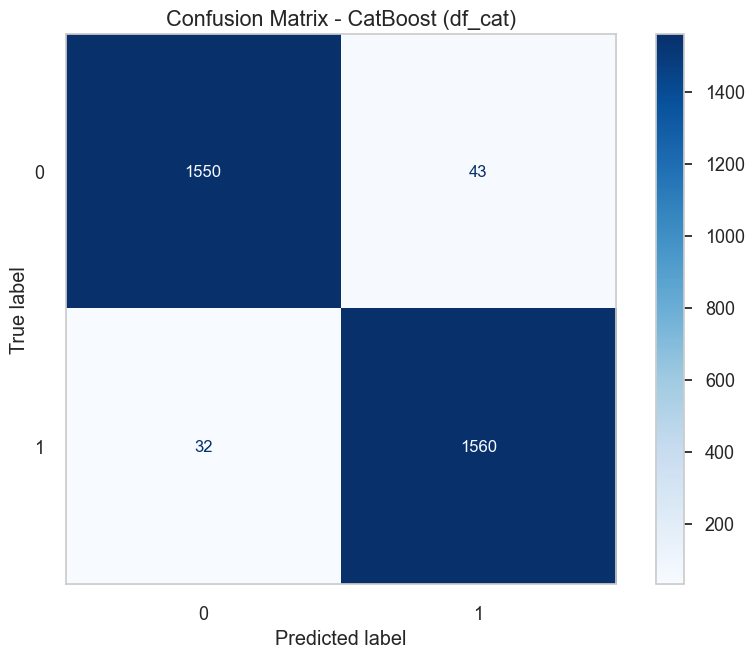

In [242]:
# Karmaşıklık matrisi hesapla
cm = confusion_matrix(y_test, y_pred)

# Görselleştir
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cat_model.classes_)
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - CatBoost (df_cat)")
plt.grid(False)
plt.show()

In [243]:
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC AUC: {auc_score:.4f}")

ROC AUC: 0.9973


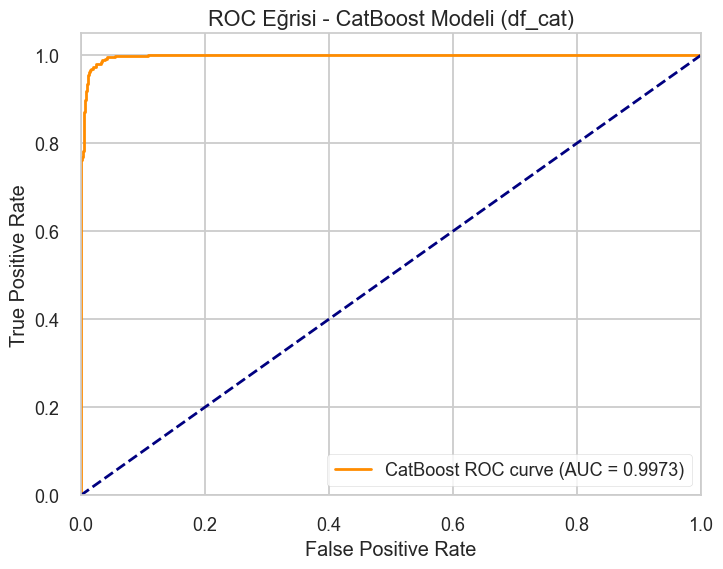

In [244]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC eğrisi için fpr (False Positive Rate) ve tpr (True Positive Rate) hesapla
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# ROC eğrisini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'CatBoost ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Eğrisi - CatBoost Modeli (df_cat)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### Parametre optimizasyonu

In [245]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

In [246]:
#Parametre aralığı
param_dist = {
    "iterations": [300, 500, 700, 1000],
    "learning_rate": np.linspace(0.01, 0.3, 10),
    "depth": [4, 5, 6, 7, 8, 9, 10],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "border_count": [32, 64, 128, 254],
    "bagging_temperature": np.linspace(0, 1, 10)
}


In [247]:
#RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_dist,
    n_iter=30,  # denenecek kombinasyon sayısı
    scoring="roc_auc",
    cv=3,  # 3-fold cross validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [248]:
random_search.fit(X_train, y_train, cat_features=cat_features)


Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=<catboost.core.CatBoostClassifier object at 0x000001BCFE7E5B90>,
                   n_iter=30, n_jobs=-1,
                   param_distributions={'bagging_temperature': array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]),
                                        'border_count': [32, 64, 128, 254],
                                        'depth': [4, 5, 6, 7, 8, 9, 10],
                                        'iterations': [300, 500, 700, 1000],
                                        'l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'learning_rate': array([0.01      , 0.04222222, 0.07444444, 0.10666667, 0.13888889,
       0.17111111, 0.20333333, 0.23555556, 0.26777778, 0.3       ])},
                   random_state=42, scoring='roc_auc', verbose=1)

In [249]:
best_model = random_search.best_estimator_

In [250]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [251]:
#Sonuçlar
accuracy_cat_2 = accuracy_score(y_test, y_pred)
roc_auc_cat_2 = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("Best Parameters:", random_search.best_params_)

Accuracy: 0.9765
ROC AUC: 0.9973
Best Parameters: {'learning_rate': 0.07444444444444444, 'l2_leaf_reg': 3, 'iterations': 1000, 'depth': 8, 'border_count': 254, 'bagging_temperature': 0.3333333333333333}


In [252]:
# Eğitim setinde performans
y_train_pred = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Test setinde performans
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

# F1 skor (test seti için)
f1 = f1_score(y_test, y_test_pred)

# Sonuçları tabloya koy
results_df = pd.DataFrame({
    "Model": ["catboost"],
    "Train Score": [train_accuracy],
    "Test Score": [test_accuracy],
    "F1 Score": [f1]
})

print(results_df)

      Model  Train Score  Test Score  F1 Score
0  catboost          1.0    0.987127  0.987247


In [253]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1593
           1       0.98      1.00      0.99      1592

    accuracy                           0.99      3185
   macro avg       0.99      0.99      0.99      3185
weighted avg       0.99      0.99      0.99      3185



#### Genel değerlendirme

# Comparative Analysis of Models

In [254]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [255]:
# --- Gerekli Kütüphaneler ---
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# --- Model Performansını Değerlendirme Fonksiyonu ---
def evaluate_model(model, X, y, model_name, dataset_name, scale_data=False):
    # Eğitim ve test ayrımı
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Gerekirse veri ölçekleme
    if scale_data:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    
    # Model eğitimi
    model.fit(X_train, y_train)

    # Tahminler
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Skorlar
    train_score = accuracy_score(y_train, y_pred_train)
    test_score = accuracy_score(y_test, y_pred_test)
    train_f1 = f1_score(y_train, y_pred_train)
    test_f1 = f1_score(y_test, y_pred_test)

    # Sonucu döndür
    return {
        "Dataset": dataset_name,
        "Model": model_name,
        "Train Score": train_score,
        "Test Score": test_score,
        "Train F1 Score": train_f1,
        "Test F1 Score": test_f1
    }

# --- Modelleri Tanımlama (Default ve Optimize CatBoost Dahil) ---
models_to_evaluate = {
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (Optimize RBF)": SVC(kernel='rbf', C=10, gamma=0.1, random_state=42, probability=True),
    "KNN (Optimize k=3)": KNeighborsClassifier(n_neighbors=3),
    
    # CatBoost Modelleri
    "CatBoost (Optimized)": CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, random_seed=42, eval_metric='AUC', verbose=0),  # Optimized first
    "CatBoost (Default)": CatBoostClassifier(verbose=0, random_seed=42)  # Default second
}

# --- Veri Setlerini Tanımlama ---
# Burada "data_1", "balanced_data_real", "data_balanced" önceden tanımlı olmalı
datasets = {
    "Orijinal (data_1)": (data_1.drop("Exited", axis=1), data_1["Exited"]),
    "Oversampled": (balanced_data_real.drop("Exited", axis=1), balanced_data_real["Exited"]),
    "Undersampled": (data_balanced.drop("Exited", axis=1), data_balanced["Exited"])
}

# --- Değerlendirme Döngüsü ---
all_results = []

for dataset_name, (X_data, y_data) in datasets.items():
    print(f"\n{dataset_name} veri seti işleniyor...")
    for model_name, model_instance in models_to_evaluate.items():
        if dataset_name == 'Orijinal (data_1)':
            # Orijinal sette tüm modelleri değerlendir
            scale = model_name in ["Logistic Regression", "SVM (Optimize RBF)", "KNN (Optimize k=3)"]
            result = evaluate_model(model_instance, X_data, y_data, model_name, dataset_name, scale_data=scale)
            all_results.append(result)
        elif model_name in ["Gradient Boosting", "Logistic Regression", "CatBoost (Default)", "CatBoost (Optimized)"]:
            # Diğer veri setlerinde sadece Gradient Boosting, Logistic Regression ve CatBoost'lar değerlendir
            scale = model_name == "Logistic Regression"
            result = evaluate_model(model_instance, X_data, y_data, model_name, dataset_name, scale_data=scale)
            all_results.append(result)

# --- Tüm Sonuçları DataFrame'e Aktarma ---
results_df = pd.DataFrame(all_results)

# --- Sonuçları Görüntüleme ---
print("\nTüm Model Sonuçları:")
print(results_df)



Orijinal (data_1) veri seti işleniyor...

Oversampled veri seti işleniyor...

Undersampled veri seti işleniyor...

Tüm Model Sonuçları:
              Dataset                 Model  Train Score  Test Score  \
0   Orijinal (data_1)     Gradient Boosting     0.948000    0.941500   
1   Orijinal (data_1)   Logistic Regression     0.805125    0.806500   
2   Orijinal (data_1)    SVM (Optimize RBF)     0.974500    0.954500   
3   Orijinal (data_1)    KNN (Optimize k=3)     0.961375    0.928000   
4   Orijinal (data_1)  CatBoost (Optimized)     0.987375    0.968000   
5   Orijinal (data_1)    CatBoost (Default)     0.987250    0.968500   
6         Oversampled     Gradient Boosting     0.932098    0.923077   
7         Oversampled   Logistic Regression     0.689772    0.688540   
8         Oversampled  CatBoost (Optimized)     0.989481    0.976452   
9         Oversampled    CatBoost (Default)     0.992778    0.980220   
10       Undersampled     Gradient Boosting     0.929755    0.916667   

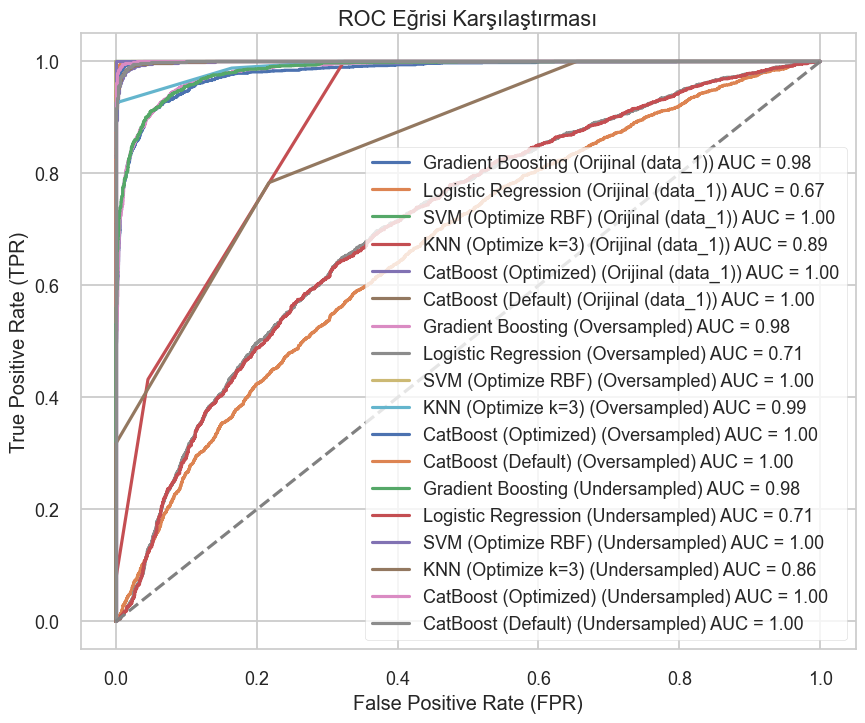

In [256]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- ROC Eğrisini Çizme ve AUC Hesaplama Fonksiyonu ---
def plot_roc_curve(models_to_evaluate, datasets):
    plt.figure(figsize=(10, 8))
    
    for dataset_name, (X_data, y_data) in datasets.items():
        for model_name, model_instance in models_to_evaluate.items():
            # Modeli eğit ve tahmin yap
            model_instance.fit(X_data, y_data)
            y_pred_proba = model_instance.predict_proba(X_data)[:, 1]
            
            # ROC eğrisini ve AUC'yu hesapla
            fpr, tpr, _ = roc_curve(y_data, y_pred_proba)
            auc_score = auc(fpr, tpr)
            
            # ROC eğrisini çiz
            plt.plot(fpr, tpr, label=f'{model_name} ({dataset_name}) AUC = {auc_score:.2f}')
    
    # Eğriyi çiz
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Random classifier için referans çizgisi
    plt.title('ROC Eğrisi Karşılaştırması')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend(loc='lower right')
    plt.show()

# --- ROC Eğrisini Çizme ve AUC Hesaplama ---
plot_roc_curve(models_to_evaluate, datasets)


# devamı

In [257]:
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)


# --- Değerlendirme Fonksiyonu ---
def evaluate_model(model, X, y, model_name, dataset_name, scale_data=True, random_state=42):
    """Bir modeli eğitir, değerlendirir ve sonuçları döndürür."""
    results = {
        'Model': model_name,
        'Dataset': dataset_name,
        'Test Accuracy': np.nan,
        'Test F1 Score (Exited=1)': np.nan,
        'Test AUC': np.nan
    }
    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y if dataset_name=='Orijinal (data_1)' else None) # Orijinalde stratify önemli olabilir

        if scale_data:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # Modeli eğit
        model.fit(X_train, y_train)

        # Tahmin yap
        y_pred = model.predict(X_test)

        # Metrikleri hesapla
        results['Test Accuracy'] = accuracy_score(y_test, y_pred)
        # Classification report'tan F1 skorunu al (label=1 için)
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        if '1' in report: # Eğer '1' sınıfı varsa (nadiren olmaz ama kontrol edelim)
             results['Test F1 Score (Exited=1)'] = report['1']['f1-score']
        else:
             results['Test F1 Score (Exited=1)'] = 0.0 # Veya np.nan

        # AUC hesapla (olasılık tahmini yapabiliyorsa)
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
            results['Test AUC'] = roc_auc_score(y_test, y_proba)
        else:
             # SVM'de probability=False ise predict_proba çalışmaz
             # Karar fonksiyonu varsa ona göre AUC hesaplanabilir ama şimdilik NaN bırakalım
             results['Test AUC'] = np.nan
             
    except Exception as e:
        print(f"Hata ({model_name}, {dataset_name}): {e}")
        # Hata durumunda bile sonuç sözlüğünü döndürelim ki eksik kalmasın
        
    return results


In [258]:
# --- Modelleri Tanımlama (Notebook'taki ayarlarla veya en iyi parametrelerle) ---
models_to_evaluate = {
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    # SVM için optimizasyon sonrası en iyi parametreleri kullanalım (AUC için probability=True ekleyelim)
    "SVM (Optimize RBF)": SVC(kernel='rbf', C=10, gamma=0.1, random_state=42, probability=True), 
    # KNN için optimizasyon sonrası en iyi k değerini kullanalım
    "KNN (Optimize k=3)": KNeighborsClassifier(n_neighbors=3) 
}

# --- Veri Setlerini ve İsimlerini Tanımlama ---
# Bu DataFrame'lerin notebook ortamında önceden oluşturulduğunu varsayıyoruz
datasets = {
    "Orijinal (data_1)": (data_1.drop("Exited", axis=1), data_1["Exited"]),
    "Oversampled": (balanced_data_real.drop("Exited", axis=1), balanced_data_real["Exited"]),
    "Undersampled": (data_balanced.drop("Exited", axis=1), data_balanced["Exited"])
}

# --- Değerlendirmeleri Çalıştırma ---
all_results = []

for dataset_name, (X_data, y_data) in datasets.items():
    print(f"\n{dataset_name} veri seti işleniyor...")
    for model_name, model_instance in models_to_evaluate.items():
        # SVM ve KNN genellikle orijinal veri seti üzerinde optimize edildi, 
        # diğerleri tüm setlerde denendi. Notebook'taki akışa göre ayarlayalım.
        if dataset_name == 'Orijinal (data_1)':
             # Orijinal sette tüm modelleri değerlendir (SVM ve KNN optimize edilmiş haliyle)
             # LogReg, SVM, KNN için ölçekleme gerekli
             scale = model_name in ["Logistic Regression", "SVM (Optimize RBF)", "KNN (Optimize k=3)"]
             result = evaluate_model(model_instance, X_data, y_data, model_name, dataset_name, scale_data=scale)
             all_results.append(result)
        elif model_name in ["Gradient Boosting", "Logistic Regression"]:
            # GBM ve LogReg diğer setlerde de denendi
            scale = model_name == "Logistic Regression" # GBM ağaç tabanlı, ölçekleme gerekmez
            result = evaluate_model(model_instance, X_data, y_data, model_name, dataset_name, scale_data=scale)
            all_results.append(result)
            


Orijinal (data_1) veri seti işleniyor...

Oversampled veri seti işleniyor...

Undersampled veri seti işleniyor...


In [259]:
# --- Sonuçları DataFrame'e Aktarma ve Gösterme ---
results_df_auto = pd.DataFrame(all_results)
results_df_auto = results_df_auto.sort_values(by=['Dataset', 'Test Accuracy'], ascending=[True, False]).reset_index(drop=True)

print("\n" + "="*50 + "\n")
print("Modellerin Otomatik Olarak Hesaplanmış Karşılaştırmalı Performans Özeti:")
print(results_df_auto)
print("\n" + "="*50 + "\n")



Modellerin Otomatik Olarak Hesaplanmış Karşılaştırmalı Performans Özeti:
                 Model            Dataset  Test Accuracy  \
0   SVM (Optimize RBF)  Orijinal (data_1)       0.954500   
1    Gradient Boosting  Orijinal (data_1)       0.941500   
2   KNN (Optimize k=3)  Orijinal (data_1)       0.928000   
3  Logistic Regression  Orijinal (data_1)       0.806500   
4    Gradient Boosting        Oversampled       0.933438   
5  Logistic Regression        Oversampled       0.703925   
6    Gradient Boosting       Undersampled       0.912990   
7  Logistic Regression       Undersampled       0.683824   

   Test F1 Score (Exited=1)  Test AUC  
0                  0.884664  0.975175  
1                  0.845033  0.982610  
2                  0.813472  0.927962  
3                  0.202062  0.768747  
4                  0.932570  0.985639  
5                  0.699203  0.775268  
6                  0.912454  0.973645  
7                  0.684597  0.751472  





--- Orijinal (data_1) Veri Seti Üzerindeki Karşılaştırma ---


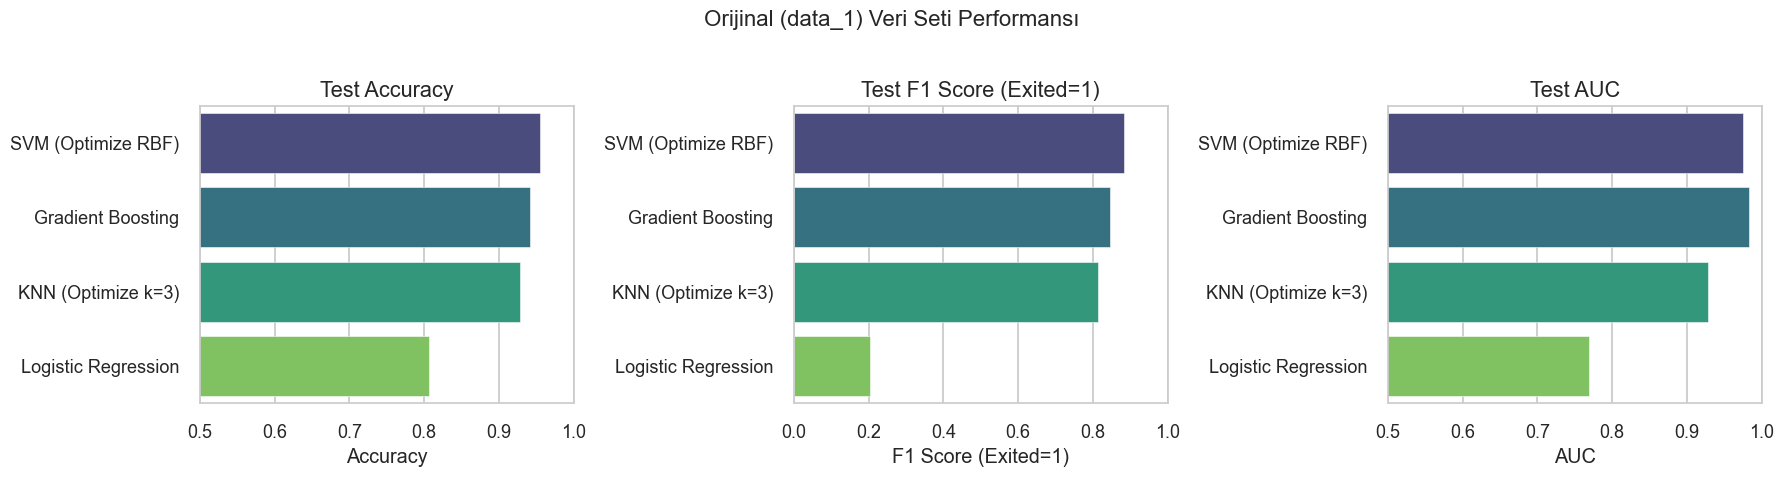




--- Oversampled Veri Seti Üzerindeki Karşılaştırma ---


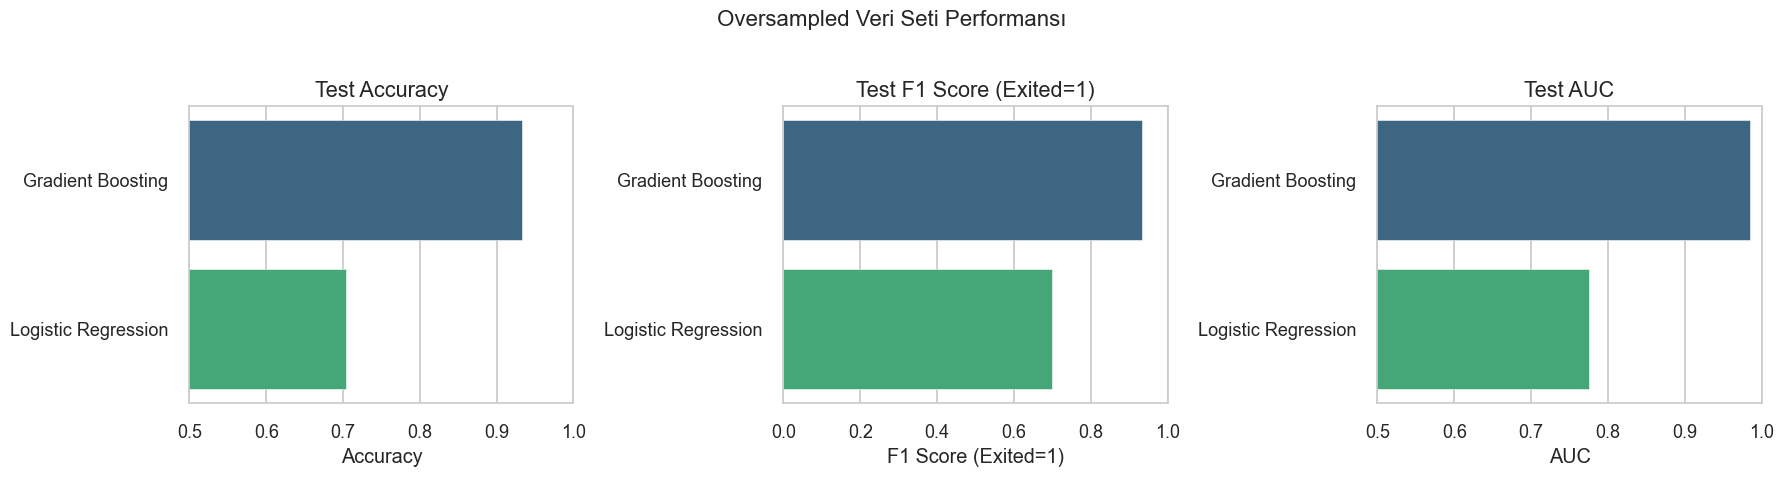




--- Undersampled Veri Seti Üzerindeki Karşılaştırma ---


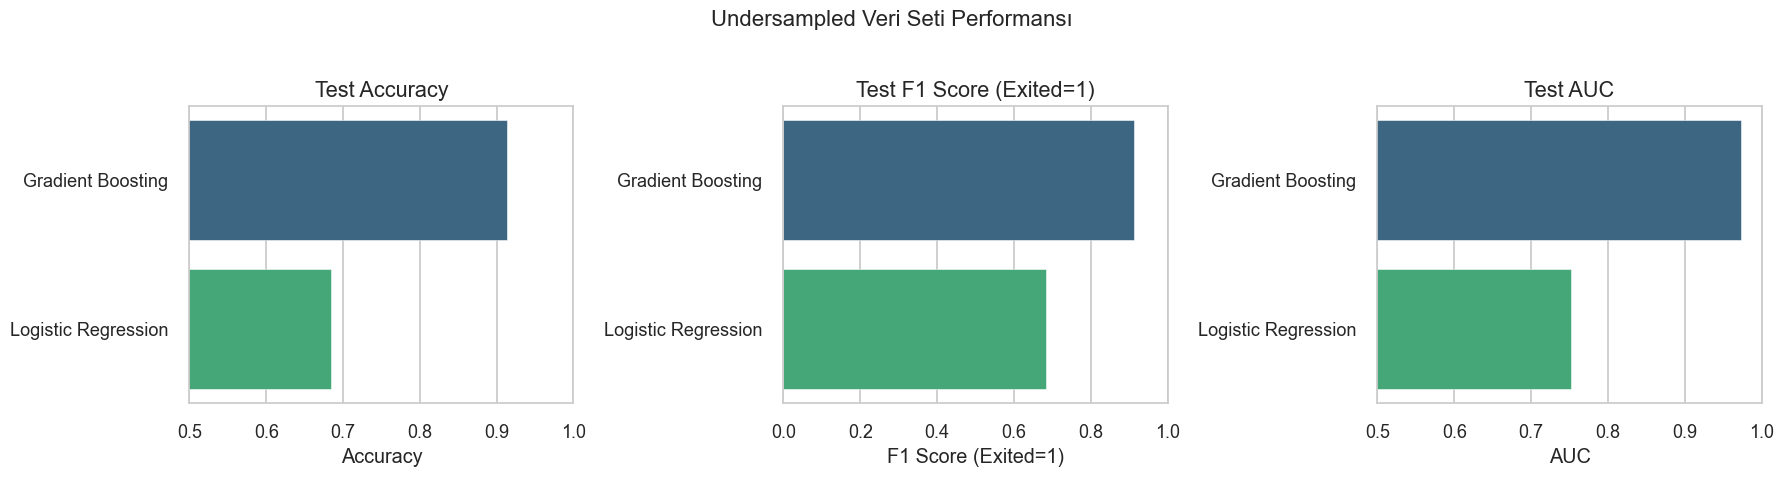

In [260]:
# --- Görselleştirme (Önceki kodla aynı, sadece df adı değişti) ---

datasets_unique = results_df_auto['Dataset'].unique()

for dataset_type in datasets_unique:
    print(f"\n--- {dataset_type} Veri Seti Üzerindeki Karşılaştırma ---")
    df_subset = results_df_auto[results_df_auto['Dataset'] == dataset_type].set_index('Model')
    
    # Sadece bu veri setinde çalışan modelleri al
    models_in_subset = df_subset.index
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
    fig.suptitle(f'{dataset_type} Veri Seti Performansı', fontsize=16)

    # Accuracy Plot
    if not df_subset['Test Accuracy'].isnull().all():
        sns.barplot(x=df_subset['Test Accuracy'], y=models_in_subset, ax=axes[0], palette='viridis', orient='h')
        axes[0].set_title('Test Accuracy')
        axes[0].set_xlim(0.5, 1.0)
        axes[0].set_xlabel('Accuracy')
        axes[0].set_ylabel('')
    else:
         axes[0].set_title('Test Accuracy (Veri Yok)')
         axes[0].text(0.5, 0.5, 'Veri Yok', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)

    # F1 Score Plot
    if not df_subset['Test F1 Score (Exited=1)'].isnull().all():
        sns.barplot(x=df_subset['Test F1 Score (Exited=1)'], y=models_in_subset, ax=axes[1], palette='viridis', orient='h')
        axes[1].set_title('Test F1 Score (Exited=1)')
        axes[1].set_xlim(0.0, 1.0)
        axes[1].set_xlabel('F1 Score (Exited=1)')
        axes[1].set_ylabel('')
    else:
         axes[1].set_title('Test F1 Score (Exited=1) (Veri Yok)')
         axes[1].text(0.5, 0.5, 'Veri Yok', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)

    # AUC Plot
    if not df_subset['Test AUC'].isnull().all():
        df_auc_subset = df_subset.dropna(subset=['Test AUC'])
        if not df_auc_subset.empty:
           sns.barplot(x=df_auc_subset['Test AUC'], y=df_auc_subset.index, ax=axes[2], palette='viridis', orient='h')
           axes[2].set_title('Test AUC')
           axes[2].set_xlim(0.5, 1.0)
           axes[2].set_xlabel('AUC')
           axes[2].set_ylabel('')
        else:
           axes[2].set_title('Test AUC (Veri Yok)')
           axes[2].text(0.5, 0.5, 'Veri Yok', horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)

    else:
         axes[2].set_title('Test AUC (Veri Yok)')
         axes[2].text(0.5, 0.5, 'Veri Yok', horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    print("\n" + "="*50 + "\n")

# For Stremalit Model

## Oversampled    CatBoost (Default)

In [261]:
df_cat_ = data1.copy()

In [262]:
from sklearn.utils import resample

# Azınlık ve çoğunluk sınıflarını ayıralım
minority_class_real_cat = df_cat_[df_cat['Exited'] == 1]
minority_class_real_cat = df_cat_[df_cat['Exited'] == 0]

# Azınlık sınıfını çoğaltma işlemi
minority_upsampled_real = resample(minority_class_real, 
                                   replace=True,     # Veriler tekrarlanabilir
                                   n_samples=7962,   # Eşit sayıya ulaşana kadar çoğalt
                                   random_state=42)

# Yeni dengeyi oluşturma
minority_class_real_cat = pd.concat([majority_class_real, minority_upsampled_real])

# Yeni sınıf dağılımı ve örnek verinin ilk birkaç satırı
minority_class_real_cat['Exited'].value_counts(), minority_class_real_cat.head()

(Exited
 0    7962
 1    7962
 Name: count, dtype: int64,
    CreditScore  Geography  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
 1          608          2   41       1   83807.86              1          0   
 3          699          0   39       1       0.00              2          0   
 4          850          2   43       2  125510.82              1          1   
 6          822          0   50       7       0.00              2          1   
 8          501          0   44       4  142051.07              2          0   
 
    IsActiveMember  Exited  Satisfaction_Score  LoyaltySegment  \
 1               1       0                   3               1   
 3               0       0                   5               2   
 4               1       0                   5               2   
 6               1       0                   2               0   
 8               1       0                   3               0   
 
    EngagementLevel  RiskSegment  
 1                2        

In [263]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# 1. Özellikler ve hedef değişken
X = minority_class_real_cat.drop("Exited", axis=1)
y = minority_class_real_cat["Exited"]

# 2. Eğitim ve test bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Kategorik sütun indekslerini al (CatBoost bunu ister)
cat_features = [i for i, col in enumerate(X.columns) if X[col].dtype == "object"]

# 4. Modeli tanımla ve eğit
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))

# 5. Tahmin ve değerlendirme
y_pred = cat_model.predict(X_test)
y_proba = cat_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9765


In [264]:
from sklearn.metrics import f1_score, accuracy_score

# Train verisinde tahmin yap
y_train_pred = cat_model.predict(X_train)

# Train ve Test için F1 skorlarını hesapla
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_pred)

# Train ve Test için doğruluk skorlarını da hesaplayalım (Accuracy zaten vardı ama derli toplu olsun)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Train F1 Score: {train_f1:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")


Train Accuracy: 0.9895
Test Accuracy: 0.9765
Train F1 Score: 0.9895
Test F1 Score: 0.9765


In [265]:
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.9798    0.9730    0.9764      1593
           1     0.9732    0.9799    0.9765      1592

    accuracy                         0.9765      3185
   macro avg     0.9765    0.9765    0.9765      3185
weighted avg     0.9765    0.9765    0.9765      3185



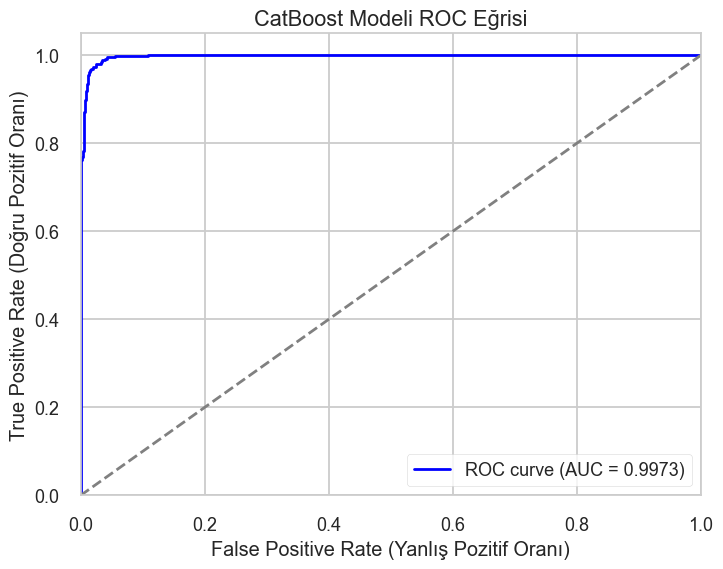

In [266]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Test seti üzerinde olasılık tahminleri al (pozitif sınıf için)
y_proba = cat_model.predict_proba(X_test)[:, 1]

# 2. ROC Curve için FPR ve TPR hesapla
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# 3. AUC hesapla
roc_auc = auc(fpr, tpr)

# 4. ROC grafiğini çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")  # Random model çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (Yanlış Pozitif Oranı)")
plt.ylabel("True Positive Rate (Doğru Pozitif Oranı)")
plt.title("CatBoost Modeli ROC Eğrisi")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
